# Predicción del Campo Eléctrico con 9 variables — horizonte de 1 minuto

Este cuaderno único integra preparación, modelado, evaluación e interpretabilidad. Utiliza solamente las nueve mediciones disponibles en el minuto actual; no crea rezagos ni ventanas móviles.

**Objetivo principal:** estimar $Valor\_CE_{t+1}$ con información conocida hasta el minuto $t$ y determinar cuánto rendimiento puede obtenerse sin mantener un historial de 61 minutos.


## Ruta explícita del experimento

1. Definir el objetivo y el alcance.
2. Configurar y cargar las fuentes cuando comienza la integración.
3. Limpiar los datos y configurar los horizontes cuando comienza la preparación.
4. Configurar el horizonte activo al comenzar el modelado.
5. Comparar modelos mediante validación temporal.
6. Congelar la selección antes de utilizar la prueba final.
7. Interpretar y exportar solamente el sistema ganador.

> La configuración está distribuida en la fase donde se utiliza. No existe un bloque global que adelante rutas de salida, modelos o parámetros de fases posteriores.


## 🎯 Fase 1 — Business Understanding

### 1. Objetivo y alcance

La columna predictora `Valor_CE` representa el último valor observado, $Valor\_CE_t$. La columna objetivo `Valor_CE_t+1` representa el minuto siguiente. Son mediciones de la misma magnitud física en instantes distintos.

$$\widehat{Valor\_CE}_{t+1}=f(Valor\_CE_t,Valor\_CM_t,TempOut_t,OutHum_t,WindSpeed_t,Bar_t,Rain_t,SolarRad_t,UVIndex_t)$$

Esta versión sirve como alternativa operacional simple y como referencia para evaluar si los modelos con memoria temporal justifican su complejidad adicional.


## 📥 Fase 2 — Data Understanding

### 2. ⚙️ Configuración reproducible de fuentes y variables actuales

Esta configuración aparece aquí porque se utiliza inmediatamente para cargar, integrar y auditar las fuentes. Todavía no se declaran horizontes de modelado, hiperparámetros ni rutas de resultados finales.


In [1]:
from pathlib import Path
import pandas as pd

RUTA_CAMPO_ELECTRICO = Path("Origen/ns/Campoelectrico.xlsx")
RUTA_CAMPO_MAGNETICO = Path("Origen/ns/Campomagmetico.xlsx")
RUTA_VARIABLES_AMBIENTALES = Path("Origen/ns/Varambiental.xlsx")

VARIABLES_9 = [
    "Valor_CE", "Valor_CM", "TempOut", "OutHum",
    "WindSpeed", "Bar", "Rain", "SolarRad.", "UVIndex",
]

for ruta in [RUTA_CAMPO_ELECTRICO, RUTA_CAMPO_MAGNETICO, RUTA_VARIABLES_AMBIENTALES]:
    if not ruta.is_file():
        raise FileNotFoundError(f"No se encontró la fuente: {ruta}")

print(f"Fuentes verificadas: 3 | Variables predictoras actuales: {len(VARIABLES_9)}")


Fuentes verificadas: 3 | Variables predictoras actuales: 9


### 3. Integración de las tres fuentes

`FechaHora` es la clave común. Antes del `merge`, las observaciones ambientales repetidas por minuto se ordenan por cantidad de nulos y se conserva la fila más completa. El campo eléctrico permanece como tabla principal.


#### 3.1 Lectura del campo eléctrico


In [2]:
# Campo eléctrico
df_ce = pd.read_excel(RUTA_CAMPO_ELECTRICO)
df_ce["FechaHora"] = pd.to_datetime(
    df_ce["Fecha"].astype(str) + " " + df_ce["Hora"].astype(str)
)
df_ce = df_ce[["FechaHora", "Valor_CE"]]

print(f"Campo eléctrico: {df_ce.shape[0]:,} registros × {df_ce.shape[1]} columnas")
display(df_ce.head())


Campo eléctrico: 186,664 registros × 2 columnas


,FechaHora,Valor_CE
0,2025-05-10 00:00:00,-0.28
1,2025-05-10 00:01:00,-0.34
2,2025-05-10 00:02:00,-0.39
3,2025-05-10 00:03:00,-0.43
4,2025-05-10 00:04:00,-0.38


#### 3.2 Lectura del campo magnético


In [3]:
# Campo magnético
df_cm = pd.read_excel(RUTA_CAMPO_MAGNETICO)
df_cm["FechaHora"] = pd.to_datetime(
    df_cm["DATE"].astype(str) + " " + df_cm["TIME"].astype(str)
)
df_cm.rename(columns={"HUAF": "Valor_CM"}, inplace=True)
df_cm = df_cm[["FechaHora", "Valor_CM"]]

print(f"Campo magnético: {df_cm.shape[0]:,} registros × {df_cm.shape[1]} columnas")
display(df_cm.head())


Campo magnético: 525,600 registros × 2 columnas


,FechaHora,Valor_CM
0,2025-01-01 00:00:00,24285.4
1,2025-01-01 00:01:00,24282.3
2,2025-01-01 00:02:00,24281.0
3,2025-01-01 00:03:00,24279.1
4,2025-01-01 00:04:00,24277.5


#### 3.3 Lectura de las variables ambientales


In [4]:
# Variables ambientales
df_va = pd.read_excel(RUTA_VARIABLES_AMBIENTALES)
df_va["FechaHora"] = pd.to_datetime(
    df_va["Date"].astype(str) + " " + df_va["Time"].astype(str)
)
df_va.drop(columns=["Date", "Time"], inplace=True)

print(f"Variables ambientales: {df_va.shape[0]:,} registros × {df_va.shape[1]} columnas")
display(df_va.head())


Variables ambientales: 708,958 registros × 9 columnas


,TempOut,OutHum,WindSpeed,WindDir,Bar,Rain,SolarRad.,UVIndex,FechaHora
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-01 00:00:00
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-01 00:01:00
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-01 00:02:00
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-01 00:03:00
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-01 00:04:00


#### 3.4 Resolución de duplicados ambientales

Cuando existe más de una fila para el mismo minuto, se conserva la que contiene menos valores nulos. Este paso se muestra separadamente para poder comparar la cantidad de registros antes y después.


In [5]:
columnas_validas_va = df_va.columns.difference(["FechaHora", "WindDir"])
df_va_preparado = df_va.copy()
df_va_preparado["CantidadNulos"] = (
    df_va_preparado[columnas_validas_va].isna().sum(axis=1)
)
df_va_unico = (
    df_va_preparado
    .sort_values(["FechaHora", "CantidadNulos"])
    .drop_duplicates(subset=["FechaHora"], keep="first")
    .drop(columns=["CantidadNulos"])
)

print(f"Ambientales antes de deduplicar: {df_va.shape[0]:,} registros × {df_va.shape[1]} columnas")
print(f"Ambientales después de deduplicar: {df_va_unico.shape[0]:,} registros × {df_va_unico.shape[1]} columnas")
display(df_va_unico.head())


Ambientales antes de deduplicar: 708,958 registros × 9 columnas
Ambientales después de deduplicar: 527,040 registros × 9 columnas


,TempOut,OutHum,WindSpeed,WindDir,Bar,Rain,SolarRad.,UVIndex,FechaHora
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-01 00:00:00
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-01 00:01:00
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-01 00:02:00
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-01 00:03:00
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-01 00:04:00


#### 3.5 Integración de las tres fuentes


In [6]:
df_integrado = (
    df_ce
    .merge(df_cm, on="FechaHora", how="left", validate="one_to_one")
    .merge(df_va_unico, on="FechaHora", how="left", validate="one_to_one")
)

print(f"Datos integrados: {df_integrado.shape[0]:,} registros × {df_integrado.shape[1]} columnas")
display(df_integrado.head())


Datos integrados: 186,664 registros × 11 columnas


,FechaHora,Valor_CE,Valor_CM,TempOut,OutHum,WindSpeed,WindDir,Bar,Rain,SolarRad.,UVIndex
0,2025-05-10 00:00:00,-0.28,24194.3,16.7,86.0,0.0,NaN,947.3,0.0,0.0,0.0
1,2025-05-10 00:01:00,-0.34,24193.8,16.7,86.0,0.0,NaN,947.3,0.0,0.0,0.0
2,2025-05-10 00:02:00,-0.39,24193.6,16.7,86.0,0.0,NaN,947.3,0.0,0.0,0.0
3,2025-05-10 00:03:00,-0.43,24194.4,16.7,86.0,0.0,NaN,947.3,0.0,0.0,0.0
4,2025-05-10 00:04:00,-0.38,24195.2,16.7,86.0,0.0,NaN,947.3,0.0,0.0,0.0


### 3.1 Auditoría básica antes de la limpieza

Se revisan tipos, fechas, duplicados, nulos y estadísticos descriptivos antes de aplicar reglas de limpieza. Esta auditoría permite distinguir problemas de calidad de valores físicamente extremos.


In [7]:
auditoria_fuentes = pd.DataFrame({
    "Columna": df_integrado.columns,
    "Tipo": [str(df_integrado[c].dtype) for c in df_integrado.columns],
    "Nulos": [int(df_integrado[c].isna().sum()) for c in df_integrado.columns],
    "Valores_unicos": [int(df_integrado[c].nunique(dropna=True)) for c in df_integrado.columns],
})
display(auditoria_fuentes)
display(df_integrado[VARIABLES_9].describe().T)
print(f"Fechas duplicadas: {df_integrado['FechaHora'].duplicated().sum():,}")
print(f"Periodo integrado: {df_integrado['FechaHora'].min()} → {df_integrado['FechaHora'].max()}")


,Columna,Tipo,Nulos,Valores_unicos
0,FechaHora,datetime64[ns],0,186664
1,Valor_CE,float64,0,760
2,Valor_CM,float64,0,4530
3,TempOut,float64,0,154
4,OutHum,float64,0,42
5,WindSpeed,float64,0,13
6,WindDir,float64,186664,0
7,Bar,float64,0,103
8,Rain,float64,0,2
9,SolarRad.,float64,0,847


,count,mean,std,min,25%,50%,75%,max
Valor_CE,186664.0,-0.951169,0.891354,-7.65,-1.56,-0.79,-0.24,2.85
Valor_CM,186664.0,25140.696868,8035.111596,23815.80,24244.60,24268.20,24307.20,99999.00
TempOut,186664.0,17.560050,3.006653,11.80,15.30,16.90,19.50,27.30
OutHum,186664.0,82.292054,7.339986,51.00,78.00,84.00,87.00,92.00
WindSpeed,186664.0,3.920614,4.881584,0.00,0.00,1.60,8.00,19.30
Bar,186664.0,949.189361,1.523207,943.50,948.20,949.20,950.20,953.70
Rain,186664.0,0.000021,0.002070,0.00,0.00,0.00,0.00,0.20
SolarRad.,186664.0,174.592160,248.081662,0.00,0.00,0.00,337.00,986.00
UVIndex,186664.0,1.226116,2.002506,0.00,0.00,0.00,1.90,8.90


Fechas duplicadas: 0
Periodo integrado: 2025-05-10 00:00:00 → 2025-12-01 17:06:00


## 🧹 Fase 3 — Data Preparation

### 4. ⚙️ Configuración reproducible de limpieza, horizontes y conjuntos preparados

Los horizontes y las rutas de los CSV se declaran recién al comenzar la transformación y exportación de datos. Los parámetros de los modelos todavía no son necesarios.


In [8]:
HORIZONTES = [1, 5, 15, 30, 60]
DIRECTORIO_DATOS_MODELO = Path("Datos_modelamiento_9_variables")
DIRECTORIO_REFERENCIA_96 = Path("Datos_modelamiento_96_variables")

print("Horizontes que se prepararán:", HORIZONTES)
print("Directorio de conjuntos:", DIRECTORIO_DATOS_MODELO)


Horizontes que se prepararán: [1, 5, 15, 30, 60]
Directorio de conjuntos: Datos_modelamiento_9_variables


### 4.1 Limpieza reproducible

Se aplican las reglas confirmadas: excluir `WindDir`, eliminar las filas con el código magnético `99999`, conservar `Rain = 0.20`, resolver posibles fechas duplicadas, ordenar y verificar las nueve entradas.


In [9]:
df_limpio = df_integrado.copy()
registros_iniciales = len(df_limpio)

nulos_winddir = int(df_limpio["WindDir"].isna().sum())
df_limpio.drop(columns=["WindDir"], inplace=True)

mascara_cm_error = df_limpio["Valor_CM"].eq(99999)
errores_cm = int(mascara_cm_error.sum())
df_limpio = df_limpio.loc[~mascara_cm_error].copy()

antes_duplicados = len(df_limpio)
df_limpio.drop_duplicates(subset=["FechaHora"], keep="first", inplace=True)
duplicados_eliminados = antes_duplicados - len(df_limpio)
df_limpio.sort_values("FechaHora", inplace=True)
df_limpio.reset_index(drop=True, inplace=True)

print(f"Registros iniciales: {registros_iniciales:,}")
print(f"Nulos de WindDir excluidos con la columna: {nulos_winddir:,}")
print(f"Filas Valor_CM = 99999 eliminadas: {errores_cm:,}")
print(f"Duplicados por FechaHora eliminados: {duplicados_eliminados:,}")
print(f"Registros resultantes: {len(df_limpio):,}")
print(f"Nulos en las 9 variables: {df_limpio[VARIABLES_9].isna().sum().sum():,}")
print(f"Eventos Rain = 0.20 conservados: {df_limpio['Rain'].eq(0.20).sum():,}")

Registros iniciales: 186,664
Nulos de WindDir excluidos con la columna: 186,664
Filas Valor_CM = 99999 eliminadas: 2,126
Duplicados por FechaHora eliminados: 0
Registros resultantes: 184,538
Nulos en las 9 variables: 0
Eventos Rain = 0.20 conservados: 20


### 5. Bloques continuos y objetivos futuros

Esta versión no genera rezagos ni ventanas. Los bloques impiden que un objetivo futuro atraviese intervalos sin medición. Para conservar una comparación justa con los experimentos de 35 y 96 variables se excluyen los primeros 60 registros de cada bloque; esta restricción pertenece al experimento comparativo, no es una necesidad operacional del modelo de 9 variables.

`shift(-h)` coloca en la fila del minuto $t$ el `Valor_CE` observado en $t+h`. Se usa exclusivamente para construir la variable dependiente y nunca se incluye entre los predictores.


In [10]:
df_modelo_9 = df_limpio.copy()
df_modelo_9["Intervalo"] = df_modelo_9["FechaHora"].diff()
df_modelo_9["NuevoBloque"] = (
    df_modelo_9["Intervalo"].ne(pd.Timedelta(minutes=1))
)
df_modelo_9["Bloque"] = df_modelo_9["NuevoBloque"].cumsum()
df_modelo_9["PosicionBloque"] = df_modelo_9.groupby("Bloque").cumcount()
df_modelo_9["TamanoBloque"] = (
    df_modelo_9.groupby("Bloque")["FechaHora"].transform("size")
)

grupo_ce = df_modelo_9.groupby("Bloque")["Valor_CE"]
grupo_fecha = df_modelo_9.groupby("Bloque")["FechaHora"]

for horizonte in HORIZONTES:
    df_modelo_9[f"Valor_CE_t+{horizonte}"] = grupo_ce.shift(-horizonte)

print(f"Bloques continuos detectados: {df_modelo_9['Bloque'].nunique():,}")
print("Objetivos creados:", [f"Valor_CE_t+{h}" for h in HORIZONTES])

Bloques continuos detectados: 26
Objetivos creados: ['Valor_CE_t+1', 'Valor_CE_t+5', 'Valor_CE_t+15', 'Valor_CE_t+30', 'Valor_CE_t+60']


### 6. Validación y exportación de las entradas al modelado

Cada CSV contiene `FechaHora`, `Bloque`, nueve predictores actuales y un objetivo. Se verifican alineación temporal, nulos, duplicados y, si existe la referencia de 96 variables, coincidencia de fechas.


In [11]:
DIRECTORIO_DATOS_MODELO.mkdir(parents=True, exist_ok=True)
resumen_exportacion_9 = []

for horizonte in HORIZONTES:
    objetivo = f"Valor_CE_t+{horizonte}"
    mascara = (
        df_modelo_9[VARIABLES_9].notna().all(axis=1)
        & df_modelo_9[objetivo].notna()
        & df_modelo_9["PosicionBloque"].ge(60)
        & (df_modelo_9["PosicionBloque"] + horizonte).lt(
            df_modelo_9["TamanoBloque"]
        )
    )

    columnas = ["FechaHora", "Bloque"] + VARIABLES_9 + [objetivo]
    df_exportar = df_modelo_9.loc[mascara, columnas].copy()
    fecha_objetivo = grupo_fecha.shift(-horizonte)
    alineacion = (
        fecha_objetivo[mascara]
        == df_modelo_9.loc[mascara, "FechaHora"]
        + pd.Timedelta(minutes=horizonte)
    ).all()

    ruta_salida = DIRECTORIO_DATOS_MODELO / f"modelo_horizonte_{horizonte}min.csv"
    df_exportar.to_csv(ruta_salida, index=False)

    ruta_96 = DIRECTORIO_REFERENCIA_96 / f"modelo_horizonte_{horizonte}min.csv"
    mismas_fechas_96 = None
    if ruta_96.exists():
        fechas_96 = pd.read_csv(
            ruta_96, usecols=["FechaHora"], parse_dates=["FechaHora"]
        )["FechaHora"]
        mismas_fechas_96 = (
            len(fechas_96) == len(df_exportar)
            and fechas_96.reset_index(drop=True).equals(
                df_exportar["FechaHora"].reset_index(drop=True)
            )
        )

    resumen_exportacion_9.append({
        "HorizonteMin": horizonte,
        "Registros": len(df_exportar),
        "Columnas": df_exportar.shape[1],
        "Predictores": len(VARIABLES_9),
        "Nulos": int(df_exportar.isna().sum().sum()),
        "DuplicadosFechaHora": int(df_exportar["FechaHora"].duplicated().sum()),
        "AlineacionTemporal": bool(alineacion),
        "MismasFechas96": mismas_fechas_96,
        "Archivo": str(ruta_salida),
    })

    print(
        f"t+{horizonte:>2} min | Registros: {len(df_exportar):,} | "
        f"Columnas: {df_exportar.shape[1]} | Mismas fechas 96: {mismas_fechas_96}"
    )

resumen_exportacion_9 = pd.DataFrame(resumen_exportacion_9)
display(resumen_exportacion_9)

if not resumen_exportacion_9["AlineacionTemporal"].all():
    raise ValueError("Existe un horizonte con objetivo temporal mal alineado.")
if resumen_exportacion_9["Nulos"].sum() != 0:
    raise ValueError("Los archivos de 9 variables contienen nulos.")
if resumen_exportacion_9["DuplicadosFechaHora"].sum() != 0:
    raise ValueError("Los archivos de 9 variables contienen fechas duplicadas.")
if resumen_exportacion_9["MismasFechas96"].notna().all():
    if not resumen_exportacion_9["MismasFechas96"].all():
        raise ValueError("Las fechas no coinciden con el enfoque de 96 variables.")

t+ 1 min | Registros: 183,054 | Columnas: 12 | Mismas fechas 96: None
t+ 5 min | Registros: 182,962 | Columnas: 12 | Mismas fechas 96: None
t+15 min | Registros: 182,732 | Columnas: 12 | Mismas fechas 96: None
t+30 min | Registros: 182,387 | Columnas: 12 | Mismas fechas 96: None
t+60 min | Registros: 181,697 | Columnas: 12 | Mismas fechas 96: None


,HorizonteMin,Registros,Columnas,Predictores,Nulos,DuplicadosFechaHora,AlineacionTemporal,MismasFechas96,Archivo
0,1,183054,12,9,0,0,True,None,Datos_modelamiento_9_variables/modelo_horizont...
1,5,182962,12,9,0,0,True,None,Datos_modelamiento_9_variables/modelo_horizont...
2,15,182732,12,9,0,0,True,None,Datos_modelamiento_9_variables/modelo_horizont...
3,30,182387,12,9,0,0,True,None,Datos_modelamiento_9_variables/modelo_horizont...
4,60,181697,12,9,0,0,True,None,Datos_modelamiento_9_variables/modelo_horizont...


## 🤖 Fase 4 — Modeling

### 7.1 Definición del problema y ruta de modelado

Se estima `Valor_CE_t+1` usando exclusivamente las nueve mediciones actuales. Primero se comparan los modelos dentro del 80 % de entrenamiento mediante validación temporal; el 20 % final permanece reservado hasta congelar la selección.

Ruta: cargar el horizonte → dividir cronológicamente → calcular persistencia → entrenar modelos base → optimizar → construir stacking → congelar la selección.


### 7.2 ⚙️ Configuración reproducible del modelado

Esta configuración aparece al comenzar el modelado porque recién aquí se necesitan NumPy, el directorio de conjuntos, las columnas de metadatos y el horizonte activo. Cambiar `HORIZONTE` define un experimento independiente.


In [12]:
import numpy as np

DIRECTORIO_DATOS = DIRECTORIO_DATOS_MODELO
COLUMNAS_METADATOS = ["FechaHora", "Bloque"]
HORIZONTE = 1

if HORIZONTE not in HORIZONTES:
    raise ValueError(f"Horizonte inválido: {HORIZONTE}")
print(f"Horizonte activo: {HORIZONTE} minuto(s)")


Horizonte activo: 1 minuto(s)


In [13]:
# ============================
# Carga y validación de un horizonte
# ============================
def cargar_horizonte(horizonte):
    if horizonte not in HORIZONTES:
        raise ValueError(f"Horizonte no válido. Use uno de: {HORIZONTES}")

    ruta = DIRECTORIO_DATOS / f"modelo_horizonte_{horizonte}min.csv"
    if not ruta.exists():
        raise FileNotFoundError(
            f"No existe {ruta}. Ejecute primero las celdas de la Fase 3 de este cuaderno."
        )

    df = pd.read_csv(ruta, parse_dates=["FechaHora"])
    objetivo = f"Valor_CE_t+{horizonte}"

    if objetivo not in df.columns:
        raise ValueError(f"Falta la columna objetivo: {objetivo}")
    if df.isna().any().any():
        raise ValueError(f"El archivo t+{horizonte} contiene valores nulos.")
    if df["FechaHora"].duplicated().any():
        raise ValueError(f"El archivo t+{horizonte} contiene fechas duplicadas.")
    if not df["FechaHora"].is_monotonic_increasing:
        raise ValueError(f"El archivo t+{horizonte} no está ordenado cronológicamente.")

    return df

In [14]:
# ============================
# Verificar los cinco archivos sin conservarlos en memoria
# ============================
resumen_archivos = []

for horizonte in HORIZONTES:
    df_revision = cargar_horizonte(horizonte)
    objetivo = f"Valor_CE_t+{horizonte}"
    predictores = [
        columna for columna in df_revision.columns
        if columna not in COLUMNAS_METADATOS + [objetivo]
    ]

    resumen_archivos.append({
        "HorizonteMin": horizonte,
        "Registros": len(df_revision),
        "Columnas": df_revision.shape[1],
        "Predictores": len(predictores),
        "FechaInicial": df_revision["FechaHora"].min(),
        "FechaFinal": df_revision["FechaHora"].max(),
        "Nulos": int(df_revision.isna().sum().sum()),
        "Duplicados": int(df_revision["FechaHora"].duplicated().sum())
    })

    del df_revision

resumen_archivos = pd.DataFrame(resumen_archivos)
display(resumen_archivos)

,HorizonteMin,Registros,Columnas,Predictores,FechaInicial,FechaFinal,Nulos,Duplicados
0,1,183054,12,9,2025-05-10 01:00:00,2025-11-30 12:52:00,0,0
1,5,182962,12,9,2025-05-10 01:00:00,2025-11-30 12:48:00,0,0
2,15,182732,12,9,2025-05-10 01:00:00,2025-11-30 12:38:00,0,0
3,30,182387,12,9,2025-05-10 01:00:00,2025-11-30 12:23:00,0,0
4,60,181697,12,9,2025-05-10 01:00:00,2025-11-30 11:53:00,0,0


### 7.3 Selección del horizonte — trabajo secuencial

> **Horizonte activo: 1 minuto.** Primero se completará todo el entrenamiento, validación y evaluación para predecir `Valor_CE_t+1`.

Los horizontes son cinco problemas de predicción **independientes**; no se encadenan entre sí. Una vez cerrado el horizonte de 1 minuto, se repetirá el mismo flujo cambiando únicamente `HORIZONTE`, en este orden:

1. **1 minuto — en desarrollo**
2. 5 minutos — pendiente
3. 15 minutos — pendiente
4. 30 minutos — pendiente
5. 60 minutos — pendiente

Trabajar uno por uno facilita revisar errores, métricas y consumo de memoria. Al final se consolidarán los resultados de los cinco horizontes en una tabla comparativa.

In [15]:
# Cargar el horizonte activo configurado en la sección 7.2
df_modelamiento = cargar_horizonte(HORIZONTE)
columna_objetivo = f"Valor_CE_t+{HORIZONTE}"
columnas_predictoras_modelo = [
    columna for columna in df_modelamiento.columns
    if columna not in COLUMNAS_METADATOS + [columna_objetivo]
]

X = df_modelamiento[columnas_predictoras_modelo].copy()
y = df_modelamiento[columna_objetivo].copy()
fechas = df_modelamiento["FechaHora"].copy()
bloques = df_modelamiento["Bloque"].copy()

print(f"Horizonte seleccionado: {HORIZONTE} minuto(s)")
print(f"Registros: {len(df_modelamiento):,}")
print(f"Predictores: {X.shape[1]}")
print(f"Objetivo: {columna_objetivo}")
display(df_modelamiento.head())

Horizonte seleccionado: 1 minuto(s)
Registros: 183,054
Predictores: 9
Objetivo: Valor_CE_t+1


,FechaHora,Bloque,Valor_CE,Valor_CM,TempOut,OutHum,WindSpeed,Bar,Rain,SolarRad.,UVIndex,Valor_CE_t+1
0,2025-05-10 01:00:00,1,-0.08,24226.7,16.1,86.0,0.0,947.1,0.0,0.0,0.0,-0.12
1,2025-05-10 01:01:00,1,-0.12,24225.5,16.1,86.0,0.0,947.1,0.0,0.0,0.0,-0.14
2,2025-05-10 01:02:00,1,-0.14,24224.5,16.1,86.0,0.0,947.1,0.0,0.0,0.0,-0.09
3,2025-05-10 01:03:00,1,-0.09,24223.6,16.1,86.0,0.0,947.1,0.0,0.0,0.0,-0.02
4,2025-05-10 01:04:00,1,-0.02,24223.0,16.1,86.0,0.0,947.1,0.0,0.0,0.0,0.02


In [16]:
# ============================
# División cronológica 80/20
# ============================
indice_corte = int(len(df_modelamiento) * 0.80)

X_train = X.iloc[:indice_corte].copy()
X_test = X.iloc[indice_corte:].copy()
y_train = y.iloc[:indice_corte].copy()
y_test = y.iloc[indice_corte:].copy()
fechas_train = fechas.iloc[:indice_corte].copy()
fechas_test = fechas.iloc[indice_corte:].copy()
bloques_train = bloques.iloc[:indice_corte].copy()
bloques_test = bloques.iloc[indice_corte:].copy()

if fechas_train.max() >= fechas_test.min():
    raise ValueError("La división temporal no respeta el orden cronológico.")

print(f"Entrenamiento: {len(X_train):,} registros ({len(X_train) / len(X):.1%})")
print(f"Prueba: {len(X_test):,} registros ({len(X_test) / len(X):.1%})")
print(f"Entrenamiento: {fechas_train.min()} → {fechas_train.max()}")
print(f"Prueba: {fechas_test.min()} → {fechas_test.max()}")

Entrenamiento: 146,443 registros (80.0%)
Prueba: 36,611 registros (20.0%)
Entrenamiento: 2025-05-10 01:00:00 → 2025-10-29 00:54:00
Prueba: 2025-10-29 00:55:00 → 2025-11-30 12:52:00


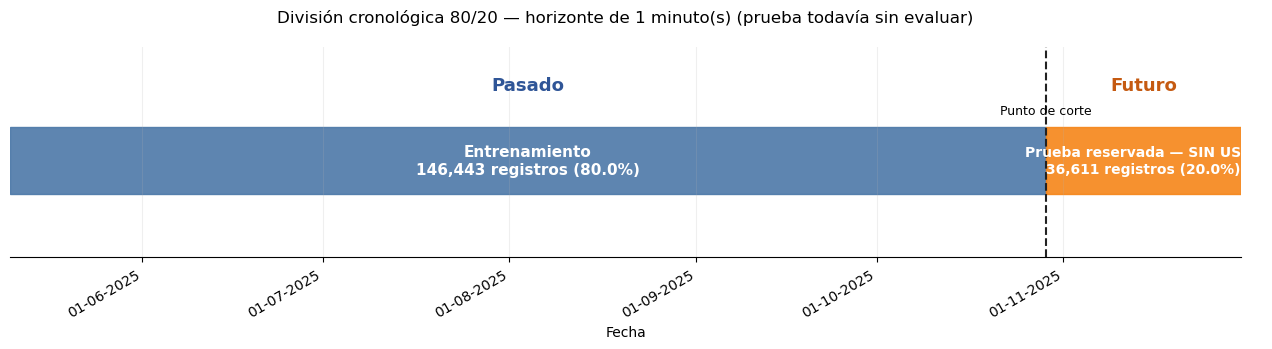

In [17]:
# ============================
# Gráfica de la división temporal
# ============================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fecha_inicio = fechas_train.min()
fecha_corte = fechas_test.min()
fecha_fin = fechas_test.max()
centro_train = fecha_inicio + (fecha_corte - fecha_inicio) / 2
centro_test = fecha_corte + (fecha_fin - fecha_corte) / 2

fig, ax = plt.subplots(figsize=(13, 3.6))

# Franja cronológica: primero se aprende del pasado y después se evalúa el futuro.
ax.axvspan(fecha_inicio, fecha_corte, ymin=0.30, ymax=0.62,
           color="#4C78A8", alpha=0.90, label="Entrenamiento")
ax.axvspan(fecha_corte, fecha_fin, ymin=0.30, ymax=0.62,
           color="#F58518", alpha=0.90, label="Prueba reservada")
ax.axvline(fecha_corte, color="#222222", linestyle="--", linewidth=1.5)

ax.text(centro_train, 0.82, "Pasado", ha="center", va="center",
        fontsize=13, fontweight="bold", color="#2F5597")
ax.text(centro_test, 0.82, "Futuro", ha="center", va="center",
        fontsize=13, fontweight="bold", color="#C55A11")
ax.text(centro_train, 0.46,
        f"Entrenamiento\n{len(X_train):,} registros ({len(X_train)/len(X):.1%})",
        ha="center", va="center", color="white", fontsize=11, fontweight="bold")
ax.text(centro_test, 0.46,
        f"Prueba reservada — SIN USAR\n{len(X_test):,} registros ({len(X_test)/len(X):.1%})",
        ha="center", va="center", color="white", fontsize=10, fontweight="bold")
ax.annotate("Punto de corte", xy=(fecha_corte, 0.63), xytext=(0, 8),
            textcoords="offset points", ha="center", fontsize=9)

ax.set_title(
    f"División cronológica 80/20 — horizonte de {HORIZONTE} minuto(s) "
    "(prueba todavía sin evaluar)", pad=18
)
ax.set_xlim(fecha_inicio, fecha_fin)
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_xlabel("Fecha")
ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=5, maxticks=9))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%m-%Y"))
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
ax.spines[["left", "right", "top"]].set_visible(False)
ax.grid(axis="x", alpha=0.20)
plt.tight_layout()
plt.show()

> **Importante — esta gráfica no muestra resultados de prueba.** La franja naranja únicamente identifica qué 20 % de los registros fue separado y reservado. Hasta este punto no existen predicciones de un modelo entrenado sobre esos 36,611 registros ni métricas finales calculadas con ellos.

Durante la Fase 4, los modelos y sus hiperparámetros se comparan exclusivamente mediante las cinco validaciones temporales construidas dentro de la franja azul. La franja naranja se utilizará en la **Fase 5 — Paso 8**, después de seleccionar y congelar el modelo final. En ese momento se entrenará con todo el 80 %, se predecirá una sola vez el 20 % reservado y se generará la gráfica definitiva `valor real de prueba vs. predicción final`.

In [18]:
# ============================
# Línea base de persistencia — horizonte activo
# ============================
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluar_predicciones(y_real, y_predicha):
    y_real = np.asarray(y_real)
    y_predicha = np.asarray(y_predicha)

    if len(y_real) != len(y_predicha):
        raise ValueError("La cantidad de valores reales y predichos no coincide.")
    if np.isnan(y_real).any() or np.isnan(y_predicha).any():
        raise ValueError("Hay valores nulos en la evaluación.")

    return {
        "MAE": mean_absolute_error(y_real, y_predicha),
        "RMSE": np.sqrt(mean_squared_error(y_real, y_predicha)),
        "R2": r2_score(y_real, y_predicha),
    }

if HORIZONTE != 1:
    raise ValueError("Esta sección debe ejecutarse primero con HORIZONTE = 1.")
if "Valor_CE" not in X_test.columns:
    raise ValueError("Valor_CE debe estar disponible como último valor conocido en t.")
if fechas_train.max() >= fechas_test.min():
    raise ValueError("Se detectó fuga temporal entre entrenamiento y prueba.")

pred_persistencia = X_test["Valor_CE"].to_numpy()
metricas_persistencia = evaluar_predicciones(y_test, pred_persistencia)

resultados_modelos = pd.DataFrame([{
    "Tipo": "Línea base",
    "Modelo": "Persistencia",
    "Horizonte_min": HORIZONTE,
    **metricas_persistencia,
    "Registros_prueba": len(y_test),
}])

print(f"Línea base calculada para el horizonte de {HORIZONTE} minuto(s)")
print(f"Periodo evaluado: {fechas_test.min()} → {fechas_test.max()}")
display(resultados_modelos.round({"MAE": 5, "RMSE": 5, "R2": 5}))

Línea base calculada para el horizonte de 1 minuto(s)
Periodo evaluado: 2025-10-29 00:55:00 → 2025-11-30 12:52:00


,Tipo,Modelo,Horizonte_min,MAE,RMSE,R2,Registros_prueba
0,Línea base,Persistencia,1,0.06892,0.11282,0.96637,36611


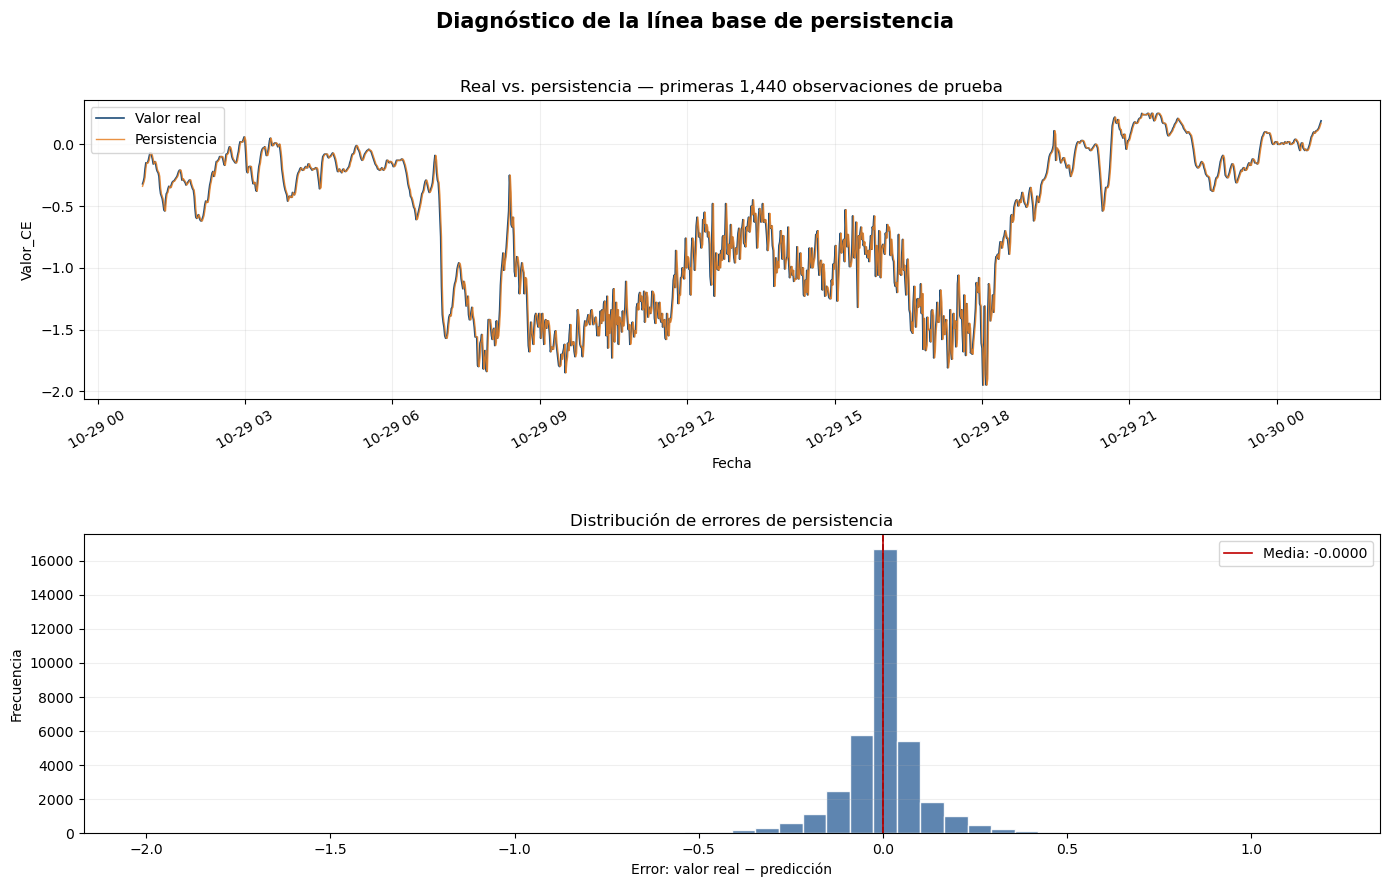

Error medio: -0.00004
Desviación estándar del error: 0.11282
Percentil 95 del error absoluto: 0.25000


In [19]:
# ============================
# Diagnóstico gráfico de la línea base
# ============================
residuos_persistencia = np.asarray(y_test) - pred_persistencia
cantidad_visual = min(1440, len(y_test))  # primeras 24 horas disponibles

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle("Diagnóstico de la línea base de persistencia",
             fontsize=15, fontweight="bold")

axes[0].plot(fechas_test.iloc[:cantidad_visual], np.asarray(y_test)[:cantidad_visual],
             label="Valor real", color="#1F4E79", linewidth=1.2)
axes[0].plot(fechas_test.iloc[:cantidad_visual], pred_persistencia[:cantidad_visual],
             label="Persistencia", color="#E67E22", linewidth=1.0, alpha=0.85)
axes[0].set_title(f"Real vs. persistencia — primeras {cantidad_visual:,} observaciones de prueba")
axes[0].set_xlabel("Fecha")
axes[0].set_ylabel("Valor_CE")
axes[0].legend()
axes[0].grid(alpha=0.20)
axes[0].tick_params(axis="x", rotation=30)

axes[1].hist(residuos_persistencia, bins=50, color="#4C78A8",
             edgecolor="white", alpha=0.90)
axes[1].axvline(0, color="#222222", linestyle="--", linewidth=1.2)
axes[1].axvline(residuos_persistencia.mean(), color="#C00000",
                linestyle="-", linewidth=1.2, label=f"Media: {residuos_persistencia.mean():.4f}")
axes[1].set_title("Distribución de errores de persistencia")
axes[1].set_xlabel("Error: valor real − predicción")
axes[1].set_ylabel("Frecuencia")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.20)

plt.tight_layout(rect=[0, 0, 1, 0.96], h_pad=3.0)
plt.show()

print(f"Error medio: {residuos_persistencia.mean():.5f}")
print(f"Desviación estándar del error: {residuos_persistencia.std():.5f}")
print(f"Percentil 95 del error absoluto: {np.percentile(np.abs(residuos_persistencia), 95):.5f}")

### 7.4 Validación temporal interna del entrenamiento

La optimización y comparación preliminar de modelos se realizará **solo dentro del 80 % de entrenamiento**. El 20 % de prueba no participa en la selección de hiperparámetros y se reserva para la evaluación final de la Fase 5.

Se utilizarán cinco particiones temporales expansivas (*TimeSeriesSplit*): en cada iteración el modelo aprende de un periodo pasado cada vez mayor y se valida en el periodo inmediatamente posterior. No se mezclan ni se barajan las observaciones.

Entre entrenamiento y validación se deja una separación de `HORIZONTE` observaciones para reducir el riesgo de solapamiento entre el objetivo futuro del último registro de entrenamiento y el comienzo de la validación. Para el horizonte actual, la separación es de un registro.

Horizonte activo: 1 minuto(s)
Particiones temporales internas: 5
Separación entre entrenamiento y validación: 1 registro(s)
Conjunto de prueba reservado y sin usar: 36,611 registros


,Partición,Registros_entrenamiento,Inicio_entrenamiento,Fin_entrenamiento,Registros_validación,Inicio_validación,Fin_validación,Separación_registros
0,1,24407,2025-05-10 01:00:00,2025-05-29 18:38:00,24407,2025-05-29 18:40:00,2025-06-16 22:45:00,1
1,2,48814,2025-05-10 01:00:00,2025-06-16 22:44:00,24407,2025-06-16 22:46:00,2025-08-19 17:03:00,1
2,3,73221,2025-05-10 01:00:00,2025-08-19 17:02:00,24407,2025-08-19 17:04:00,2025-09-13 23:37:00,1
3,4,97628,2025-05-10 01:00:00,2025-09-13 23:36:00,24407,2025-09-13 23:38:00,2025-10-05 06:17:00,1
4,5,122035,2025-05-10 01:00:00,2025-10-05 06:16:00,24407,2025-10-05 06:18:00,2025-10-29 00:54:00,1


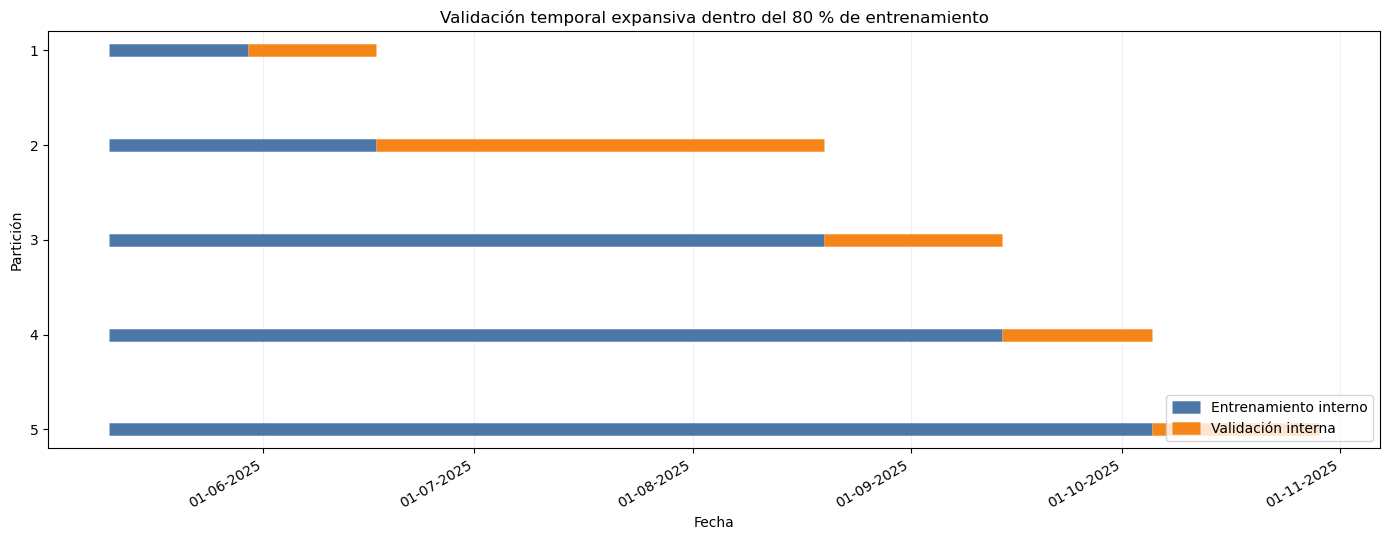

In [20]:
# ============================
# Validación temporal interna — solo conjunto de entrenamiento
# ============================
from sklearn.model_selection import TimeSeriesSplit

NUMERO_PARTICIONES = 5
SEPARACION_TEMPORAL = HORIZONTE

validacion_temporal = TimeSeriesSplit(
    n_splits=NUMERO_PARTICIONES,
    gap=SEPARACION_TEMPORAL,
)

resumen_particiones = []
indices_particiones = []

for particion, (idx_entrenamiento, idx_validacion) in enumerate(
    validacion_temporal.split(X_train), start=1
):
    fecha_fin_entrenamiento = fechas_train.iloc[idx_entrenamiento].max()
    fecha_inicio_validacion = fechas_train.iloc[idx_validacion].min()

    if fecha_fin_entrenamiento >= fecha_inicio_validacion:
        raise ValueError(f"La partición {particion} no respeta el orden temporal.")

    resumen_particiones.append({
        "Partición": particion,
        "Registros_entrenamiento": len(idx_entrenamiento),
        "Inicio_entrenamiento": fechas_train.iloc[idx_entrenamiento].min(),
        "Fin_entrenamiento": fecha_fin_entrenamiento,
        "Registros_validación": len(idx_validacion),
        "Inicio_validación": fecha_inicio_validacion,
        "Fin_validación": fechas_train.iloc[idx_validacion].max(),
        "Separación_registros": SEPARACION_TEMPORAL,
    })
    indices_particiones.append((idx_entrenamiento, idx_validacion))

df_particiones_temporales = pd.DataFrame(resumen_particiones)

print(f"Horizonte activo: {HORIZONTE} minuto(s)")
print(f"Particiones temporales internas: {NUMERO_PARTICIONES}")
print(f"Separación entre entrenamiento y validación: {SEPARACION_TEMPORAL} registro(s)")
print(f"Conjunto de prueba reservado y sin usar: {len(X_test):,} registros")
display(df_particiones_temporales)

# Representación visual de las cinco particiones expansivas.
fig, ax = plt.subplots(figsize=(14, 5.5))
for fila, (idx_entrenamiento, idx_validacion) in enumerate(indices_particiones, start=1):
    ax.plot(
        [fechas_train.iloc[idx_entrenamiento[0]], fechas_train.iloc[idx_entrenamiento[-1]]],
        [fila, fila], linewidth=9, color="#4C78A8", solid_capstyle="butt",
        label="Entrenamiento interno" if fila == 1 else None,
    )
    ax.plot(
        [fechas_train.iloc[idx_validacion[0]], fechas_train.iloc[idx_validacion[-1]]],
        [fila, fila], linewidth=9, color="#F58518", solid_capstyle="butt",
        label="Validación interna" if fila == 1 else None,
    )

ax.set_title("Validación temporal expansiva dentro del 80 % de entrenamiento")
ax.set_xlabel("Fecha")
ax.set_ylabel("Partición")
ax.set_yticks(range(1, NUMERO_PARTICIONES + 1))
ax.invert_yaxis()
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.20)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%m-%Y"))
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

### 7.5 Primer modelo base — Regresión Lineal Múltiple (MLR)

Se comienza con MLR porque ofrece una referencia interpretable y de bajo costo computacional. El pipeline estandariza los 9 predictores usando parámetros aprendidos exclusivamente en cada conjunto de entrenamiento y después ajusta la regresión lineal.

La función de evaluación será reutilizable para los demás modelos base. En cada partición se calcularán también las métricas de persistencia sobre el mismo periodo de validación, permitiendo una comparación justa. En esta etapa **no se usa el conjunto de prueba final**.

In [21]:
# ============================
# Interpretabilidad y evaluación temporal reutilizable
# ============================
from time import perf_counter
from sklearn.base import clone
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

reportes_interpretabilidad = {}

def mostrar_interpretabilidad_modelo(
    nombre_modelo, modelo_entrenado, X_referencia, y_referencia,
    max_muestras=500, n_repeticiones=3,
):
    """Muestra coeficientes cuando existen e importancia/efecto para cualquier regresor.

    El efecto medio se estima aumentando una variable en una desviación estándar y
    manteniendo las demás constantes. Es descriptivo, no una relación causal.
    """
    if modelo_entrenado is None or X_referencia is None or y_referencia is None:
        raise ValueError(
            f"No hay modelo o datos de referencia para interpretar {nombre_modelo}."
        )
    X_ref = X_referencia.copy()
    y_ref = pd.Series(np.asarray(y_referencia), index=X_ref.index)
    if len(X_ref) > max_muestras:
        posiciones = np.linspace(0, len(X_ref) - 1, max_muestras, dtype=int)
        X_ref = X_ref.iloc[posiciones].copy()
        y_ref = y_ref.iloc[posiciones].copy()

    nombres = list(X_ref.columns)
    estimador_final = (
        modelo_entrenado.steps[-1][1]
        if isinstance(modelo_entrenado, Pipeline)
        else modelo_entrenado
    )

    coeficiente = np.full(len(nombres), np.nan)
    coeficiente_estandarizado = np.full(len(nombres), np.nan)
    intercepto_original = np.nan
    detalle_coeficientes = None
    try:
        coef_atributo = estimador_final.coef_
    except (AttributeError, ValueError, TypeError):
        coef_atributo = None
    if coef_atributo is not None:
        coef = np.asarray(coef_atributo).reshape(-1)
        if len(coef) == len(nombres):
            coeficiente_estandarizado = coef.copy()
            coeficiente = coef.copy()
            intercepto_modelo = float(np.asarray(estimador_final.intercept_).reshape(-1)[0])
            intercepto_original = intercepto_modelo
            if isinstance(modelo_entrenado, Pipeline):
                pasos_previos = list(modelo_entrenado.steps[:-1])
                if len(pasos_previos) == 1 and isinstance(pasos_previos[0][1], StandardScaler):
                    escalador = pasos_previos[0][1]
                    escala = np.asarray(escalador.scale_)
                    coeficiente = coef / escala
                    if escalador.with_mean:
                        media = np.asarray(escalador.mean_)
                        intercepto_original = intercepto_modelo - np.sum(coef * media / escala)
        elif isinstance(modelo_entrenado, Pipeline):
            transformador = modelo_entrenado.steps[-2][1]
            if hasattr(transformador, "get_feature_names_out"):
                nombres_transformados = transformador.get_feature_names_out()
                if len(nombres_transformados) == len(coef):
                    detalle_coeficientes = pd.DataFrame({
                        "Término_transformado": nombres_transformados,
                        "Coeficiente_modelo": coef,
                        "Magnitud": np.abs(coef),
                    }).sort_values("Magnitud", ascending=False)

    importancia_nativa = np.full(len(nombres), np.nan)
    try:
        importancia_atributo = estimador_final.feature_importances_
    except (AttributeError, ValueError, TypeError):
        importancia_atributo = None
    if importancia_atributo is not None:
        valores_nativos = np.asarray(importancia_atributo).reshape(-1)
        if len(valores_nativos) == len(nombres):
            importancia_nativa = valores_nativos

    pred_base = np.asarray(modelo_entrenado.predict(X_ref))
    efectos = []
    for variable in nombres:
        desviacion = float(X_ref[variable].std())
        if not np.isfinite(desviacion) or desviacion == 0:
            efectos.append(0.0)
            continue
        X_perturbado = X_ref.copy()
        X_perturbado[variable] = X_perturbado[variable] + desviacion
        efectos.append(float(np.mean(modelo_entrenado.predict(X_perturbado) - pred_base)))

    permutacion = permutation_importance(
        modelo_entrenado, X_ref, y_ref,
        scoring="neg_root_mean_squared_error",
        n_repeats=n_repeticiones, random_state=42, n_jobs=-1,
    )
    importancia_positiva = np.clip(permutacion.importances_mean, 0, None)
    total_importancia = importancia_positiva.sum()
    importancia_pct = (
        100 * importancia_positiva / total_importancia
        if total_importancia > 0 else np.zeros(len(nombres))
    )
    limite_inferior = permutacion.importances_mean - 2 * permutacion.importances_std
    aporta = np.where(limite_inferior > 0, "Sí", "No concluyente")

    tabla = pd.DataFrame({
        "Variable": nombres,
        "Coeficiente_unidad_original": coeficiente,
        "Coeficiente_escala_modelo": coeficiente_estandarizado,
        "Efecto_medio_al_aumentar_1_DE": efectos,
        "Dirección_efecto": np.where(np.asarray(efectos) > 0, "Aumenta",
                              np.where(np.asarray(efectos) < 0, "Disminuye", "Sin cambio")),
        "Importancia_permutación_RMSE": permutacion.importances_mean,
        "Desv_importancia": permutacion.importances_std,
        "Importancia_relativa_pct": importancia_pct,
        "Importancia_nativa": importancia_nativa,
        "Aporta_con_evidencia": aporta,
    }).sort_values(
        ["Importancia_permutación_RMSE", "Variable"], ascending=[False, True]
    ).reset_index(drop=True)

    print()
    print(f"INTERPRETABILIDAD — {nombre_modelo}")
    if np.isfinite(tabla["Coeficiente_unidad_original"]).any():
        print("OBJETIVO (lado izquierdo): Valor_CE_t+1, el campo eléctrico del minuto siguiente.")
        print("PREDICTOR Valor_CE (lado derecho): Valor_CE_t, el último valor ya observado.")
        print("Coeficiente_unidad_original: cambio esperado en Valor_CE_t+1 por una unidad del predictor, manteniendo lo demás constante.")
        terminos_ecuacion = [f"{intercepto_original:.6f}"]
        for variable, valor_coef in zip(nombres, coeficiente):
            nombre_temporal = "Valor_CE_t" if variable == "Valor_CE" else variable
            terminos_ecuacion.append(f"{valor_coef:+.6f}*{nombre_temporal}")
        print("Ecuación estimada en unidades originales:")
        print("Valor_CE_t+1 = " + " ".join(terminos_ecuacion))
        if "Valor_CE" in nombres:
            posicion_ce = nombres.index("Valor_CE")
            print(
                "Forma equivalente para el cambio: "
                f"Valor_CE_t+1 - Valor_CE_t = {intercepto_original:.6f} "
                f"{coeficiente[posicion_ce] - 1:+.6f}*Valor_CE_t + restantes términos."
            )
    else:
        print("Coeficiente directo por variable: no aplica a este modelo no lineal o con transformación de bases.")
    print("El signo del efecto indica asociación predictiva, no causalidad.")
    print("'No concluyente' no prueba que la variable sea inútil; puede compartir información con variables correlacionadas.")
    display(tabla.round(6))
    if detalle_coeficientes is not None:
        print("Coeficientes de los términos transformados (p. ej., bases spline del GAM):")
        display(detalle_coeficientes.round(6))

    reportes_interpretabilidad[nombre_modelo] = {
        "variables": tabla,
        "intercepto_unidades_originales": intercepto_original,
        "terminos_transformados": detalle_coeficientes,
    }
    return tabla


def evaluar_modelo_validacion_temporal(nombre_modelo, modelo):
    resultados = []
    predicciones_validacion = []
    ultimo_modelo = None
    ultimo_X_validacion = None
    ultimo_y_validacion = None

    for particion, (idx_entrenamiento, idx_validacion) in enumerate(
        indices_particiones, start=1
    ):
        X_entrenamiento_cv = X_train.iloc[idx_entrenamiento]
        y_entrenamiento_cv = y_train.iloc[idx_entrenamiento]
        X_validacion_cv = X_train.iloc[idx_validacion]
        y_validacion_cv = y_train.iloc[idx_validacion]

        modelo_particion = clone(modelo)
        inicio = perf_counter()
        modelo_particion.fit(X_entrenamiento_cv, y_entrenamiento_cv)
        prediccion_modelo = modelo_particion.predict(X_validacion_cv)
        segundos = perf_counter() - inicio

        metricas_modelo = evaluar_predicciones(y_validacion_cv, prediccion_modelo)
        metricas_base = evaluar_predicciones(
            y_validacion_cv, X_validacion_cv["Valor_CE"].to_numpy()
        )
        resultados.append({
            "Modelo": nombre_modelo, "Partición": particion, **metricas_modelo,
            "Tiempo_segundos": segundos, "MAE_persistencia": metricas_base["MAE"],
            "RMSE_persistencia": metricas_base["RMSE"], "R2_persistencia": metricas_base["R2"],
            "Registros_entrenamiento": len(idx_entrenamiento),
            "Registros_validación": len(idx_validacion),
        })
        predicciones_validacion.append(pd.DataFrame({
            "FechaHora": fechas_train.iloc[idx_validacion].to_numpy(),
            "Partición": particion, "Valor_real": np.asarray(y_validacion_cv),
            "Predicción_modelo": np.asarray(prediccion_modelo),
            "Predicción_persistencia": X_validacion_cv["Valor_CE"].to_numpy(),
        }))
        ultimo_modelo = modelo_particion
        ultimo_X_validacion = X_validacion_cv
        ultimo_y_validacion = y_validacion_cv
        print(f"Partición {particion}/{NUMERO_PARTICIONES} completada — MAE: {metricas_modelo['MAE']:.5f} — {segundos:.1f} s")

    mostrar_interpretabilidad_modelo(
        f"{nombre_modelo} (última partición temporal)",
        ultimo_modelo, ultimo_X_validacion, ultimo_y_validacion,
    )
    return pd.DataFrame(resultados), pd.concat(predicciones_validacion, ignore_index=True)

print("Funciones de evaluación e interpretabilidad preparadas.")
print(f"Prueba final aún reservada: {len(X_test):,} registros")


Funciones de evaluación e interpretabilidad preparadas.
Prueba final aún reservada: 36,611 registros


In [22]:
# ============================
# Pipeline inicial de MLR
# ============================
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

pipeline_mlr = Pipeline([
    ("escalado", StandardScaler()),
    ("modelo", LinearRegression()),
])

resultados_cv_mlr, predicciones_cv_mlr = evaluar_modelo_validacion_temporal(
    "MLR", pipeline_mlr
)

columnas_metricas = [
    "Partición", "MAE", "RMSE", "R2",
    "MAE_persistencia", "RMSE_persistencia", "R2_persistencia",
    "Tiempo_segundos",
]
display(resultados_cv_mlr[columnas_metricas].round(5))

resumen_cv_mlr = pd.DataFrame({
    "Modelo": ["MLR", "Persistencia"],
    "MAE_promedio": [
        resultados_cv_mlr["MAE"].mean(),
        resultados_cv_mlr["MAE_persistencia"].mean(),
    ],
    "RMSE_promedio": [
        resultados_cv_mlr["RMSE"].mean(),
        resultados_cv_mlr["RMSE_persistencia"].mean(),
    ],
    "R2_promedio": [
        resultados_cv_mlr["R2"].mean(),
        resultados_cv_mlr["R2_persistencia"].mean(),
    ],
})

print("Comparación promedio dentro del entrenamiento:")
display(resumen_cv_mlr.round(5))

Partición 1/5 completada — MAE: 0.12471 — 0.0 s
Partición 2/5 completada — MAE: 0.14097 — 0.0 s
Partición 3/5 completada — MAE: 0.12804 — 0.0 s
Partición 4/5 completada — MAE: 0.09977 — 0.0 s
Partición 5/5 completada — MAE: 0.08758 — 0.0 s

INTERPRETABILIDAD — MLR (última partición temporal)
OBJETIVO (lado izquierdo): Valor_CE_t+1, el campo eléctrico del minuto siguiente.
PREDICTOR Valor_CE (lado derecho): Valor_CE_t, el último valor ya observado.
Coeficiente_unidad_original: cambio esperado en Valor_CE_t+1 por una unidad del predictor, manteniendo lo demás constante.
Ecuación estimada en unidades originales:
Valor_CE_t+1 = 1.341125 +0.976816*Valor_CE_t -0.000043*Valor_CM +0.002749*TempOut -0.000058*OutHum -0.002048*WindSpeed -0.000377*Bar -0.051162*Rain -0.000016*SolarRad. +0.001560*UVIndex
Forma equivalente para el cambio: Valor_CE_t+1 - Valor_CE_t = 1.341125 -0.023184*Valor_CE_t + restantes términos.
El signo del efecto indica asociación predictiva, no causalidad.
'No concluyente' n

,Variable,Coeficiente_unidad_original,Coeficiente_escala_modelo,Efecto_medio_al_aumentar_1_DE,Dirección_efecto,Importancia_permutación_RMSE,Desv_importancia,Importancia_relativa_pct,Importancia_nativa,Aporta_con_evidencia
0,Valor_CE,0.976816,0.934486,0.708416,Aumenta,0.863583,0.016652,99.901551,NaN,Sí
1,WindSpeed,-0.002048,-0.009352,-0.010380,Disminuye,0.000559,0.000264,0.064627,NaN,Sí
2,SolarRad.,-0.000016,-0.003614,-0.004320,Disminuye,0.000198,0.000217,0.022949,NaN,No concluyente
3,TempOut,0.002749,0.007817,0.007417,Aumenta,0.000094,0.000487,0.010873,NaN,No concluyente
4,Rain,-0.051162,-0.000131,0.000000,Sin cambio,0.000000,0.000000,0.000000,NaN,No concluyente
5,Bar,-0.000377,-0.000557,-0.000389,Disminuye,-0.000001,0.000015,0.000000,NaN,No concluyente
6,UVIndex,0.001560,0.002769,0.003444,Aumenta,-0.000007,0.000170,0.000000,NaN,No concluyente
7,OutHum,-0.000058,-0.000371,-0.000442,Disminuye,-0.000016,0.000026,0.000000,NaN,No concluyente
8,Valor_CM,-0.000043,-0.002349,-0.002598,Disminuye,-0.000019,0.000083,0.000000,NaN,No concluyente


,Partición,MAE,RMSE,R2,MAE_persistencia,RMSE_persistencia,R2_persistencia,Tiempo_segundos
0,1,0.12471,0.19813,0.95855,0.12464,0.19880,0.95827,0.00745
1,2,0.14097,0.22391,0.95601,0.14053,0.22517,0.95551,0.01132
2,3,0.12804,0.20265,0.95021,0.12690,0.20400,0.94954,0.01212
3,4,0.09977,0.16528,0.96542,0.09771,0.16620,0.96503,0.01229
4,5,0.08758,0.14233,0.96261,0.08616,0.14318,0.96216,0.01510


Comparación promedio dentro del entrenamiento:


,Modelo,MAE_promedio,RMSE_promedio,R2_promedio
0,MLR,0.11622,0.18646,0.95856
1,Persistencia,0.11519,0.18747,0.95810


#### Interpretación de la corrida de MLR con 9 variables

Esta tabla corresponde a **MLR en la última partición temporal**, no al sistema productivo ganador. La ecuación estimada fue:

$$
\widehat{Valor\_CE}_{t+1}=1.341125
+0.976816Valor\_CE_t-0.000043Valor\_CM_t
+0.002749TempOut_t-0.000058OutHum_t
-0.002048WindSpeed_t-0.000377Bar_t
-0.051162Rain_t-0.000016SolarRad_t+0.001560UVIndex_t
$$

`Valor_CE` domina la explicación: coeficiente original **0.976816**, efecto al aumentar una desviación estándar **0.708416** e importancia por permutación **0.863583**. Esto indica una persistencia minuto a minuto muy fuerte. En forma de cambio, su coeficiente es $0.976816-1=-0.023184$, lo que representa una corrección pequeña respecto al valor actual.

Las demás variables presentan importancias muy pequeñas frente a `Valor_CE`. `WindSpeed` fue la segunda (**0.000559**) y `SolarRad.` la tercera (**0.000198**). Importancias nulas o negativas no demuestran un efecto físico contrario: indican que, condicionadas al valor actual y en esta muestra, no se observó una mejora predictiva estable al conservarlas. `Rain` tuvo coeficiente original negativo, pero efecto e importancia iguales a cero porque la muestra contiene muy pocos eventos de lluvia.

#### Interpretación del ganador ElasticNet meta

El sistema seleccionado alcanzó **MAE = 0.06926**, **RMSE = 0.11172** y $R^2=0.96702$ en prueba. Para evitar confusión no se muestran sus pesos internos sobre modelos base. La interpretación operacional se concentra exclusivamente en la importancia de las nueve variables calculada atravesando el sistema ganador completo. Los coeficientes de MLR quedan documentados solo en la evaluación de MLR y no se atribuyen al ganador.

### 7.6 Comparación gráfica: valores reales y predicciones de MLR

El gráfico anterior de la línea base sí compara valores reales con una predicción, pero esa predicción es únicamente la **persistencia** y no procede de un modelo entrenado.

> **Esta gráfica no corresponde al 20 % de prueba.**

En esta etapa se compara `Valor_real` con la predicción de MLR y con persistencia usando la **quinta validación interna**, tomada de la franja azul de entrenamiento. Se muestran seis horas para distinguir mejor las líneas. Esta visualización sirve para diagnosticar el modelo durante su desarrollo y no utiliza la prueba final.

La comparación definitiva `real vs. predicción final` se realizará en la **Fase 5**, cuando el modelo seleccionado sea entrenado con todo el 80 % y evaluado una sola vez sobre el 20 % de prueba.

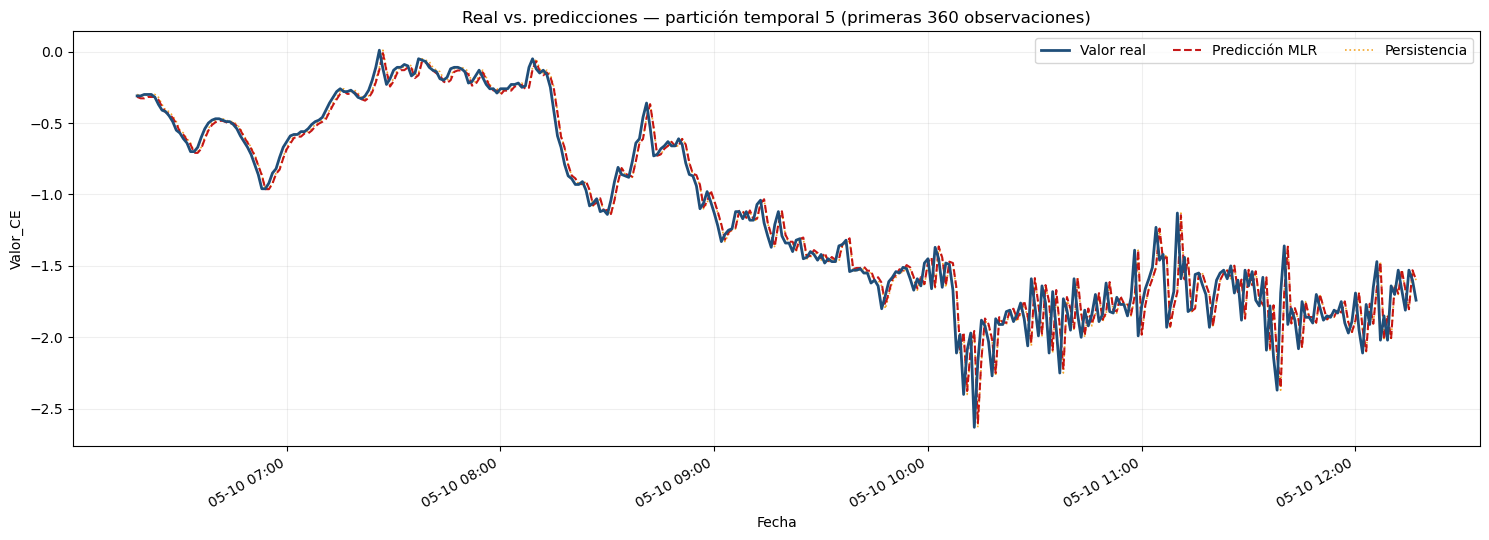

Nota: esta gráfica corresponde a validación interna, no a la prueba final.


In [23]:
# ============================
# Real vs. MLR vs. persistencia — última validación interna
# ============================
particion_grafica = predicciones_cv_mlr["Partición"].max()
cantidad_grafica = 360  # seis horas de datos minuto a minuto
datos_grafica = (
    predicciones_cv_mlr
    .loc[predicciones_cv_mlr["Partición"] == particion_grafica]
    .head(cantidad_grafica)
)

fig, ax = plt.subplots(figsize=(15, 5.5))
ax.plot(datos_grafica["FechaHora"], datos_grafica["Valor_real"],
        label="Valor real", color="#1F4E79", linewidth=2.0, zorder=3)
ax.plot(datos_grafica["FechaHora"], datos_grafica["Predicción_modelo"],
        label="Predicción MLR", color="#C00000", linewidth=1.5,
        linestyle="--", alpha=0.90, zorder=2)
ax.plot(datos_grafica["FechaHora"], datos_grafica["Predicción_persistencia"],
        label="Persistencia", color="#F39C12", linewidth=1.2,
        linestyle=":", alpha=0.90, zorder=1)

ax.set_title(
    f"Real vs. predicciones — partición temporal {particion_grafica} "
    f"(primeras {len(datos_grafica):,} observaciones)"
)
ax.set_xlabel("Fecha")
ax.set_ylabel("Valor_CE")
ax.legend(ncol=3)
ax.grid(alpha=0.20)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%m %H:%M"))
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("Nota: esta gráfica corresponde a validación interna, no a la prueba final.")

In [24]:
# ============================
# Diagnóstico de la inestabilidad de MLR en la partición 2
# ============================
idx_entrenamiento_p2, idx_validacion_p2 = indices_particiones[1]
modelo_mlr_p2 = clone(pipeline_mlr)
modelo_mlr_p2.fit(
    X_train.iloc[idx_entrenamiento_p2],
    y_train.iloc[idx_entrenamiento_p2],
)
prediccion_mlr_p2 = modelo_mlr_p2.predict(X_train.iloc[idx_validacion_p2])

coeficientes_mlr_p2 = pd.DataFrame({
    "Variable": X_train.columns,
    "Coeficiente_estandarizado": modelo_mlr_p2.named_steps["modelo"].coef_,
    "Desviación_entrenamiento": modelo_mlr_p2.named_steps["escalado"].scale_,
})
coeficientes_mlr_p2["Coeficiente_absoluto"] = (
    coeficientes_mlr_p2["Coeficiente_estandarizado"].abs()
)
coeficientes_mlr_p2 = coeficientes_mlr_p2.sort_values(
    "Coeficiente_absoluto", ascending=False
)

print(f"Predicción mínima de MLR en partición 2: {prediccion_mlr_p2.min():,.4f}")
print(f"Predicción máxima de MLR en partición 2: {prediccion_mlr_p2.max():,.4f}")
print("Variables con los coeficientes estandarizados de mayor magnitud:")
display(coeficientes_mlr_p2.head(15).round(6))

Predicción mínima de MLR en partición 2: -5.8360
Predicción máxima de MLR en partición 2: 2.7713
Variables con los coeficientes estandarizados de mayor magnitud:


,Variable,Coeficiente_estandarizado,Desviación_entrenamiento,Coeficiente_absoluto
0,Valor_CE,0.891525,0.908734,0.891525
4,WindSpeed,-0.005040,3.951668,0.005040
2,TempOut,0.004407,2.669470,0.004407
7,SolarRad.,-0.003020,196.338572,0.003020
1,Valor_CM,-0.002965,52.404006,0.002965
8,UVIndex,0.002923,1.526603,0.002923
3,OutHum,-0.001415,5.009682,0.001415
5,Bar,-0.000084,1.561493,0.000084
6,Rain,-0.000000,1.000000,0.000000


### 7.7 Regularización del modelo lineal — Ridge inicial

Ridge limita la magnitud de los coeficientes mediante una penalización L2. Se comienza con `alpha=1.0` como hiperparámetro inicial; todavía no se optimiza. La finalidad inmediata es comprobar si la regularización elimina la explosión observada en la partición 2.

Se mantienen el escalado, las cinco particiones temporales y la comparación con persistencia. El conjunto de prueba continúa reservado.

In [25]:
# ============================
# Pipeline lineal regularizado — Ridge inicial
# ============================
from sklearn.linear_model import Ridge

pipeline_ridge_inicial = Pipeline([
    ("escalado", StandardScaler()),
    ("modelo", Ridge(alpha=1.0)),
])

resultados_cv_ridge, predicciones_cv_ridge = evaluar_modelo_validacion_temporal(
    "Ridge inicial", pipeline_ridge_inicial
)

display(resultados_cv_ridge[columnas_metricas].round(5))

comparacion_lineal_cv = pd.DataFrame({
    "Modelo": ["MLR sin regularización", "Ridge inicial", "Persistencia"],
    "MAE_promedio": [
        resultados_cv_mlr["MAE"].mean(),
        resultados_cv_ridge["MAE"].mean(),
        resultados_cv_mlr["MAE_persistencia"].mean(),
    ],
    "RMSE_promedio": [
        resultados_cv_mlr["RMSE"].mean(),
        resultados_cv_ridge["RMSE"].mean(),
        resultados_cv_mlr["RMSE_persistencia"].mean(),
    ],
    "R2_promedio": [
        resultados_cv_mlr["R2"].mean(),
        resultados_cv_ridge["R2"].mean(),
        resultados_cv_mlr["R2_persistencia"].mean(),
    ],
})

print("Comparación temporal de modelos lineales y línea base:")
display(comparacion_lineal_cv.round(5))
print(f"Prueba final aún reservada: {len(X_test):,} registros")

Partición 1/5 completada — MAE: 0.12472 — 0.0 s
Partición 2/5 completada — MAE: 0.14097 — 0.0 s
Partición 3/5 completada — MAE: 0.12804 — 0.0 s
Partición 4/5 completada — MAE: 0.09978 — 0.0 s
Partición 5/5 completada — MAE: 0.08759 — 0.0 s

INTERPRETABILIDAD — Ridge inicial (última partición temporal)
OBJETIVO (lado izquierdo): Valor_CE_t+1, el campo eléctrico del minuto siguiente.
PREDICTOR Valor_CE (lado derecho): Valor_CE_t, el último valor ya observado.
Coeficiente_unidad_original: cambio esperado en Valor_CE_t+1 por una unidad del predictor, manteniendo lo demás constante.
Ecuación estimada en unidades originales:
Valor_CE_t+1 = 1.341990 +0.976807*Valor_CE_t -0.000043*Valor_CM +0.002750*TempOut -0.000058*OutHum -0.002048*WindSpeed -0.000378*Bar -0.051151*Rain -0.000016*SolarRad. +0.001559*UVIndex
Forma equivalente para el cambio: Valor_CE_t+1 - Valor_CE_t = 1.341990 -0.023193*Valor_CE_t + restantes términos.
El signo del efecto indica asociación predictiva, no causalidad.
'No conc

,Variable,Coeficiente_unidad_original,Coeficiente_escala_modelo,Efecto_medio_al_aumentar_1_DE,Dirección_efecto,Importancia_permutación_RMSE,Desv_importancia,Importancia_relativa_pct,Importancia_nativa,Aporta_con_evidencia
0,Valor_CE,0.976807,0.934477,0.708409,Aumenta,0.863577,0.016652,99.901465,NaN,Sí
1,WindSpeed,-0.002048,-0.009355,-0.010384,Disminuye,0.000559,0.000264,0.064687,NaN,Sí
2,SolarRad.,-0.000016,-0.003614,-0.004320,Disminuye,0.000198,0.000217,0.022952,NaN,No concluyente
3,TempOut,0.002750,0.007820,0.007420,Aumenta,0.000094,0.000488,0.010897,NaN,No concluyente
4,Rain,-0.051151,-0.000131,0.000000,Sin cambio,0.000000,0.000000,0.000000,NaN,No concluyente
5,Bar,-0.000378,-0.000557,-0.000389,Disminuye,-0.000001,0.000015,0.000000,NaN,No concluyente
6,UVIndex,0.001559,0.002769,0.003443,Aumenta,-0.000007,0.000170,0.000000,NaN,No concluyente
7,OutHum,-0.000058,-0.000371,-0.000442,Disminuye,-0.000016,0.000026,0.000000,NaN,No concluyente
8,Valor_CM,-0.000043,-0.002351,-0.002600,Disminuye,-0.000019,0.000083,0.000000,NaN,No concluyente


,Partición,MAE,RMSE,R2,MAE_persistencia,RMSE_persistencia,R2_persistencia,Tiempo_segundos
0,1,0.12472,0.19813,0.95855,0.12464,0.19880,0.95827,0.00476
1,2,0.14097,0.22391,0.95601,0.14053,0.22517,0.95551,0.00624
2,3,0.12804,0.20265,0.95021,0.12690,0.20400,0.94954,0.00906
3,4,0.09978,0.16528,0.96542,0.09771,0.16620,0.96503,0.00983
4,5,0.08759,0.14233,0.96261,0.08616,0.14318,0.96216,0.00875


Comparación temporal de modelos lineales y línea base:


,Modelo,MAE_promedio,RMSE_promedio,R2_promedio
0,MLR sin regularización,0.11622,0.18646,0.95856
1,Ridge inicial,0.11622,0.18646,0.95856
2,Persistencia,0.11519,0.18747,0.95810


Prueba final aún reservada: 36,611 registros


### 7.8 Segundo modelo base — GAM con splines

El modelo aditivo generalizado permite representar relaciones no lineales suaves entre las variables físicas y `Valor_CE_t+1`. Para mantener compatibilidad y controlar memoria se implementa con `SplineTransformer` de scikit-learn y una regresión Ridge sobre las bases spline.

Se aplican splines a `Valor_CE`, `Valor_CM`, `TempOut`, `OutHum`, `WindSpeed`, `Bar`, `SolarRad.` y `UVIndex`. `Rain` permanece como término lineal porque solo toma los valores 0 y 0.20. No existen rezagos, ventanas móviles ni variables de calendario en este enfoque.

Hiperparámetros iniciales: seis nodos, splines de grado 3 y regularización `alpha=1.0`. Su optimización se realizará después de la comparación inicial.

In [26]:
# ============================
# Pipeline GAM inicial con bases spline
# ============================
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import SplineTransformer

variables_suavizadas_gam = [
    "Valor_CE", "Valor_CM", "TempOut", "OutHum",
    "WindSpeed", "Bar", "SolarRad.", "UVIndex",
]

variables_faltantes_gam = set(variables_suavizadas_gam) - set(X_train.columns)
if variables_faltantes_gam:
    raise ValueError(f"Faltan variables para GAM: {sorted(variables_faltantes_gam)}")

preprocesador_gam = ColumnTransformer(
    transformers=[
        (
            "splines",
            SplineTransformer(
                n_knots=6, degree=3, include_bias=False,
                extrapolation="constant",
            ),
            variables_suavizadas_gam,
        ),
    ],
    remainder=StandardScaler(),
)

pipeline_gam_inicial = Pipeline([
    ("preprocesamiento", preprocesador_gam),
    ("modelo", Ridge(alpha=1.0)),
])

resultados_cv_gam, predicciones_cv_gam = evaluar_modelo_validacion_temporal(
    "GAM inicial", pipeline_gam_inicial
)

display(resultados_cv_gam[columnas_metricas].round(5))

comparacion_gam_cv = pd.DataFrame({
    "Modelo": ["GAM inicial", "Ridge inicial", "Persistencia"],
    "MAE_promedio": [
        resultados_cv_gam["MAE"].mean(),
        resultados_cv_ridge["MAE"].mean(),
        resultados_cv_gam["MAE_persistencia"].mean(),
    ],
    "RMSE_promedio": [
        resultados_cv_gam["RMSE"].mean(),
        resultados_cv_ridge["RMSE"].mean(),
        resultados_cv_gam["RMSE_persistencia"].mean(),
    ],
    "R2_promedio": [
        resultados_cv_gam["R2"].mean(),
        resultados_cv_ridge["R2"].mean(),
        resultados_cv_gam["R2_persistencia"].mean(),
    ],
})

print("Comparación temporal inicial de GAM:")
display(comparacion_gam_cv.round(5))
print(f"Prueba final aún reservada: {len(X_test):,} registros")

Partición 1/5 completada — MAE: 0.12828 — 0.1 s
Partición 2/5 completada — MAE: 0.14015 — 0.1 s
Partición 3/5 completada — MAE: 0.12561 — 0.2 s
Partición 4/5 completada — MAE: 0.09790 — 0.2 s
Partición 5/5 completada — MAE: 0.08627 — 0.2 s

INTERPRETABILIDAD — GAM inicial (última partición temporal)
Coeficiente directo por variable: no aplica a este modelo no lineal o con transformación de bases.
El signo del efecto indica asociación predictiva, no causalidad.
'No concluyente' no prueba que la variable sea inútil; puede compartir información con variables correlacionadas.


,Variable,Coeficiente_unidad_original,Coeficiente_escala_modelo,Efecto_medio_al_aumentar_1_DE,Dirección_efecto,Importancia_permutación_RMSE,Desv_importancia,Importancia_relativa_pct,Importancia_nativa,Aporta_con_evidencia
0,Valor_CE,NaN,NaN,0.726230,Aumenta,0.871917,0.017064,99.653422,NaN,Sí
1,UVIndex,NaN,NaN,-0.018286,Disminuye,0.001141,0.000467,0.130433,NaN,Sí
2,SolarRad.,NaN,NaN,0.016866,Aumenta,0.000982,0.000541,0.112214,NaN,No concluyente
3,WindSpeed,NaN,NaN,-0.017143,Disminuye,0.000563,0.000251,0.064314,NaN,Sí
4,TempOut,NaN,NaN,0.003339,Aumenta,0.000137,0.000358,0.015631,NaN,No concluyente
5,Valor_CM,NaN,NaN,0.001007,Aumenta,0.000127,0.000072,0.014540,NaN,No concluyente
6,Bar,NaN,NaN,0.000170,Aumenta,0.000083,0.000028,0.009446,NaN,Sí
7,Rain,NaN,NaN,0.000000,Sin cambio,0.000000,0.000000,0.000000,NaN,No concluyente
8,OutHum,NaN,NaN,0.001393,Aumenta,-0.000439,0.000238,0.000000,NaN,No concluyente


Coeficientes de los términos transformados (p. ej., bases spline del GAM):


,Término_transformado,Coeficiente_modelo,Magnitud
6,splines__Valor_CE_sp_6,4.640031,4.640031
1,splines__Valor_CE_sp_1,-3.926310,3.926310
2,splines__Valor_CE_sp_2,-3.158114,3.158114
5,splines__Valor_CE_sp_5,2.644791,2.644791
3,splines__Valor_CE_sp_3,-1.498074,1.498074
4,splines__Valor_CE_sp_4,0.464511,0.464511
0,splines__Valor_CE_sp_0,-0.389288,0.389288
35,splines__Bar_sp_0,-0.091301,0.091301
21,splines__OutHum_sp_0,0.067215,0.067215
48,splines__SolarRad._sp_6,0.056891,0.056891


,Partición,MAE,RMSE,R2,MAE_persistencia,RMSE_persistencia,R2_persistencia,Tiempo_segundos
0,1,0.12828,0.21355,0.95185,0.12464,0.19880,0.95827,0.05346
1,2,0.14015,0.22257,0.95653,0.14053,0.22517,0.95551,0.11174
2,3,0.12561,0.20034,0.95134,0.12690,0.20400,0.94954,0.15158
3,4,0.09790,0.16526,0.96543,0.09771,0.16620,0.96503,0.18999
4,5,0.08627,0.14153,0.96303,0.08616,0.14318,0.96216,0.22642


Comparación temporal inicial de GAM:


,Modelo,MAE_promedio,RMSE_promedio,R2_promedio
0,GAM inicial,0.11564,0.18865,0.95763
1,Ridge inicial,0.11622,0.18646,0.95856
2,Persistencia,0.11519,0.18747,0.95810


Prueba final aún reservada: 36,611 registros


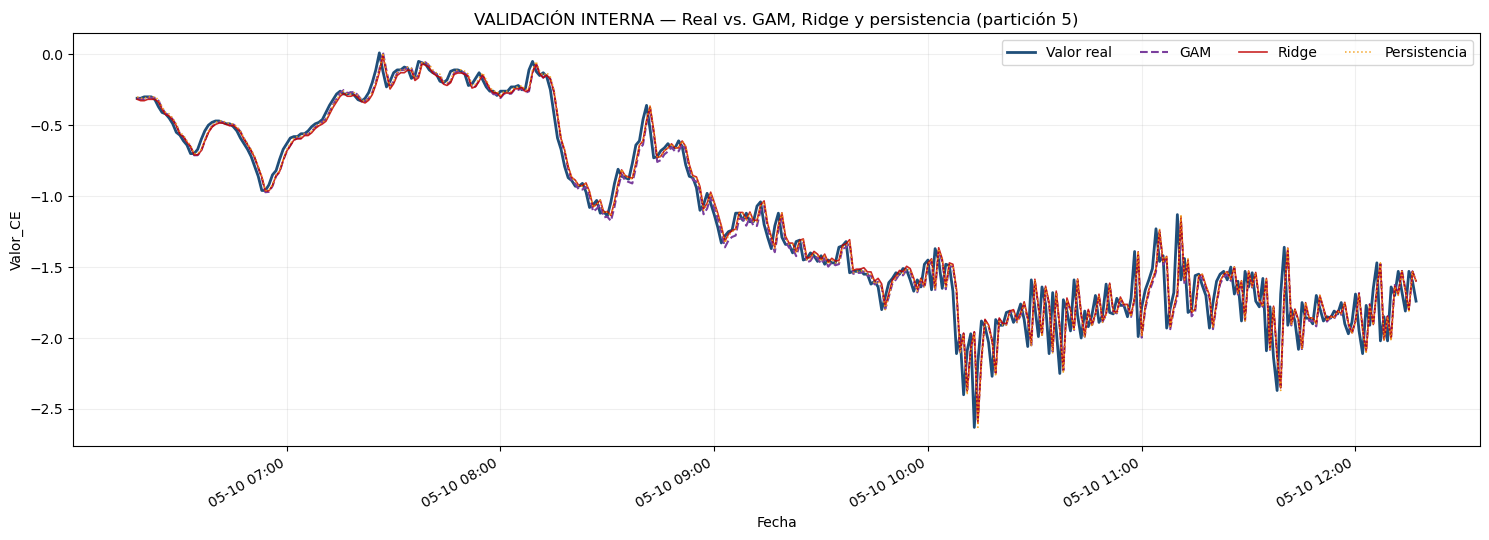

Esta gráfica usa validación interna de la franja azul; no usa el 20 % de prueba.


In [27]:
# ============================
# Comparación visual en la última validación interna
# ============================
particion_grafica_gam = predicciones_cv_gam["Partición"].max()
cantidad_grafica_gam = 360
datos_gam = (
    predicciones_cv_gam
    .loc[predicciones_cv_gam["Partición"] == particion_grafica_gam]
    .head(cantidad_grafica_gam)
    .reset_index(drop=True)
)
datos_ridge = (
    predicciones_cv_ridge
    .loc[predicciones_cv_ridge["Partición"] == particion_grafica_gam]
    .head(cantidad_grafica_gam)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(15, 5.5))
ax.plot(datos_gam["FechaHora"], datos_gam["Valor_real"],
        label="Valor real", color="#1F4E79", linewidth=2.0)
ax.plot(datos_gam["FechaHora"], datos_gam["Predicción_modelo"],
        label="GAM", color="#7A3E9D", linewidth=1.5, linestyle="--")
ax.plot(datos_ridge["FechaHora"], datos_ridge["Predicción_modelo"],
        label="Ridge", color="#C00000", linewidth=1.2, alpha=0.85)
ax.plot(datos_gam["FechaHora"], datos_gam["Predicción_persistencia"],
        label="Persistencia", color="#F39C12", linewidth=1.1,
        linestyle=":", alpha=0.90)

ax.set_title(
    "VALIDACIÓN INTERNA — Real vs. GAM, Ridge y persistencia "
    f"(partición {particion_grafica_gam})"
)
ax.set_xlabel("Fecha")
ax.set_ylabel("Valor_CE")
ax.legend(ncol=4)
ax.grid(alpha=0.20)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%m %H:%M"))
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("Esta gráfica usa validación interna de la franja azul; no usa el 20 % de prueba.")

### 7.9 Modelos de árboles — Random Forest y Extra Trees

Los siguientes modelos permiten capturar interacciones y relaciones no lineales sin requerir escalado. Se evaluarán con las mismas cinco particiones temporales y con parámetros iniciales moderados para controlar el uso de CPU y memoria.

- **Random Forest:** 150 árboles, profundidad máxima 18, mínimo 2 observaciones por hoja, 70 % de variables por división y 80 % de las filas por árbol.
- **Extra Trees:** 150 árboles, profundidad máxima 20, mínimo 2 observaciones por hoja y 70 % de variables por división.

Estos parámetros todavía no están optimizados. Las dos celdas se ejecutan por separado. El 20 % de prueba permanece reservado.

In [28]:
# ============================
# Random Forest — parámetros iniciales
# ============================
from sklearn.ensemble import RandomForestRegressor

modelo_random_forest = RandomForestRegressor(
    n_estimators=150,
    max_depth=18,
    min_samples_leaf=2,
    max_features=0.70,
    max_samples=0.80,
    bootstrap=True,
    n_jobs=-1,
    random_state=42,
)

resultados_cv_rf, predicciones_cv_rf = evaluar_modelo_validacion_temporal(
    "Random Forest inicial", modelo_random_forest
)

display(resultados_cv_rf[columnas_metricas].round(5))
print("Promedios de Random Forest:")
display(
    resultados_cv_rf[["MAE", "RMSE", "R2", "Tiempo_segundos"]]
    .mean().to_frame("Promedio").T.round(5)
)
print(f"Prueba final aún reservada: {len(X_test):,} registros")

Partición 1/5 completada — MAE: 0.14733 — 0.3 s
Partición 2/5 completada — MAE: 0.15116 — 0.4 s
Partición 3/5 completada — MAE: 0.13387 — 0.5 s
Partición 4/5 completada — MAE: 0.10585 — 0.7 s
Partición 5/5 completada — MAE: 0.09096 — 0.8 s

INTERPRETABILIDAD — Random Forest inicial (última partición temporal)
Coeficiente directo por variable: no aplica a este modelo no lineal o con transformación de bases.
El signo del efecto indica asociación predictiva, no causalidad.
'No concluyente' no prueba que la variable sea inútil; puede compartir información con variables correlacionadas.


,Variable,Coeficiente_unidad_original,Coeficiente_escala_modelo,Efecto_medio_al_aumentar_1_DE,Dirección_efecto,Importancia_permutación_RMSE,Desv_importancia,Importancia_relativa_pct,Importancia_nativa,Aporta_con_evidencia
0,Valor_CE,NaN,NaN,0.705855,Aumenta,0.855232,0.016775,98.950685,0.930141,Sí
1,TempOut,NaN,NaN,0.006849,Aumenta,0.004015,0.001515,0.464555,0.011468,Sí
2,WindSpeed,NaN,NaN,-0.013022,Disminuye,0.002659,0.000393,0.307595,0.032106,Sí
3,OutHum,NaN,NaN,-0.004748,Disminuye,0.002110,0.000794,0.244117,0.006842,Sí
4,Valor_CM,NaN,NaN,-0.002043,Disminuye,0.000286,0.000615,0.033048,0.009195,No concluyente
5,Rain,NaN,NaN,0.000000,Sin cambio,0.000000,0.000000,0.000000,0.000000,No concluyente
6,UVIndex,NaN,NaN,-0.005727,Disminuye,-0.000250,0.000243,0.000000,0.001469,No concluyente
7,Bar,NaN,NaN,0.000603,Aumenta,-0.000538,0.000136,0.000000,0.003707,No concluyente
8,SolarRad.,NaN,NaN,-0.002650,Disminuye,-0.002379,0.001123,0.000000,0.005072,No concluyente


,Partición,MAE,RMSE,R2,MAE_persistencia,RMSE_persistencia,R2_persistencia,Tiempo_segundos
0,1,0.14733,0.25492,0.93138,0.12464,0.19880,0.95827,0.28366
1,2,0.15116,0.23543,0.95136,0.14053,0.22517,0.95551,0.41917
2,3,0.13387,0.20678,0.94816,0.12690,0.20400,0.94954,0.53993
3,4,0.10585,0.17626,0.96067,0.09771,0.16620,0.96503,0.69093
4,5,0.09096,0.14548,0.96093,0.08616,0.14318,0.96216,0.83326


Promedios de Random Forest:


,MAE,RMSE,R2,Tiempo_segundos
Promedio,0.12584,0.20378,0.9505,0.55339


Prueba final aún reservada: 36,611 registros


In [29]:
# ============================
# Extra Trees — parámetros iniciales
# ============================
from sklearn.ensemble import ExtraTreesRegressor

modelo_extra_trees = ExtraTreesRegressor(
    n_estimators=150,
    max_depth=20,
    min_samples_leaf=2,
    max_features=0.70,
    bootstrap=False,
    n_jobs=-1,
    random_state=42,
)

resultados_cv_et, predicciones_cv_et = evaluar_modelo_validacion_temporal(
    "Extra Trees inicial", modelo_extra_trees
)

display(resultados_cv_et[columnas_metricas].round(5))
print("Promedios de Extra Trees:")
display(
    resultados_cv_et[["MAE", "RMSE", "R2", "Tiempo_segundos"]]
    .mean().to_frame("Promedio").T.round(5)
)
print(f"Prueba final aún reservada: {len(X_test):,} registros")

Partición 1/5 completada — MAE: 0.16205 — 0.2 s
Partición 2/5 completada — MAE: 0.14982 — 0.2 s
Partición 3/5 completada — MAE: 0.13403 — 0.3 s
Partición 4/5 completada — MAE: 0.11083 — 0.4 s
Partición 5/5 completada — MAE: 0.09367 — 0.4 s

INTERPRETABILIDAD — Extra Trees inicial (última partición temporal)
Coeficiente directo por variable: no aplica a este modelo no lineal o con transformación de bases.
El signo del efecto indica asociación predictiva, no causalidad.
'No concluyente' no prueba que la variable sea inútil; puede compartir información con variables correlacionadas.


,Variable,Coeficiente_unidad_original,Coeficiente_escala_modelo,Efecto_medio_al_aumentar_1_DE,Dirección_efecto,Importancia_permutación_RMSE,Desv_importancia,Importancia_relativa_pct,Importancia_nativa,Aporta_con_evidencia
0,Valor_CE,NaN,NaN,0.683261,Aumenta,0.838498,0.017872,96.785838,0.874243,Sí
1,WindSpeed,NaN,NaN,-0.029653,Disminuye,0.013644,0.000977,1.574911,0.054312,Sí
2,TempOut,NaN,NaN,0.019358,Aumenta,0.008667,0.000494,1.000400,0.025836,Sí
3,OutHum,NaN,NaN,-0.003279,Disminuye,0.002413,0.001486,0.278573,0.015665,No concluyente
4,Valor_CM,NaN,NaN,-0.004738,Disminuye,0.002035,0.000386,0.234951,0.010525,Sí
5,UVIndex,NaN,NaN,-0.018071,Disminuye,0.000656,0.001194,0.075680,0.006215,No concluyente
6,Bar,NaN,NaN,0.001082,Aumenta,0.000430,0.000325,0.049646,0.005326,No concluyente
7,Rain,NaN,NaN,0.000000,Sin cambio,0.000000,0.000000,0.000000,0.000001,No concluyente
8,SolarRad.,NaN,NaN,-0.007992,Disminuye,-0.000123,0.001009,0.000000,0.007878,No concluyente


,Partición,MAE,RMSE,R2,MAE_persistencia,RMSE_persistencia,R2_persistencia,Tiempo_segundos
0,1,0.16205,0.27044,0.92277,0.12464,0.19880,0.95827,0.19760
1,2,0.14982,0.23450,0.95175,0.14053,0.22517,0.95551,0.21238
2,3,0.13403,0.20865,0.94721,0.12690,0.20400,0.94954,0.28216
3,4,0.11083,0.18121,0.95843,0.09771,0.16620,0.96503,0.35012
4,5,0.09367,0.14698,0.96012,0.08616,0.14318,0.96216,0.38996


Promedios de Extra Trees:


,MAE,RMSE,R2,Tiempo_segundos
Promedio,0.13008,0.20836,0.94806,0.28644


Prueba final aún reservada: 36,611 registros


In [30]:
# ============================
# Comparación inicial acumulada
# Ejecutar después de Random Forest y Extra Trees
# ============================
def promedio_modelo(nombre, resultados):
    return {
        "Modelo": nombre,
        "MAE_promedio": resultados["MAE"].mean(),
        "RMSE_promedio": resultados["RMSE"].mean(),
        "R2_promedio": resultados["R2"].mean(),
        "Tiempo_promedio_seg": resultados["Tiempo_segundos"].mean(),
    }

comparacion_modelos_iniciales = pd.DataFrame([
    promedio_modelo("Ridge inicial", resultados_cv_ridge),
    promedio_modelo("GAM inicial", resultados_cv_gam),
    promedio_modelo("Random Forest inicial", resultados_cv_rf),
    promedio_modelo("Extra Trees inicial", resultados_cv_et),
    {
        "Modelo": "Persistencia",
        "MAE_promedio": resultados_cv_rf["MAE_persistencia"].mean(),
        "RMSE_promedio": resultados_cv_rf["RMSE_persistencia"].mean(),
        "R2_promedio": resultados_cv_rf["R2_persistencia"].mean(),
        "Tiempo_promedio_seg": 0.0,
    },
])

comparacion_modelos_iniciales = comparacion_modelos_iniciales.sort_values(
    ["RMSE_promedio", "MAE_promedio"]
).reset_index(drop=True)
display(comparacion_modelos_iniciales.round(5))

,Modelo,MAE_promedio,RMSE_promedio,R2_promedio,Tiempo_promedio_seg
0,Ridge inicial,0.11622,0.18646,0.95856,0.00773
1,Persistencia,0.11519,0.18747,0.95810,0.00000
2,GAM inicial,0.11564,0.18865,0.95763,0.14664
3,Random Forest inicial,0.12584,0.20378,0.95050,0.55339
4,Extra Trees inicial,0.13008,0.20836,0.94806,0.28644


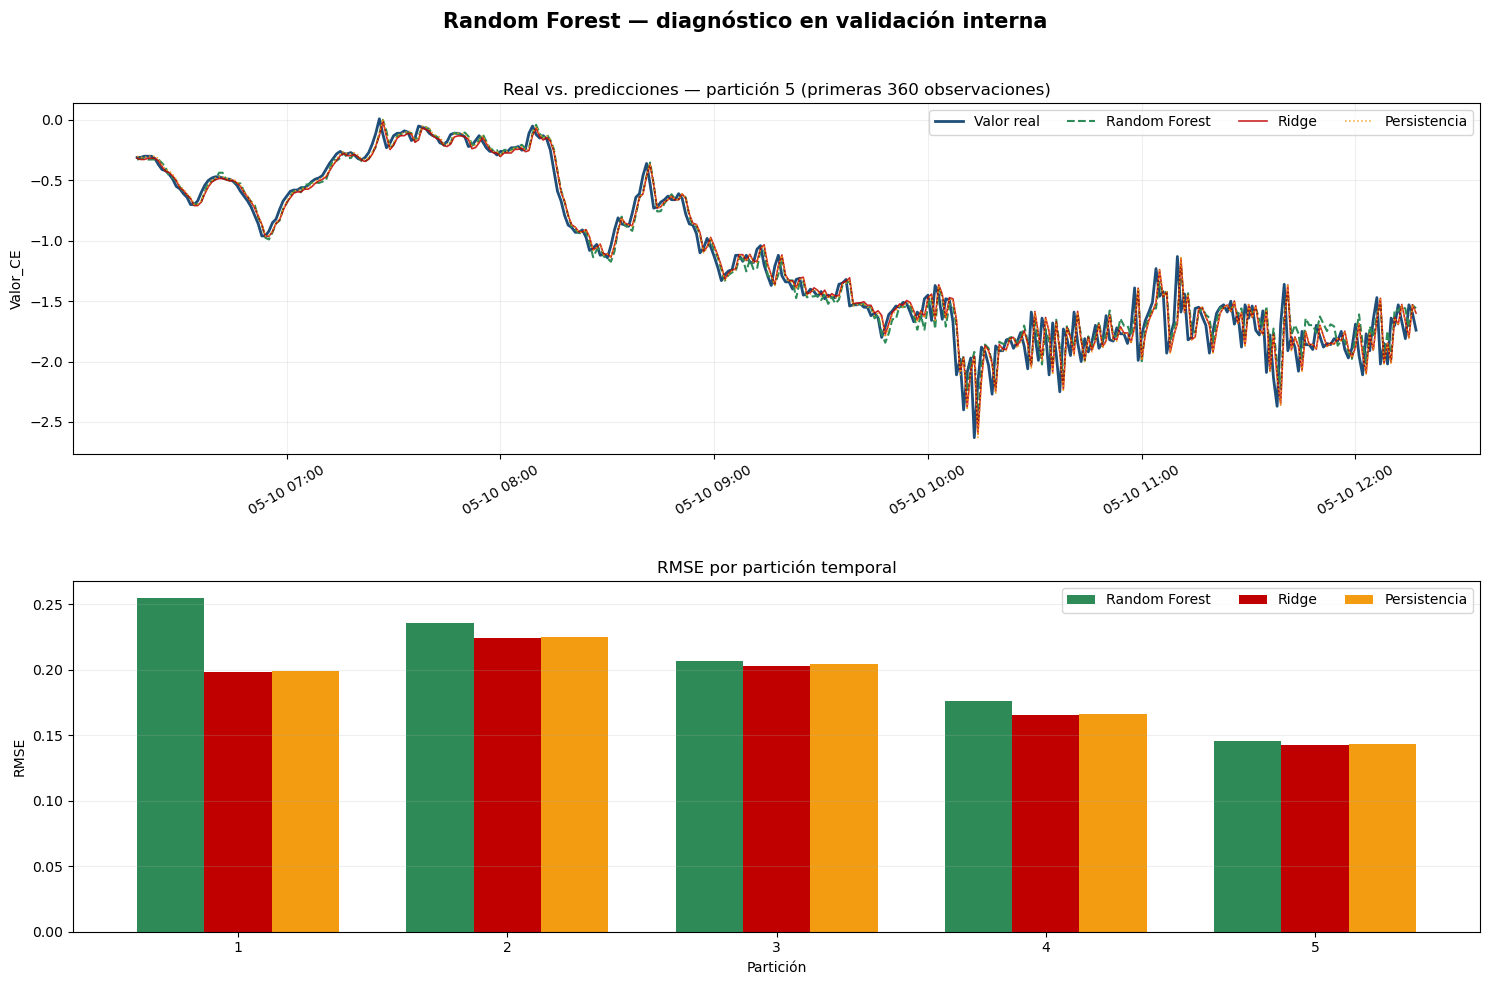

Ambas gráficas usan validación interna; el 20 % de prueba sigue reservado.


In [31]:
# ============================
# Diagnóstico visual de Random Forest — validación interna
# ============================
particion_grafica_rf = predicciones_cv_rf["Partición"].max()
cantidad_grafica_rf = 360
datos_rf = (
    predicciones_cv_rf
    .loc[predicciones_cv_rf["Partición"] == particion_grafica_rf]
    .head(cantidad_grafica_rf)
    .reset_index(drop=True)
)
datos_ridge_rf = (
    predicciones_cv_ridge
    .loc[predicciones_cv_ridge["Partición"] == particion_grafica_rf]
    .head(cantidad_grafica_rf)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(2, 1, figsize=(15, 10))
fig.suptitle("Random Forest — diagnóstico en validación interna",
             fontsize=15, fontweight="bold")

axes[0].plot(datos_rf["FechaHora"], datos_rf["Valor_real"],
             label="Valor real", color="#1F4E79", linewidth=2.0)
axes[0].plot(datos_rf["FechaHora"], datos_rf["Predicción_modelo"],
             label="Random Forest", color="#2E8B57", linewidth=1.5,
             linestyle="--")
axes[0].plot(datos_ridge_rf["FechaHora"], datos_ridge_rf["Predicción_modelo"],
             label="Ridge", color="#C00000", linewidth=1.2, alpha=0.85)
axes[0].plot(datos_rf["FechaHora"], datos_rf["Predicción_persistencia"],
             label="Persistencia", color="#F39C12", linewidth=1.1,
             linestyle=":", alpha=0.90)
axes[0].set_title(
    f"Real vs. predicciones — partición {particion_grafica_rf} "
    f"(primeras {len(datos_rf):,} observaciones)"
)
axes[0].set_ylabel("Valor_CE")
axes[0].legend(ncol=4)
axes[0].grid(alpha=0.20)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%d-%m %H:%M"))
axes[0].tick_params(axis="x", rotation=30)

posiciones = np.arange(1, NUMERO_PARTICIONES + 1)
ancho = 0.25
axes[1].bar(posiciones - ancho, resultados_cv_rf["RMSE"], ancho,
            label="Random Forest", color="#2E8B57")
axes[1].bar(posiciones, resultados_cv_ridge["RMSE"], ancho,
            label="Ridge", color="#C00000")
axes[1].bar(posiciones + ancho, resultados_cv_rf["RMSE_persistencia"], ancho,
            label="Persistencia", color="#F39C12")
axes[1].set_title("RMSE por partición temporal")
axes[1].set_xlabel("Partición")
axes[1].set_ylabel("RMSE")
axes[1].set_xticks(posiciones)
axes[1].legend(ncol=3)
axes[1].grid(axis="y", alpha=0.20)

plt.tight_layout(rect=[0, 0, 1, 0.96], h_pad=3.0)
plt.show()
print("Ambas gráficas usan validación interna; el 20 % de prueba sigue reservado.")

### 7.10 Preparación de modelos boosting

Los siguientes modelos base son XGBoost, LightGBM y CatBoost. Antes de crear sus pipelines se verifica si las bibliotecas están disponibles en el entorno del cuaderno. Esta celda solo consulta el entorno: no instala paquetes, no entrena modelos y no usa la prueba final.

In [32]:
# ============================
# Verificar disponibilidad de bibliotecas boosting
# ============================
from importlib.util import find_spec

librerias_boosting = {
    "XGBoost": "xgboost",
    "LightGBM": "lightgbm",
    "CatBoost": "catboost",
}

disponibilidad_boosting = pd.DataFrame([
    {"Modelo": modelo, "Paquete": paquete,
     "Disponible": find_spec(paquete) is not None}
    for modelo, paquete in librerias_boosting.items()
])

display(disponibilidad_boosting)

if disponibilidad_boosting["Disponible"].all():
    print("Las tres bibliotecas están disponibles.")
else:
    faltantes = disponibilidad_boosting.loc[
        ~disponibilidad_boosting["Disponible"], "Paquete"
    ].tolist()
    print(f"Bibliotecas faltantes: {faltantes}")
    print("No se instalará nada automáticamente.")

,Modelo,Paquete,Disponible
0,XGBoost,xgboost,True
1,LightGBM,lightgbm,True
2,CatBoost,catboost,True


Las tres bibliotecas están disponibles.


### 7.11 Modelos boosting — configuración inicial

Las bibliotecas XGBoost, LightGBM y CatBoost están disponibles. Los tres modelos se evaluarán por separado sobre las mismas cinco particiones temporales. Al ser modelos basados en árboles no requieren estandarización.

Se utilizan inicialmente 300 iteraciones y una tasa de aprendizaje de 0.05. También se incorporan muestreo de filas/columnas y regularización para reducir sobreajuste. Estos hiperparámetros todavía no están optimizados.

> Cada celda puede tardar varios minutos. Debe terminarse un modelo antes de ejecutar el siguiente. Ninguno utiliza el 20 % de prueba.

In [33]:
# ============================
# XGBoost — parámetros iniciales
# ============================
from xgboost import XGBRegressor

modelo_xgboost = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:squarederror",
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
    verbosity=0,
)

resultados_cv_xgb, predicciones_cv_xgb = evaluar_modelo_validacion_temporal(
    "XGBoost inicial", modelo_xgboost
)

display(resultados_cv_xgb[columnas_metricas].round(5))
print("Promedios de XGBoost:")
display(
    resultados_cv_xgb[["MAE", "RMSE", "R2", "Tiempo_segundos"]]
    .mean().to_frame("Promedio").T.round(5)
)
print(f"Prueba final aún reservada: {len(X_test):,} registros")

Partición 1/5 completada — MAE: 0.16234 — 0.6 s
Partición 2/5 completada — MAE: 0.16102 — 1.1 s
Partición 3/5 completada — MAE: 0.14551 — 0.7 s
Partición 4/5 completada — MAE: 0.12572 — 0.9 s
Partición 5/5 completada — MAE: 0.09787 — 1.0 s

INTERPRETABILIDAD — XGBoost inicial (última partición temporal)
Coeficiente directo por variable: no aplica a este modelo no lineal o con transformación de bases.
El signo del efecto indica asociación predictiva, no causalidad.
'No concluyente' no prueba que la variable sea inútil; puede compartir información con variables correlacionadas.


,Variable,Coeficiente_unidad_original,Coeficiente_escala_modelo,Efecto_medio_al_aumentar_1_DE,Dirección_efecto,Importancia_permutación_RMSE,Desv_importancia,Importancia_relativa_pct,Importancia_nativa,Aporta_con_evidencia
0,Valor_CE,NaN,NaN,0.698313,Aumenta,0.830660,0.015377,96.919167,0.842703,Sí
1,OutHum,NaN,NaN,-0.003129,Disminuye,0.007341,0.001413,0.856471,0.025934,Sí
2,WindSpeed,NaN,NaN,-0.031808,Disminuye,0.006378,0.001291,0.744185,0.057657,Sí
3,TempOut,NaN,NaN,0.013581,Aumenta,0.004550,0.001218,0.530882,0.030195,Sí
4,Valor_CM,NaN,NaN,-0.011141,Disminuye,0.004413,0.000650,0.514911,0.012024,Sí
5,UVIndex,NaN,NaN,-0.036243,Disminuye,0.001981,0.001789,0.231127,0.011957,No concluyente
6,SolarRad.,NaN,NaN,-0.005426,Disminuye,0.001742,0.002070,0.203257,0.008865,No concluyente
7,Rain,NaN,NaN,0.000000,Sin cambio,0.000000,0.000000,0.000000,0.000000,No concluyente
8,Bar,NaN,NaN,0.004096,Aumenta,-0.000443,0.000630,0.000000,0.010665,No concluyente


,Partición,MAE,RMSE,R2,MAE_persistencia,RMSE_persistencia,R2_persistencia,Tiempo_segundos
0,1,0.16234,0.28025,0.91706,0.12464,0.19880,0.95827,0.55433
1,2,0.16102,0.25175,0.94439,0.14053,0.22517,0.95551,1.08945
2,3,0.14551,0.22037,0.94112,0.12690,0.20400,0.94954,0.67084
3,4,0.12572,0.20761,0.94544,0.09771,0.16620,0.96503,0.94690
4,5,0.09787,0.15014,0.95839,0.08616,0.14318,0.96216,1.04479


Promedios de XGBoost:


,MAE,RMSE,R2,Tiempo_segundos
Promedio,0.13849,0.22202,0.94128,0.86126


Prueba final aún reservada: 36,611 registros


In [34]:
# ============================
# LightGBM — parámetros iniciales
# ============================
from lightgbm import LGBMRegressor

modelo_lightgbm = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=30,
    subsample=0.80,
    subsample_freq=1,
    colsample_bytree=0.80,
    reg_alpha=0.0,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=42,
    verbosity=-1,
)

resultados_cv_lgbm, predicciones_cv_lgbm = evaluar_modelo_validacion_temporal(
    "LightGBM inicial", modelo_lightgbm
)

display(resultados_cv_lgbm[columnas_metricas].round(5))
print("Promedios de LightGBM:")
display(
    resultados_cv_lgbm[["MAE", "RMSE", "R2", "Tiempo_segundos"]]
    .mean().to_frame("Promedio").T.round(5)
)
print(f"Prueba final aún reservada: {len(X_test):,} registros")

Partición 1/5 completada — MAE: 0.15789 — 1.8 s
Partición 2/5 completada — MAE: 0.15855 — 1.8 s
Partición 3/5 completada — MAE: 0.14121 — 3.7 s
Partición 4/5 completada — MAE: 0.11252 — 2.6 s
Partición 5/5 completada — MAE: 0.09446 — 3.0 s

INTERPRETABILIDAD — LightGBM inicial (última partición temporal)
Coeficiente directo por variable: no aplica a este modelo no lineal o con transformación de bases.
El signo del efecto indica asociación predictiva, no causalidad.
'No concluyente' no prueba que la variable sea inútil; puede compartir información con variables correlacionadas.


,Variable,Coeficiente_unidad_original,Coeficiente_escala_modelo,Efecto_medio_al_aumentar_1_DE,Dirección_efecto,Importancia_permutación_RMSE,Desv_importancia,Importancia_relativa_pct,Importancia_nativa,Aporta_con_evidencia
0,Valor_CE,NaN,NaN,0.710665,Aumenta,0.838328,0.015469,97.814056,2110,Sí
1,WindSpeed,NaN,NaN,-0.042152,Disminuye,0.007253,0.000596,0.846241,854,Sí
2,Valor_CM,NaN,NaN,-0.007977,Disminuye,0.005198,0.001047,0.606517,1597,Sí
3,OutHum,NaN,NaN,-0.004441,Disminuye,0.004854,0.001886,0.566353,1041,Sí
4,TempOut,NaN,NaN,0.010965,Aumenta,0.000937,0.001100,0.109353,1192,No concluyente
5,UVIndex,NaN,NaN,-0.015347,Disminuye,0.000493,0.000480,0.057480,420,No concluyente
6,Rain,NaN,NaN,0.000000,Sin cambio,0.000000,0.000000,0.000000,0,No concluyente
7,Bar,NaN,NaN,0.002820,Aumenta,-0.000303,0.000373,0.000000,969,No concluyente
8,SolarRad.,NaN,NaN,-0.000857,Disminuye,-0.000739,0.000759,0.000000,817,No concluyente


,Partición,MAE,RMSE,R2,MAE_persistencia,RMSE_persistencia,R2_persistencia,Tiempo_segundos
0,1,0.15789,0.27231,0.92170,0.12464,0.19880,0.95827,1.82135
1,2,0.15855,0.24508,0.94730,0.14053,0.22517,0.95551,1.84315
2,3,0.14121,0.21441,0.94426,0.12690,0.20400,0.94954,3.72497
3,4,0.11252,0.19321,0.95274,0.09771,0.16620,0.96503,2.57804
4,5,0.09446,0.14690,0.96017,0.08616,0.14318,0.96216,3.01758


Promedios de LightGBM:


,MAE,RMSE,R2,Tiempo_segundos
Promedio,0.13293,0.21438,0.94523,2.59702


Prueba final aún reservada: 36,611 registros


In [35]:
# ============================
# CatBoost — parámetros iniciales
# ============================
from catboost import CatBoostRegressor

modelo_catboost = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    l2_leaf_reg=3.0,
    random_seed=42,
    thread_count=-1,
    verbose=False,
    allow_writing_files=False,
)

resultados_cv_cat, predicciones_cv_cat = evaluar_modelo_validacion_temporal(
    "CatBoost inicial", modelo_catboost
)

display(resultados_cv_cat[columnas_metricas].round(5))
print("Promedios de CatBoost:")
display(
    resultados_cv_cat[["MAE", "RMSE", "R2", "Tiempo_segundos"]]
    .mean().to_frame("Promedio").T.round(5)
)
print(f"Prueba final aún reservada: {len(X_test):,} registros")

Partición 1/5 completada — MAE: 0.14095 — 0.6 s
Partición 2/5 completada — MAE: 0.14521 — 0.7 s
Partición 3/5 completada — MAE: 0.12766 — 0.9 s
Partición 4/5 completada — MAE: 0.10420 — 1.0 s
Partición 5/5 completada — MAE: 0.08779 — 1.1 s

INTERPRETABILIDAD — CatBoost inicial (última partición temporal)
Coeficiente directo por variable: no aplica a este modelo no lineal o con transformación de bases.
El signo del efecto indica asociación predictiva, no causalidad.
'No concluyente' no prueba que la variable sea inútil; puede compartir información con variables correlacionadas.


,Variable,Coeficiente_unidad_original,Coeficiente_escala_modelo,Efecto_medio_al_aumentar_1_DE,Dirección_efecto,Importancia_permutación_RMSE,Desv_importancia,Importancia_relativa_pct,Importancia_nativa,Aporta_con_evidencia
0,Valor_CE,NaN,NaN,0.729133,Aumenta,0.865170,0.016691,99.770411,98.394303,Sí
1,OutHum,NaN,NaN,-0.003457,Disminuye,0.000936,0.000706,0.107912,0.321042,No concluyente
2,TempOut,NaN,NaN,0.005402,Aumenta,0.000489,0.000182,0.056442,0.254061,Sí
3,Valor_CM,NaN,NaN,-0.001794,Disminuye,0.000405,0.000729,0.046720,0.395406,No concluyente
4,WindSpeed,NaN,NaN,-0.010109,Disminuye,0.000114,0.000448,0.013179,0.161269,No concluyente
5,Bar,NaN,NaN,0.000553,Aumenta,0.000046,0.000059,0.005336,0.145146,No concluyente
6,Rain,NaN,NaN,0.000000,Sin cambio,0.000000,0.000000,0.000000,0.001038,No concluyente
7,UVIndex,NaN,NaN,-0.003216,Disminuye,-0.000001,0.000247,0.000000,0.151915,No concluyente
8,SolarRad.,NaN,NaN,-0.001985,Disminuye,-0.000649,0.000333,0.000000,0.175821,No concluyente


,Partición,MAE,RMSE,R2,MAE_persistencia,RMSE_persistencia,R2_persistencia,Tiempo_segundos
0,1,0.14095,0.24756,0.93529,0.12464,0.19880,0.95827,0.58344
1,2,0.14521,0.23199,0.95277,0.14053,0.22517,0.95551,0.69266
2,3,0.12766,0.20309,0.94999,0.12690,0.20400,0.94954,0.85614
3,4,0.10420,0.18135,0.95837,0.09771,0.16620,0.96503,0.99282
4,5,0.08779,0.14236,0.96259,0.08616,0.14318,0.96216,1.14995


Promedios de CatBoost:


,MAE,RMSE,R2,Tiempo_segundos
Promedio,0.12116,0.20127,0.9518,0.855


Prueba final aún reservada: 36,611 registros


In [36]:
# ============================
# Comparación acumulada de modelos iniciales
# Ejecutar después de los tres modelos boosting
# ============================
comparacion_modelos_iniciales = pd.DataFrame([
    promedio_modelo("Ridge inicial", resultados_cv_ridge),
    promedio_modelo("GAM inicial", resultados_cv_gam),
    promedio_modelo("Random Forest inicial", resultados_cv_rf),
    promedio_modelo("Extra Trees inicial", resultados_cv_et),
    promedio_modelo("XGBoost inicial", resultados_cv_xgb),
    promedio_modelo("LightGBM inicial", resultados_cv_lgbm),
    promedio_modelo("CatBoost inicial", resultados_cv_cat),
    {
        "Modelo": "Persistencia",
        "MAE_promedio": resultados_cv_xgb["MAE_persistencia"].mean(),
        "RMSE_promedio": resultados_cv_xgb["RMSE_persistencia"].mean(),
        "R2_promedio": resultados_cv_xgb["R2_persistencia"].mean(),
        "Tiempo_promedio_seg": 0.0,
    },
])

comparacion_modelos_iniciales = comparacion_modelos_iniciales.sort_values(
    ["RMSE_promedio", "MAE_promedio"]
).reset_index(drop=True)
display(comparacion_modelos_iniciales.round(5))

,Modelo,MAE_promedio,RMSE_promedio,R2_promedio,Tiempo_promedio_seg
0,Ridge inicial,0.11622,0.18646,0.95856,0.00773
1,Persistencia,0.11519,0.18747,0.95810,0.00000
2,GAM inicial,0.11564,0.18865,0.95763,0.14664
3,CatBoost inicial,0.12116,0.20127,0.95180,0.85500
4,Random Forest inicial,0.12584,0.20378,0.95050,0.55339
5,Extra Trees inicial,0.13008,0.20836,0.94806,0.28644
6,LightGBM inicial,0.13293,0.21438,0.94523,2.59702
7,XGBoost inicial,0.13849,0.22202,0.94128,0.86126


### 7.12 SVR y MLP

Se completan los modelos base con SVR de kernel RBF y una red neuronal MLP. Ambos requieren estandarización.

El costo de SVR crece aproximadamente de forma cuadrática con la cantidad de observaciones. Para evitar bloquear el entorno, en cada partición se utilizan como máximo las **20,000 observaciones de entrenamiento más recientes**, manteniendo completa la validación posterior. Esta limitación debe considerarse al interpretar su resultado.

MLP utiliza todos los registros disponibles en cada partición, dos capas ocultas, regularización L2 y orden temporal sin barajar. Los parámetros son iniciales y todavía no están optimizados.

In [37]:
# ============================
# Evaluación temporal con límite opcional de entrenamiento
# Usada para SVR por costo computacional
# ============================
def evaluar_modelo_validacion_limitada(nombre_modelo, modelo, max_entrenamiento):
    resultados = []
    predicciones_validacion = []
    ultimo_modelo = None
    ultimo_X_validacion = None
    ultimo_y_validacion = None

    for particion, (idx_entrenamiento, idx_validacion) in enumerate(
        indices_particiones, start=1
    ):
        idx_entrenamiento_usado = idx_entrenamiento[-max_entrenamiento:]
        X_entrenamiento_cv = X_train.iloc[idx_entrenamiento_usado]
        y_entrenamiento_cv = y_train.iloc[idx_entrenamiento_usado]
        X_validacion_cv = X_train.iloc[idx_validacion]
        y_validacion_cv = y_train.iloc[idx_validacion]

        modelo_particion = clone(modelo)
        inicio = perf_counter()
        modelo_particion.fit(X_entrenamiento_cv, y_entrenamiento_cv)
        prediccion_modelo = modelo_particion.predict(X_validacion_cv)
        segundos = perf_counter() - inicio
        metricas_modelo = evaluar_predicciones(y_validacion_cv, prediccion_modelo)
        metricas_base = evaluar_predicciones(
            y_validacion_cv, X_validacion_cv["Valor_CE"].to_numpy()
        )

        resultados.append({
            "Modelo": nombre_modelo, "Partición": particion,
            **metricas_modelo, "Tiempo_segundos": segundos,
            "MAE_persistencia": metricas_base["MAE"],
            "RMSE_persistencia": metricas_base["RMSE"],
            "R2_persistencia": metricas_base["R2"],
            "Registros_entrenamiento": len(idx_entrenamiento_usado),
            "Registros_validación": len(idx_validacion),
        })
        predicciones_validacion.append(pd.DataFrame({
            "FechaHora": fechas_train.iloc[idx_validacion].to_numpy(),
            "Partición": particion,
            "Valor_real": np.asarray(y_validacion_cv),
            "Predicción_modelo": np.asarray(prediccion_modelo),
            "Predicción_persistencia": X_validacion_cv["Valor_CE"].to_numpy(),
        }))
        ultimo_modelo = modelo_particion
        ultimo_X_validacion = X_validacion_cv
        ultimo_y_validacion = y_validacion_cv
        print(
            f"Partición {particion}/{NUMERO_PARTICIONES} — "
            f"entrenamiento usado: {len(idx_entrenamiento_usado):,} — "
            f"MAE: {metricas_modelo['MAE']:.5f} — {segundos:.1f} s"
        )

    mostrar_interpretabilidad_modelo(
        f"{nombre_modelo} (última partición temporal)",
        ultimo_modelo, ultimo_X_validacion, ultimo_y_validacion,
    )
    return pd.DataFrame(resultados), pd.concat(predicciones_validacion, ignore_index=True)

In [38]:
# ============================
# SVR RBF — parámetros iniciales
# ============================
from sklearn.svm import SVR

MAX_ENTRENAMIENTO_SVR = 20_000
pipeline_svr_inicial = Pipeline([
    ("escalado", StandardScaler()),
    ("modelo", SVR(C=10.0, epsilon=0.05, gamma="scale",
                    kernel="rbf", cache_size=2048)),
])

resultados_cv_svr, predicciones_cv_svr = evaluar_modelo_validacion_limitada(
    "SVR inicial", pipeline_svr_inicial, MAX_ENTRENAMIENTO_SVR
)
display(resultados_cv_svr[columnas_metricas].round(5))
display(
    resultados_cv_svr[["MAE", "RMSE", "R2", "Tiempo_segundos"]]
    .mean().to_frame("Promedio").T.round(5)
)
print(f"Prueba final aún reservada: {len(X_test):,} registros")

Partición 1/5 — entrenamiento usado: 20,000 — MAE: 0.19938 — 14.6 s
Partición 2/5 — entrenamiento usado: 20,000 — MAE: 0.19011 — 19.6 s
Partición 3/5 — entrenamiento usado: 20,000 — MAE: 0.22343 — 18.9 s
Partición 4/5 — entrenamiento usado: 20,000 — MAE: 0.27807 — 18.5 s
Partición 5/5 — entrenamiento usado: 20,000 — MAE: 0.12353 — 15.3 s

INTERPRETABILIDAD — SVR inicial (última partición temporal)
Coeficiente directo por variable: no aplica a este modelo no lineal o con transformación de bases.
El signo del efecto indica asociación predictiva, no causalidad.
'No concluyente' no prueba que la variable sea inútil; puede compartir información con variables correlacionadas.


,Variable,Coeficiente_unidad_original,Coeficiente_escala_modelo,Efecto_medio_al_aumentar_1_DE,Dirección_efecto,Importancia_permutación_RMSE,Desv_importancia,Importancia_relativa_pct,Importancia_nativa,Aporta_con_evidencia
0,Valor_CE,NaN,NaN,0.615678,Aumenta,0.732642,0.016685,63.457054,NaN,Sí
1,TempOut,NaN,NaN,0.096521,Aumenta,0.106858,0.008375,9.255378,NaN,Sí
2,UVIndex,NaN,NaN,-0.130184,Disminuye,0.105616,0.002652,9.147791,NaN,Sí
3,OutHum,NaN,NaN,-0.026200,Disminuye,0.086480,0.006886,7.490412,NaN,Sí
4,SolarRad.,NaN,NaN,-0.003068,Disminuye,0.061623,0.002424,5.337434,NaN,Sí
5,WindSpeed,NaN,NaN,-0.027366,Disminuye,0.029479,0.004267,2.553260,NaN,Sí
6,Valor_CM,NaN,NaN,-0.010199,Disminuye,0.026278,0.008604,2.276034,NaN,Sí
7,Bar,NaN,NaN,-0.000686,Disminuye,0.005572,0.001695,0.482636,NaN,Sí
8,Rain,NaN,NaN,0.000000,Sin cambio,0.000000,0.000000,0.000000,NaN,No concluyente


,Partición,MAE,RMSE,R2,MAE_persistencia,RMSE_persistencia,R2_persistencia,Tiempo_segundos
0,1,0.19938,0.33869,0.87887,0.12464,0.19880,0.95827,14.58764
1,2,0.19011,0.28732,0.92756,0.14053,0.22517,0.95551,19.63392
2,3,0.22343,0.33093,0.86722,0.12690,0.20400,0.94954,18.86910
3,4,0.27807,0.45583,0.73697,0.09771,0.16620,0.96503,18.47379
4,5,0.12353,0.20362,0.92347,0.08616,0.14318,0.96216,15.28767


,MAE,RMSE,R2,Tiempo_segundos
Promedio,0.2029,0.32328,0.86682,17.37043


Prueba final aún reservada: 36,611 registros


In [39]:
# ============================
# MLP — parámetros iniciales
# ============================
from sklearn.neural_network import MLPRegressor

pipeline_mlp_inicial = Pipeline([
    ("escalado", StandardScaler()),
    ("modelo", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        learning_rate_init=0.001,
        max_iter=100,
        early_stopping=False,
        shuffle=False,
        random_state=42,
    )),
])

resultados_cv_mlp, predicciones_cv_mlp = evaluar_modelo_validacion_temporal(
    "MLP inicial", pipeline_mlp_inicial
)
display(resultados_cv_mlp[columnas_metricas].round(5))
display(
    resultados_cv_mlp[["MAE", "RMSE", "R2", "Tiempo_segundos"]]
    .mean().to_frame("Promedio").T.round(5)
)
print(f"Prueba final aún reservada: {len(X_test):,} registros")

Partición 1/5 completada — MAE: 0.15334 — 0.7 s
Partición 2/5 completada — MAE: 0.15307 — 1.3 s
Partición 3/5 completada — MAE: 0.14408 — 2.4 s
Partición 4/5 completada — MAE: 0.12072 — 4.2 s
Partición 5/5 completada — MAE: 0.09340 — 6.4 s

INTERPRETABILIDAD — MLP inicial (última partición temporal)
Coeficiente directo por variable: no aplica a este modelo no lineal o con transformación de bases.
El signo del efecto indica asociación predictiva, no causalidad.
'No concluyente' no prueba que la variable sea inútil; puede compartir información con variables correlacionadas.


,Variable,Coeficiente_unidad_original,Coeficiente_escala_modelo,Efecto_medio_al_aumentar_1_DE,Dirección_efecto,Importancia_permutación_RMSE,Desv_importancia,Importancia_relativa_pct,Importancia_nativa,Aporta_con_evidencia
0,Valor_CE,NaN,NaN,0.702435,Aumenta,0.843385,0.015432,95.428043,NaN,Sí
1,TempOut,NaN,NaN,-0.012457,Disminuye,0.014603,0.002402,1.652320,NaN,Sí
2,OutHum,NaN,NaN,-0.014299,Disminuye,0.010412,0.002350,1.178152,NaN,Sí
3,WindSpeed,NaN,NaN,-0.018370,Disminuye,0.005436,0.000681,0.615061,NaN,Sí
4,Valor_CM,NaN,NaN,0.007774,Aumenta,0.003624,0.000439,0.410090,NaN,Sí
5,UVIndex,NaN,NaN,-0.017349,Disminuye,0.003580,0.002109,0.405052,NaN,No concluyente
6,SolarRad.,NaN,NaN,0.028828,Aumenta,0.002751,0.001420,0.311283,NaN,No concluyente
7,Rain,NaN,NaN,0.000000,Sin cambio,0.000000,0.000000,0.000000,NaN,No concluyente
8,Bar,NaN,NaN,0.003160,Aumenta,-0.001121,0.000028,0.000000,NaN,No concluyente


,Partición,MAE,RMSE,R2,MAE_persistencia,RMSE_persistencia,R2_persistencia,Tiempo_segundos
0,1,0.15334,0.21955,0.94910,0.12464,0.19880,0.95827,0.73814
1,2,0.15307,0.22980,0.95366,0.14053,0.22517,0.95551,1.32779
2,3,0.14408,0.22017,0.94122,0.12690,0.20400,0.94954,2.43042
3,4,0.12072,0.18954,0.95452,0.09771,0.16620,0.96503,4.15230
4,5,0.09340,0.14783,0.95966,0.08616,0.14318,0.96216,6.36756


,MAE,RMSE,R2,Tiempo_segundos
Promedio,0.13292,0.20138,0.95163,3.00324


Prueba final aún reservada: 36,611 registros


In [40]:
# ============================
# Comparación completa de modelos base
# Ejecutar después de SVR y MLP
# ============================
resultados_base_por_nombre = {
    "Ridge inicial": resultados_cv_ridge,
    "GAM inicial": resultados_cv_gam,
    "Random Forest inicial": resultados_cv_rf,
    "Extra Trees inicial": resultados_cv_et,
    "XGBoost inicial": resultados_cv_xgb,
    "LightGBM inicial": resultados_cv_lgbm,
    "CatBoost inicial": resultados_cv_cat,
    "SVR inicial": resultados_cv_svr,
    "MLP inicial": resultados_cv_mlp,
}

modelos_base_por_nombre = {
    "Ridge inicial": pipeline_ridge_inicial,
    "GAM inicial": pipeline_gam_inicial,
    "Random Forest inicial": modelo_random_forest,
    "Extra Trees inicial": modelo_extra_trees,
    "XGBoost inicial": modelo_xgboost,
    "LightGBM inicial": modelo_lightgbm,
    "CatBoost inicial": modelo_catboost,
    "SVR inicial": pipeline_svr_inicial,
    "MLP inicial": pipeline_mlp_inicial,
}

predicciones_base_por_nombre = {
    "Ridge inicial": predicciones_cv_ridge,
    "GAM inicial": predicciones_cv_gam,
    "Random Forest inicial": predicciones_cv_rf,
    "Extra Trees inicial": predicciones_cv_et,
    "XGBoost inicial": predicciones_cv_xgb,
    "LightGBM inicial": predicciones_cv_lgbm,
    "CatBoost inicial": predicciones_cv_cat,
    "SVR inicial": predicciones_cv_svr,
    "MLP inicial": predicciones_cv_mlp,
}

filas_comparacion = [
    promedio_modelo(nombre, resultados)
    for nombre, resultados in resultados_base_por_nombre.items()
]
filas_comparacion.append({
    "Modelo": "Persistencia",
    "MAE_promedio": resultados_cv_rf["MAE_persistencia"].mean(),
    "RMSE_promedio": resultados_cv_rf["RMSE_persistencia"].mean(),
    "R2_promedio": resultados_cv_rf["R2_persistencia"].mean(),
    "Tiempo_promedio_seg": 0.0,
})

comparacion_modelos_base = pd.DataFrame(filas_comparacion).sort_values(
    ["RMSE_promedio", "MAE_promedio"]
).reset_index(drop=True)
comparacion_modelos_base.insert(0, "Posición_RMSE", np.arange(1, len(comparacion_modelos_base) + 1))
display(comparacion_modelos_base.round(5))

print("MLR sin regularización no participa en el ranking por su inestabilidad numérica.")
print("SVR se evaluó con un máximo de 20,000 observaciones de entrenamiento por partición.")
print(f"Prueba final aún reservada: {len(X_test):,} registros")

,Posición_RMSE,Modelo,MAE_promedio,RMSE_promedio,R2_promedio,Tiempo_promedio_seg
0,1,Ridge inicial,0.11622,0.18646,0.95856,0.00773
1,2,Persistencia,0.11519,0.18747,0.95810,0.00000
2,3,GAM inicial,0.11564,0.18865,0.95763,0.14664
3,4,CatBoost inicial,0.12116,0.20127,0.95180,0.85500
4,5,MLP inicial,0.13292,0.20138,0.95163,3.00324
5,6,Random Forest inicial,0.12584,0.20378,0.95050,0.55339
6,7,Extra Trees inicial,0.13008,0.20836,0.94806,0.28644
7,8,LightGBM inicial,0.13293,0.21438,0.94523,2.59702
8,9,XGBoost inicial,0.13849,0.22202,0.94128,0.86126
9,10,SVR inicial,0.20290,0.32328,0.86682,17.37043


MLR sin regularización no participa en el ranking por su inestabilidad numérica.
SVR se evaluó con un máximo de 20,000 observaciones de entrenamiento por partición.
Prueba final aún reservada: 36,611 registros


### 7.13 Ejecución de la optimización

Ejecutar esta sección únicamente después de completar la comparación de todos los modelos base. Selecciona los tres mejores candidatos ajustables, optimiza sus hiperparámetros dentro del entrenamiento y regenera sus predicciones OOF.

In [41]:
# ============================
# Optimización temporal ejecutable
# ============================
from sklearn.model_selection import RandomizedSearchCV

espacios_busqueda = {
    "Ridge inicial": {"modelo__alpha": np.logspace(-3, 2, 30)},
    "GAM inicial": {
        "preprocesamiento__splines__n_knots": [4, 5, 6, 8, 10],
        "preprocesamiento__splines__degree": [2, 3],
        "modelo__alpha": np.logspace(-2, 2, 20),
    },
    "Random Forest inicial": {
        "n_estimators": [150, 250, 350], "max_depth": [12, 18, 24, None],
        "min_samples_leaf": [1, 2, 4, 8], "max_features": [0.5, 0.7, 1.0],
        "max_samples": [0.7, 0.85, 1.0],
    },
    "Extra Trees inicial": {
        "n_estimators": [150, 250, 350], "max_depth": [14, 20, 28, None],
        "min_samples_leaf": [1, 2, 4, 8], "max_features": [0.5, 0.7, 1.0],
    },
    "XGBoost inicial": {
        "n_estimators": [200, 300, 450, 600], "learning_rate": [0.02, 0.05, 0.08],
        "max_depth": [3, 4, 6, 8], "min_child_weight": [1, 3, 5, 10],
        "subsample": [0.7, 0.85, 1.0], "colsample_bytree": [0.6, 0.8, 1.0],
        "reg_lambda": [0.5, 1.0, 5.0, 10.0],
    },
    "LightGBM inicial": {
        "n_estimators": [200, 300, 450, 600], "learning_rate": [0.02, 0.05, 0.08],
        "num_leaves": [15, 31, 63, 127], "min_child_samples": [15, 30, 60],
        "subsample": [0.7, 0.85, 1.0], "colsample_bytree": [0.6, 0.8, 1.0],
        "reg_lambda": [0.5, 1.0, 5.0, 10.0],
    },
    "CatBoost inicial": {
        "iterations": [200, 300, 450, 600], "learning_rate": [0.02, 0.05, 0.08],
        "depth": [4, 6, 8, 10], "l2_leaf_reg": [1.0, 3.0, 5.0, 10.0],
    },
    "MLP inicial": {
        "modelo__hidden_layer_sizes": [(32,), (64,), (64, 32), (128, 64)],
        "modelo__alpha": np.logspace(-5, -2, 10),
        "modelo__learning_rate_init": [0.0003, 0.001, 0.003],
    },
}

ranking_ajustables = comparacion_modelos_base[
    comparacion_modelos_base["Modelo"].isin(espacios_busqueda)
].sort_values("RMSE_promedio")
modelos_seleccionados_optimizar = ranking_ajustables["Modelo"].head(3).tolist()
print(f"Modelos seleccionados: {modelos_seleccionados_optimizar}")

modelos_optimizados, busquedas_optimizacion, resumen_optimizacion = {}, {}, []
for nombre in modelos_seleccionados_optimizar:
    print(f"\nOptimizando {nombre}...")
    busqueda = RandomizedSearchCV(
        clone(modelos_base_por_nombre[nombre]), espacios_busqueda[nombre],
        n_iter=6, scoring="neg_root_mean_squared_error", cv=validacion_temporal,
        refit=True, n_jobs=1, random_state=42, verbose=1, return_train_score=True,
    )
    inicio = perf_counter()
    busqueda.fit(X_train, y_train)
    tiempo_total = perf_counter() - inicio
    indice = busqueda.best_index_
    rmse_train = -busqueda.cv_results_["mean_train_score"][indice]
    rmse_val = -busqueda.best_score_
    modelos_optimizados[nombre] = busqueda.best_estimator_
    busquedas_optimizacion[nombre] = busqueda
    resumen_optimizacion.append({
        "Modelo": nombre, "RMSE_train": rmse_train,
        "RMSE_validación": rmse_val,
        "Brecha_validación_train": rmse_val - rmse_train,
        "Tiempo_total_seg": tiempo_total,
        "Mejores_parámetros": busqueda.best_params_,
    })
    print(f"RMSE validación: {rmse_val:.5f}")
    print(busqueda.best_params_)

df_resumen_optimizacion = pd.DataFrame(resumen_optimizacion)
display(df_resumen_optimizacion)
print(f"Prueba final aún reservada: {len(X_test):,} registros")

Modelos seleccionados: ['Ridge inicial', 'GAM inicial', 'CatBoost inicial']

Optimizando Ridge inicial...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
RMSE validación: 0.18646
{'modelo__alpha': 0.02395026619987486}

Optimizando GAM inicial...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
RMSE validación: 0.18609
{'preprocesamiento__splines__n_knots': 4, 'preprocesamiento__splines__degree': 2, 'modelo__alpha': 0.04281332398719394}

Optimizando CatBoost inicial...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
RMSE validación: 0.19302
{'learning_rate': 0.02, 'l2_leaf_reg': 10.0, 'iterations': 600, 'depth': 4}


,Modelo,RMSE_train,RMSE_validación,Brecha_validación_train,Tiempo_total_seg,Mejores_parámetros
0,Ridge inicial,0.173742,0.186458,0.012716,0.424160,{'modelo__alpha': 0.02395026619987486}
1,GAM inicial,0.172082,0.186087,0.014005,6.577741,"{'preprocesamiento__splines__n_knots': 4, 'pre..."
2,CatBoost inicial,0.172046,0.193022,0.020975,63.160211,"{'learning_rate': 0.02, 'l2_leaf_reg': 10.0, '..."


Prueba final aún reservada: 36,611 registros


In [42]:
# ============================
# Regenerar OOF con mejores hiperparámetros
# ============================
modelos_finales_por_nombre = dict(modelos_base_por_nombre)
resultados_finales_oof = dict(resultados_base_por_nombre)
predicciones_finales_oof = dict(predicciones_base_por_nombre)

for nombre, modelo_optimizado in modelos_optimizados.items():
    resultados_opt, predicciones_opt = evaluar_modelo_validacion_temporal(
        f"{nombre} optimizado", modelo_optimizado
    )
    modelos_finales_por_nombre[nombre] = modelo_optimizado
    resultados_finales_oof[nombre] = resultados_opt
    predicciones_finales_oof[nombre] = predicciones_opt

comparacion_post_optimizacion = pd.DataFrame([
    promedio_modelo(nombre, resultados)
    for nombre, resultados in resultados_finales_oof.items()
]).sort_values(["RMSE_promedio", "MAE_promedio"]).reset_index(drop=True)
comparacion_post_optimizacion.insert(0, "Posición_RMSE",
                                     np.arange(1, len(comparacion_post_optimizacion) + 1))
display(comparacion_post_optimizacion.round(5))
print("Predicciones OOF optimizadas listas; la prueba continúa reservada.")

Partición 1/5 completada — MAE: 0.12471 — 0.0 s
Partición 2/5 completada — MAE: 0.14097 — 0.0 s
Partición 3/5 completada — MAE: 0.12804 — 0.0 s
Partición 4/5 completada — MAE: 0.09977 — 0.0 s
Partición 5/5 completada — MAE: 0.08758 — 0.0 s

INTERPRETABILIDAD — Ridge inicial optimizado (última partición temporal)
OBJETIVO (lado izquierdo): Valor_CE_t+1, el campo eléctrico del minuto siguiente.
PREDICTOR Valor_CE (lado derecho): Valor_CE_t, el último valor ya observado.
Coeficiente_unidad_original: cambio esperado en Valor_CE_t+1 por una unidad del predictor, manteniendo lo demás constante.
Ecuación estimada en unidades originales:
Valor_CE_t+1 = 1.341146 +0.976816*Valor_CE_t -0.000043*Valor_CM +0.002749*TempOut -0.000058*OutHum -0.002048*WindSpeed -0.000377*Bar -0.051161*Rain -0.000016*SolarRad. +0.001560*UVIndex
Forma equivalente para el cambio: Valor_CE_t+1 - Valor_CE_t = 1.341146 -0.023184*Valor_CE_t + restantes términos.
El signo del efecto indica asociación predictiva, no causalida

,Variable,Coeficiente_unidad_original,Coeficiente_escala_modelo,Efecto_medio_al_aumentar_1_DE,Dirección_efecto,Importancia_permutación_RMSE,Desv_importancia,Importancia_relativa_pct,Importancia_nativa,Aporta_con_evidencia
0,Valor_CE,0.976816,0.934486,0.708416,Aumenta,0.863582,0.016652,99.901549,NaN,Sí
1,WindSpeed,-0.002048,-0.009352,-0.010380,Disminuye,0.000559,0.000264,0.064628,NaN,Sí
2,SolarRad.,-0.000016,-0.003614,-0.004320,Disminuye,0.000198,0.000217,0.022950,NaN,No concluyente
3,TempOut,0.002749,0.007817,0.007417,Aumenta,0.000094,0.000487,0.010873,NaN,No concluyente
4,Rain,-0.051161,-0.000131,0.000000,Sin cambio,0.000000,0.000000,0.000000,NaN,No concluyente
5,Bar,-0.000377,-0.000557,-0.000389,Disminuye,-0.000001,0.000015,0.000000,NaN,No concluyente
6,UVIndex,0.001560,0.002769,0.003444,Aumenta,-0.000007,0.000170,0.000000,NaN,No concluyente
7,OutHum,-0.000058,-0.000371,-0.000442,Disminuye,-0.000016,0.000026,0.000000,NaN,No concluyente
8,Valor_CM,-0.000043,-0.002349,-0.002598,Disminuye,-0.000019,0.000083,0.000000,NaN,No concluyente


Partición 1/5 completada — MAE: 0.12581 — 0.0 s
Partición 2/5 completada — MAE: 0.13956 — 0.1 s
Partición 3/5 completada — MAE: 0.12555 — 0.1 s
Partición 4/5 completada — MAE: 0.09816 — 0.1 s
Partición 5/5 completada — MAE: 0.08627 — 0.1 s

INTERPRETABILIDAD — GAM inicial optimizado (última partición temporal)
Coeficiente directo por variable: no aplica a este modelo no lineal o con transformación de bases.
El signo del efecto indica asociación predictiva, no causalidad.
'No concluyente' no prueba que la variable sea inútil; puede compartir información con variables correlacionadas.


,Variable,Coeficiente_unidad_original,Coeficiente_escala_modelo,Efecto_medio_al_aumentar_1_DE,Dirección_efecto,Importancia_permutación_RMSE,Desv_importancia,Importancia_relativa_pct,Importancia_nativa,Aporta_con_evidencia
0,Valor_CE,NaN,NaN,0.719481,Aumenta,0.872640,0.017091,99.747715,NaN,Sí
1,UVIndex,NaN,NaN,-0.014061,Disminuye,0.000733,0.000370,0.083822,NaN,No concluyente
2,SolarRad.,NaN,NaN,0.015053,Aumenta,0.000631,0.000444,0.072169,NaN,No concluyente
3,WindSpeed,NaN,NaN,-0.018953,Disminuye,0.000431,0.000251,0.049225,NaN,No concluyente
4,TempOut,NaN,NaN,0.002798,Aumenta,0.000223,0.000335,0.025517,NaN,No concluyente
5,Valor_CM,NaN,NaN,0.001891,Aumenta,0.000139,0.000083,0.015835,NaN,No concluyente
6,Bar,NaN,NaN,0.000210,Aumenta,0.000050,0.000023,0.005716,NaN,Sí
7,Rain,NaN,NaN,0.000000,Sin cambio,0.000000,0.000000,0.000000,NaN,No concluyente
8,OutHum,NaN,NaN,0.003503,Aumenta,-0.000480,0.000310,0.000000,NaN,No concluyente


Coeficientes de los términos transformados (p. ej., bases spline del GAM):


,Término_transformado,Coeficiente_modelo,Magnitud
0,splines__Valor_CE_sp_0,-11.492283,11.492283
1,splines__Valor_CE_sp_1,-9.438308,9.438308
2,splines__Valor_CE_sp_2,-6.564251,6.564251
3,splines__Valor_CE_sp_3,-2.966160,2.966160
16,splines__WindSpeed_sp_0,0.211108,0.211108
17,splines__WindSpeed_sp_1,0.180265,0.180265
18,splines__WindSpeed_sp_2,0.178555,0.178555
19,splines__WindSpeed_sp_3,0.170292,0.170292
24,splines__SolarRad._sp_0,-0.118899,0.118899
25,splines__SolarRad._sp_1,-0.113047,0.113047


Partición 1/5 completada — MAE: 0.13204 — 0.8 s
Partición 2/5 completada — MAE: 0.14319 — 1.0 s
Partición 3/5 completada — MAE: 0.12616 — 1.3 s
Partición 4/5 completada — MAE: 0.09895 — 1.5 s
Partición 5/5 completada — MAE: 0.08708 — 1.8 s

INTERPRETABILIDAD — CatBoost inicial optimizado (última partición temporal)
Coeficiente directo por variable: no aplica a este modelo no lineal o con transformación de bases.
El signo del efecto indica asociación predictiva, no causalidad.
'No concluyente' no prueba que la variable sea inútil; puede compartir información con variables correlacionadas.


,Variable,Coeficiente_unidad_original,Coeficiente_escala_modelo,Efecto_medio_al_aumentar_1_DE,Dirección_efecto,Importancia_permutación_RMSE,Desv_importancia,Importancia_relativa_pct,Importancia_nativa,Aporta_con_evidencia
0,Valor_CE,NaN,NaN,0.731879,Aumenta,0.869642,0.016577,99.832342,99.627363,Sí
1,OutHum,NaN,NaN,-0.002919,Disminuye,0.000551,0.000491,0.063212,0.091025,No concluyente
2,Valor_CM,NaN,NaN,-0.001145,Disminuye,0.000516,0.000534,0.059282,0.099109,No concluyente
3,TempOut,NaN,NaN,0.002014,Aumenta,0.000342,0.000161,0.039285,0.060825,Sí
4,Bar,NaN,NaN,0.000011,Aumenta,0.000038,0.000012,0.004391,0.013273,Sí
5,WindSpeed,NaN,NaN,-0.005644,Disminuye,0.000013,0.000270,0.001489,0.037414,No concluyente
6,Rain,NaN,NaN,0.000000,Sin cambio,0.000000,0.000000,0.000000,0.000001,No concluyente
7,SolarRad.,NaN,NaN,-0.001592,Disminuye,-0.000083,0.000092,0.000000,0.036729,No concluyente
8,UVIndex,NaN,NaN,-0.001955,Disminuye,-0.000127,0.000021,0.000000,0.034262,No concluyente


,Posición_RMSE,Modelo,MAE_promedio,RMSE_promedio,R2_promedio,Tiempo_promedio_seg
0,1,GAM inicial,0.11507,0.18609,0.95874,0.09711
1,2,Ridge inicial,0.11622,0.18646,0.95856,0.00602
2,3,CatBoost inicial,0.11749,0.19302,0.95570,1.29434
3,4,MLP inicial,0.13292,0.20138,0.95163,3.00324
4,5,Random Forest inicial,0.12584,0.20378,0.95050,0.55339
5,6,Extra Trees inicial,0.13008,0.20836,0.94806,0.28644
6,7,LightGBM inicial,0.13293,0.21438,0.94523,2.59702
7,8,XGBoost inicial,0.13849,0.22202,0.94128,0.86126
8,9,SVR inicial,0.20290,0.32328,0.86682,17.37043


Predicciones OOF optimizadas listas; la prueba continúa reservada.


### 7.14 Stacking y metamodelos

Se seleccionan los cinco mejores modelos base estables por RMSE OOF. Sus predicciones OOF se integran cronológicamente para formar el nivel 1 del stacking. Ninguna fila OOF fue predicha por un modelo entrenado con esa misma fila.

Se comparan tres metamodelos: **ElasticNet** como primera opción, **Ridge** y **XGBoost**. Los hiperparámetros se seleccionan mediante validación temporal dentro de la matriz OOF. La elección entre el mejor metamodelo y el mejor modelo base se realiza antes de abrir la prueba final.

In [43]:
# ============================
# Construir matriz OOF para stacking
# ============================
modelos_stacking_nombres = comparacion_post_optimizacion["Modelo"].head(5).tolist()
print(f"Modelos base seleccionados para stacking: {modelos_stacking_nombres}")

df_oof_meta = None
mapeo_columnas_meta = {}
for numero, nombre in enumerate(modelos_stacking_nombres, start=1):
    columna_meta = f"Base_{numero:02d}"
    mapeo_columnas_meta[columna_meta] = nombre
    pred = predicciones_finales_oof[nombre][
        ["FechaHora", "Partición", "Valor_real", "Predicción_modelo"]
    ].copy()
    pred = pred.rename(columns={"Predicción_modelo": columna_meta})
    if pred.duplicated(["FechaHora", "Partición"]).any():
        raise ValueError(f"Predicciones OOF duplicadas para {nombre}.")
    if df_oof_meta is None:
        df_oof_meta = pred
    else:
        pred = pred.drop(columns="Valor_real")
        df_oof_meta = df_oof_meta.merge(
            pred, on=["FechaHora", "Partición"], how="inner",
            validate="one_to_one",
        )

df_oof_meta = df_oof_meta.sort_values("FechaHora").reset_index(drop=True)
columnas_meta = list(mapeo_columnas_meta)
if df_oof_meta[columnas_meta + ["Valor_real"]].isna().any().any():
    raise ValueError("La matriz OOF contiene valores nulos.")

X_meta = df_oof_meta[columnas_meta].copy()
y_meta = df_oof_meta["Valor_real"].copy()
fechas_meta = df_oof_meta["FechaHora"].copy()
validacion_meta = TimeSeriesSplit(n_splits=5, gap=HORIZONTE)

display(pd.DataFrame({
    "Columna_meta": list(mapeo_columnas_meta),
    "Modelo_base": list(mapeo_columnas_meta.values()),
}))
print(f"Registros OOF para el metamodelo: {len(X_meta):,}")
print(f"Periodo OOF: {fechas_meta.min()} → {fechas_meta.max()}")

Modelos base seleccionados para stacking: ['GAM inicial', 'Ridge inicial', 'CatBoost inicial', 'MLP inicial', 'Random Forest inicial']


,Columna_meta,Modelo_base
0,Base_01,GAM inicial
1,Base_02,Ridge inicial
2,Base_03,CatBoost inicial
3,Base_04,MLP inicial
4,Base_05,Random Forest inicial


Registros OOF para el metamodelo: 122,035
Periodo OOF: 2025-05-29 18:40:00 → 2025-10-29 00:54:00


In [44]:
# ============================
# Entrenar y comparar metamodelos
# ============================
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV

pipeline_meta_elasticnet = Pipeline([
    ("escalado", StandardScaler()),
    ("modelo", ElasticNet(max_iter=50_000, random_state=42)),
])
pipeline_meta_ridge = Pipeline([
    ("escalado", StandardScaler()),
    ("modelo", Ridge()),
])
modelo_meta_xgb = XGBRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=3,
    subsample=0.85, colsample_bytree=0.90, reg_lambda=1.0,
    objective="reg:squarederror", tree_method="hist",
    n_jobs=-1, random_state=42, verbosity=0,
)

busqueda_meta_elasticnet = GridSearchCV(
    pipeline_meta_elasticnet,
    {"modelo__alpha": np.logspace(-5, -1, 8),
     "modelo__l1_ratio": [0.1, 0.5, 0.9]},
    scoring="neg_root_mean_squared_error", cv=validacion_meta,
    n_jobs=1, refit=True,
)
busqueda_meta_ridge = GridSearchCV(
    pipeline_meta_ridge,
    {"modelo__alpha": np.logspace(-4, 3, 20)},
    scoring="neg_root_mean_squared_error", cv=validacion_meta,
    n_jobs=1, refit=True,
)
busqueda_meta_xgb = RandomizedSearchCV(
    modelo_meta_xgb,
    {"n_estimators": [100, 200, 300, 450],
     "learning_rate": [0.02, 0.05, 0.08],
     "max_depth": [2, 3, 4, 5],
     "min_child_weight": [1, 3, 5],
     "reg_lambda": [0.5, 1.0, 5.0]},
    n_iter=8, scoring="neg_root_mean_squared_error", cv=validacion_meta,
    n_jobs=1, random_state=42, refit=True,
)

busquedas_meta = {
    "ElasticNet meta": busqueda_meta_elasticnet,
    "Ridge meta": busqueda_meta_ridge,
    "XGBoost meta": busqueda_meta_xgb,
}
resumen_meta, metamodelos_optimizados = [], {}
for nombre, busqueda in busquedas_meta.items():
    inicio = perf_counter()
    busqueda.fit(X_meta, y_meta)
    segundos = perf_counter() - inicio
    metamodelos_optimizados[nombre] = busqueda.best_estimator_
    resumen_meta.append({
        "Metamodelo": nombre,
        "RMSE_CV": -busqueda.best_score_,
        "Tiempo_segundos": segundos,
        "Mejores_parámetros": busqueda.best_params_,
    })
    print(f"{nombre}: RMSE CV = {-busqueda.best_score_:.5f}")

comparacion_metamodelos = pd.DataFrame(resumen_meta).sort_values("RMSE_CV").reset_index(drop=True)
display(comparacion_metamodelos)

mejor_meta_nombre = comparacion_metamodelos.loc[0, "Metamodelo"]
mejor_metamodelo = metamodelos_optimizados[mejor_meta_nombre]
mejor_base_nombre = comparacion_post_optimizacion.loc[0, "Modelo"]
rmse_mejor_base_cv = comparacion_post_optimizacion.loc[0, "RMSE_promedio"]
rmse_mejor_meta_cv = comparacion_metamodelos.loc[0, "RMSE_CV"]

if rmse_mejor_meta_cv < rmse_mejor_base_cv:
    seleccion_preprueba = {"Tipo": "Metamodelo", "Nombre": mejor_meta_nombre,
                           "RMSE_CV": rmse_mejor_meta_cv}
else:
    seleccion_preprueba = {"Tipo": "Modelo base", "Nombre": mejor_base_nombre,
                           "RMSE_CV": rmse_mejor_base_cv}

print("Selección congelada antes de abrir la prueba:")
display(pd.DataFrame([seleccion_preprueba]))
print(f"Prueba final aún reservada: {len(X_test):,} registros")

ElasticNet meta: RMSE CV = 0.18311
Ridge meta: RMSE CV = 0.18324
XGBoost meta: RMSE CV = 0.18532


,Metamodelo,RMSE_CV,Tiempo_segundos,Mejores_parámetros
0,ElasticNet meta,0.183113,64.267944,"{'modelo__alpha': 0.007196856730011514, 'model..."
1,Ridge meta,0.183238,0.503932,{'modelo__alpha': 33.59818286283781}
2,XGBoost meta,0.185320,47.547106,"{'reg_lambda': 0.5, 'n_estimators': 100, 'min_..."


Selección congelada antes de abrir la prueba:


,Tipo,Nombre,RMSE_CV
0,Metamodelo,ElasticNet meta,0.183113


Prueba final aún reservada: 36,611 registros


## 📐 Fase 5 — Evaluation

### 8. Evaluación final reservada

Los modelos seleccionados se reentrenan con el 80 % disponible y se evalúan una sola vez sobre el 20 % final. La selección no se modifica después de observar la prueba.


In [45]:
# ============================
# EVALUACIÓN FINAL — apertura única del 20 % de prueba
# ============================
modelos_base_entrenados = {}
X_meta_test = pd.DataFrame(index=X_test.index)

for columna_meta, nombre in mapeo_columnas_meta.items():
    modelo = clone(modelos_finales_por_nombre[nombre])
    if nombre == "SVR inicial":
        X_ajuste = X_train.iloc[-MAX_ENTRENAMIENTO_SVR:]
        y_ajuste = y_train.iloc[-MAX_ENTRENAMIENTO_SVR:]
        print(f"{nombre}: ajuste final limitado a {len(X_ajuste):,} registros.")
    else:
        X_ajuste, y_ajuste = X_train, y_train

    inicio = perf_counter()
    modelo.fit(X_ajuste, y_ajuste)
    X_meta_test[columna_meta] = modelo.predict(X_test)
    modelos_base_entrenados[nombre] = modelo
    print(f"{nombre} entrenado y predicho en {perf_counter() - inicio:.1f} s")

X_meta_test = X_meta_test[columnas_meta]
predicciones_test_meta = {
    nombre: modelo.predict(X_meta_test)
    for nombre, modelo in metamodelos_optimizados.items()
}
prediccion_test_persistencia = X_test["Valor_CE"].to_numpy()

filas_metricas_test = []
for columna_meta, nombre in mapeo_columnas_meta.items():
    filas_metricas_test.append({
        "Tipo": "Modelo base", "Modelo": nombre,
        **evaluar_predicciones(y_test, X_meta_test[columna_meta]),
    })
for nombre, prediccion in predicciones_test_meta.items():
    filas_metricas_test.append({
        "Tipo": "Metamodelo", "Modelo": nombre,
        **evaluar_predicciones(y_test, prediccion),
    })
filas_metricas_test.append({
    "Tipo": "Línea base", "Modelo": "Persistencia",
    **evaluar_predicciones(y_test, prediccion_test_persistencia),
})
metricas_prueba_final = pd.DataFrame(filas_metricas_test).sort_values(
    ["RMSE", "MAE"]
).reset_index(drop=True)
display(metricas_prueba_final.round(5))

if seleccion_preprueba["Tipo"] == "Metamodelo":
    nombre_modelo_final = seleccion_preprueba["Nombre"]
    prediccion_modelo_final = predicciones_test_meta[nombre_modelo_final]
else:
    nombre_modelo_final = seleccion_preprueba["Nombre"]
    columna_final = next(
        columna for columna, nombre in mapeo_columnas_meta.items()
        if nombre == nombre_modelo_final
    )
    prediccion_modelo_final = X_meta_test[columna_final].to_numpy()

metricas_modelo_final = evaluar_predicciones(y_test, prediccion_modelo_final)
metricas_persistencia_test = evaluar_predicciones(y_test, prediccion_test_persistencia)
mejora_mae_pct = 100 * (metricas_persistencia_test["MAE"] - metricas_modelo_final["MAE"]) / metricas_persistencia_test["MAE"]
mejora_rmse_pct = 100 * (metricas_persistencia_test["RMSE"] - metricas_modelo_final["RMSE"]) / metricas_persistencia_test["RMSE"]

print("\nMODELO FINAL SELECCIONADO ANTES DE PRUEBA")
print(f"Tipo: {seleccion_preprueba['Tipo']}")
print(f"Modelo: {nombre_modelo_final}")
print(f"MAE prueba: {metricas_modelo_final['MAE']:.5f}")
print(f"RMSE prueba: {metricas_modelo_final['RMSE']:.5f}")
print(f"R² prueba: {metricas_modelo_final['R2']:.5f}")
print(f"Mejora MAE frente a persistencia: {mejora_mae_pct:.2f}%")
print(f"Mejora RMSE frente a persistencia: {mejora_rmse_pct:.2f}%")

GAM inicial entrenado y predicho en 0.2 s
Ridge inicial entrenado y predicho en 0.0 s
CatBoost inicial entrenado y predicho en 2.2 s
MLP inicial entrenado y predicho en 6.2 s
Random Forest inicial entrenado y predicho en 1.0 s


,Tipo,Modelo,MAE,RMSE,R2
0,Metamodelo,ElasticNet meta,0.06926,0.11172,0.96702
1,Metamodelo,Ridge meta,0.06884,0.11193,0.96690
2,Modelo base,CatBoost inicial,0.06950,0.11208,0.96681
3,Modelo base,Ridge inicial,0.06986,0.11211,0.96679
4,Metamodelo,XGBoost meta,0.06974,0.11224,0.96671
5,Modelo base,GAM inicial,0.06952,0.11267,0.96646
6,Línea base,Persistencia,0.06892,0.11282,0.96637
7,Modelo base,Random Forest inicial,0.07145,0.11330,0.96608
8,Modelo base,MLP inicial,0.07640,0.11634,0.96424



MODELO FINAL SELECCIONADO ANTES DE PRUEBA
Tipo: Metamodelo
Modelo: ElasticNet meta
MAE prueba: 0.06926
RMSE prueba: 0.11172
R² prueba: 0.96702
Mejora MAE frente a persistencia: -0.49%
Mejora RMSE frente a persistencia: 0.97%


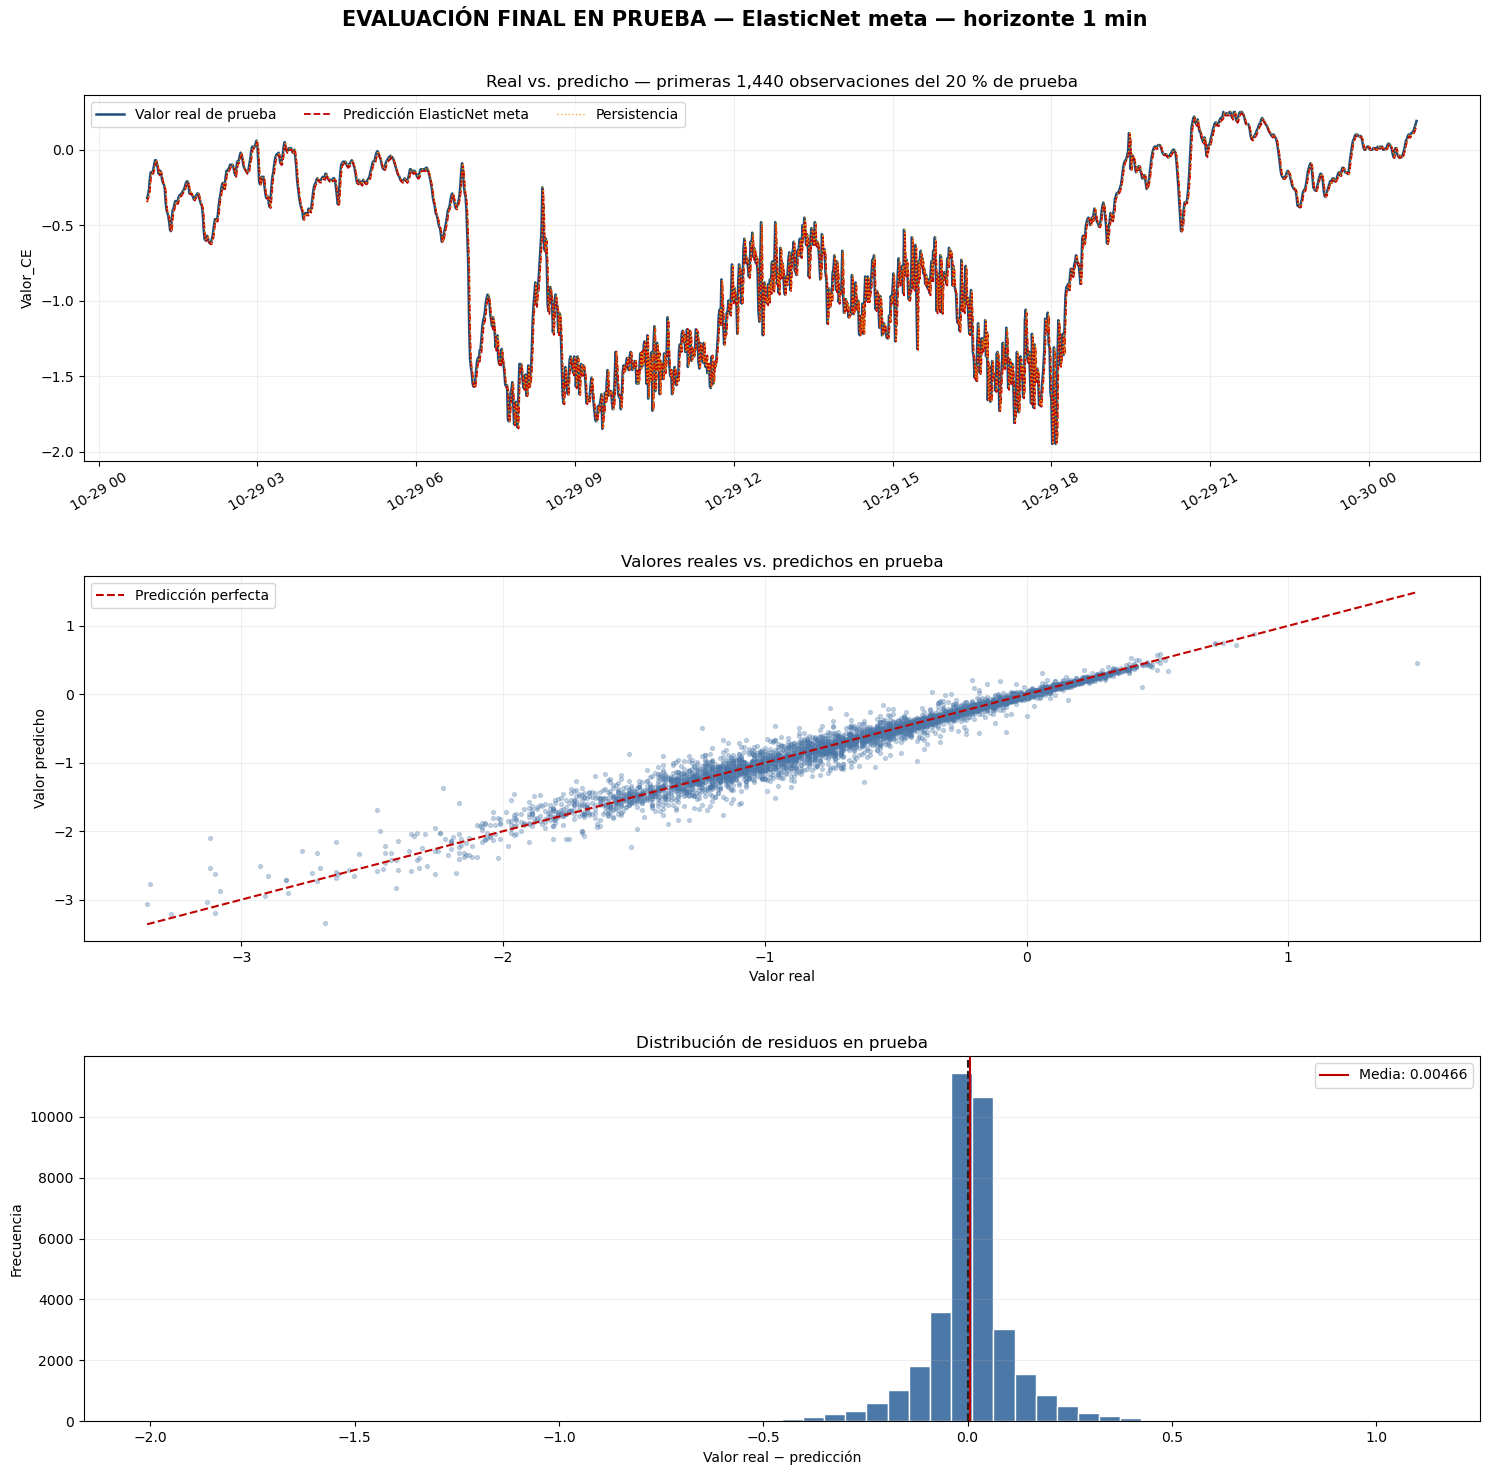

Periodo de prueba: 2025-10-29 00:55:00 → 2025-11-30 12:52:00
Registros de prueba representados en las métricas: 36,611


In [46]:
# ============================
# Gráficas definitivas — datos de prueba
# ============================
residuos_finales = np.asarray(y_test) - np.asarray(prediccion_modelo_final)
cantidad_serie_final = min(1440, len(y_test))
muestra_dispersion = np.linspace(0, len(y_test) - 1, min(5000, len(y_test)), dtype=int)

fig, axes = plt.subplots(3, 1, figsize=(15, 15))
fig.suptitle(
    f"EVALUACIÓN FINAL EN PRUEBA — {nombre_modelo_final} — horizonte {HORIZONTE} min",
    fontsize=15, fontweight="bold",
)

axes[0].plot(fechas_test.iloc[:cantidad_serie_final], np.asarray(y_test)[:cantidad_serie_final],
             label="Valor real de prueba", color="#1F4E79", linewidth=1.8)
axes[0].plot(fechas_test.iloc[:cantidad_serie_final],
             np.asarray(prediccion_modelo_final)[:cantidad_serie_final],
             label=f"Predicción {nombre_modelo_final}", color="#C00000",
             linewidth=1.3, linestyle="--")
axes[0].plot(fechas_test.iloc[:cantidad_serie_final],
             prediccion_test_persistencia[:cantidad_serie_final],
             label="Persistencia", color="#F39C12", linewidth=1.0,
             linestyle=":", alpha=0.85)
axes[0].set_title(f"Real vs. predicho — primeras {cantidad_serie_final:,} observaciones del 20 % de prueba")
axes[0].set_ylabel("Valor_CE")
axes[0].legend(ncol=3)
axes[0].grid(alpha=0.20)
axes[0].tick_params(axis="x", rotation=30)

real_muestra = np.asarray(y_test)[muestra_dispersion]
pred_muestra = np.asarray(prediccion_modelo_final)[muestra_dispersion]
axes[1].scatter(real_muestra, pred_muestra, s=8, alpha=0.30, color="#4C78A8")
limites = [min(real_muestra.min(), pred_muestra.min()),
           max(real_muestra.max(), pred_muestra.max())]
axes[1].plot(limites, limites, color="#C00000", linestyle="--",
             label="Predicción perfecta")
axes[1].set_title("Valores reales vs. predichos en prueba")
axes[1].set_xlabel("Valor real")
axes[1].set_ylabel("Valor predicho")
axes[1].legend()
axes[1].grid(alpha=0.20)

axes[2].hist(residuos_finales, bins=60, color="#4C78A8", edgecolor="white")
axes[2].axvline(0, color="#222222", linestyle="--")
axes[2].axvline(residuos_finales.mean(), color="#C00000",
                label=f"Media: {residuos_finales.mean():.5f}")
axes[2].set_title("Distribución de residuos en prueba")
axes[2].set_xlabel("Valor real − predicción")
axes[2].set_ylabel("Frecuencia")
axes[2].legend()
axes[2].grid(axis="y", alpha=0.20)

plt.tight_layout(rect=[0, 0, 1, 0.97], h_pad=3.0)
plt.show()
print(f"Periodo de prueba: {fechas_test.min()} → {fechas_test.max()}")
print(f"Registros de prueba representados en las métricas: {len(y_test):,}")

### 8.1 Interpretabilidad, estabilidad y riesgos

La evaluación global se complementa con errores por mes, régimen diurno/nocturno, presencia de lluvia y niveles extremos de `Valor_CE`. Esto permite detectar periodos donde el promedio global oculta un desempeño deficiente.

Para interpretar las nueve entradas originales se aplica la permutación **al sistema ganador completo**, no solamente al ElasticNet final. El procedimiento conserva congelados los modelos base y el metamodelo, altera una variable original por vez y vuelve a ejecutar toda la cadena de predicción. Así se obtiene una medida comparable para `Valor_CE`, `Valor_CM` y las siete variables ambientales aunque el ensamble no tenga coeficientes lineales directos para ellas.


In [47]:
# ============================
# Desempeño por periodos y regímenes
# ============================
df_evaluacion_test = pd.DataFrame({
    "FechaHora": fechas_test.to_numpy(),
    "Valor_real": np.asarray(y_test),
    "Valor_predicho": np.asarray(prediccion_modelo_final),
})
df_evaluacion_test["Error"] = (
    df_evaluacion_test["Valor_real"] - df_evaluacion_test["Valor_predicho"]
)
df_evaluacion_test["Mes"] = df_evaluacion_test["FechaHora"].dt.to_period("M").astype(str)
df_evaluacion_test["Régimen"] = np.where(
    X_test["SolarRad."].to_numpy() > 0, "Diurno", "Nocturno"
)
df_evaluacion_test["Lluvia"] = np.where(
    X_test["Rain"].to_numpy() > 0, "Con lluvia", "Sin lluvia"
)
q10, q90 = y_test.quantile([0.10, 0.90])
df_evaluacion_test["Nivel_CE"] = np.select(
    [df_evaluacion_test["Valor_real"] <= q10,
     df_evaluacion_test["Valor_real"] >= q90],
    ["Extremo inferior", "Extremo superior"], default="Rango central",
)

def metricas_por_grupo(df, columna_grupo):
    filas = []
    for grupo, datos in df.groupby(columna_grupo, observed=True):
        metricas = evaluar_predicciones(datos["Valor_real"], datos["Valor_predicho"])
        filas.append({columna_grupo: grupo, "Registros": len(datos), **metricas})
    return pd.DataFrame(filas)

for columna in ["Mes", "Régimen", "Lluvia", "Nivel_CE"]:
    print(f"Desempeño por {columna}:")
    display(metricas_por_grupo(df_evaluacion_test, columna).round(5))

print(f"Sesgo medio del error: {df_evaluacion_test['Error'].mean():.5f}")
print(f"Autocorrelación residual de un minuto: {df_evaluacion_test['Error'].autocorr(1):.5f}")
print("Los grupos con muy pocos registros —especialmente lluvia— no permiten conclusiones robustas.")

Desempeño por Mes:


,Mes,Registros,MAE,RMSE,R2
0,2025-10,4265,0.06588,0.10182,0.96950
1,2025-11,32346,0.06970,0.11296,0.96658


Desempeño por Régimen:


,Régimen,Registros,MAE,RMSE,R2
0,Diurno,19214,0.10004,0.14128,0.94260
1,Nocturno,17397,0.03526,0.06496,0.97245


Desempeño por Lluvia:


,Lluvia,Registros,MAE,RMSE,R2
0,Sin lluvia,36611,0.06926,0.11172,0.96702


Desempeño por Nivel_CE:


,Nivel_CE,Registros,MAE,RMSE,R2
0,Extremo inferior,3679,0.14508,0.20056,0.69490
1,Extremo superior,3869,0.02491,0.04557,0.83883
2,Rango central,29063,0.06556,0.10176,0.94383


Sesgo medio del error: 0.00466
Autocorrelación residual de un minuto: -0.08176
Los grupos con muy pocos registros —especialmente lluvia— no permiten conclusiones robustas.


,Variable,Efecto_medio_al_aumentar_1_DE,Direccion_efecto,Importancia_permutacion_RMSE,Desv_importancia,Importancia_relativa_pct,Aporta_con_evidencia
0,Valor_CE,0.577685,Aumenta,0.720041,0.012580,99.650834,Sí
1,WindSpeed,-0.012993,Disminuye,0.001545,0.000380,0.213831,Sí
2,TempOut,0.005226,Aumenta,0.000569,0.000150,0.078693,Sí
3,OutHum,-0.000237,Disminuye,0.000136,0.000085,0.018883,No concluyente
4,Valor_CM,-0.002645,Disminuye,0.000135,0.000157,0.018718,No concluyente
5,UVIndex,-0.003500,Disminuye,0.000092,0.000070,0.012789,No concluyente
6,SolarRad.,0.001773,Aumenta,0.000045,0.000094,0.006252,No concluyente
7,Rain,0.000000,Sin cambio,0.000000,0.000000,0.000000,No concluyente
8,Bar,0.000511,Aumenta,-0.000007,0.000044,0.000000,No concluyente


La importancia atraviesa todo el sistema ganador; describe asociación predictiva, no causalidad.


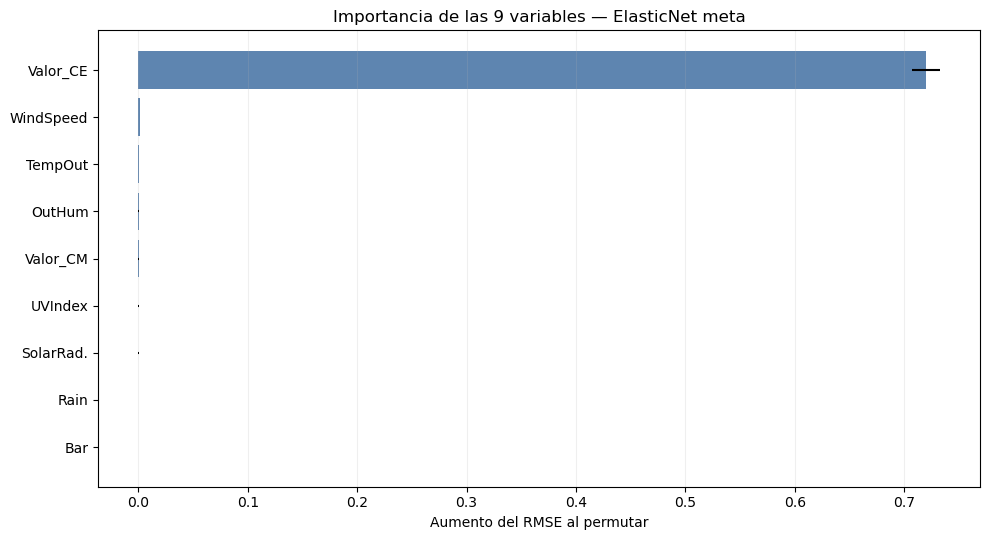

In [48]:
# ============================
# Importancia de las 9 variables a través del sistema ganador
# ============================
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.inspection import permutation_importance

class SistemaFinal9Vars(RegressorMixin, BaseEstimator):
    def __init__(self, seleccion, modelos_base, metamodelo, columnas_meta, mapeo):
        self.seleccion = seleccion
        self.modelos_base = modelos_base
        self.metamodelo = metamodelo
        self.columnas_meta = columnas_meta
        self.mapeo = mapeo

    def fit(self, X_entrada, y=None):
        """Compatibilidad con scikit-learn; no reentrena el sistema congelado."""
        self.n_features_in_ = X_entrada.shape[1]
        return self

    def predict(self, X_entrada):
        if self.seleccion["Tipo"] == "Metamodelo":
            valores = {
                columna: self.modelos_base[nombre].predict(X_entrada)
                for columna, nombre in self.mapeo.items()
            }
            X_meta_local = pd.DataFrame(valores, index=X_entrada.index)[self.columnas_meta]
            return self.metamodelo.predict(X_meta_local)
        return self.modelos_base[self.seleccion["Nombre"]].predict(X_entrada)

sistema_final_prueba_9 = SistemaFinal9Vars(
    seleccion_preprueba, modelos_base_entrenados,
    metamodelos_optimizados.get(nombre_modelo_final),
    list(columnas_meta), dict(mapeo_columnas_meta),
)

rng = np.random.default_rng(42)
indices_importancia = np.sort(
    rng.choice(len(y_test), size=min(1000, len(y_test)), replace=False)
)
X_interpretar = X_test.iloc[indices_importancia].copy()
y_interpretar = y_test.iloc[indices_importancia]
prediccion_referencia = sistema_final_prueba_9.predict(X_interpretar)

efectos = []
for variable in X_interpretar.columns:
    desviacion = float(X_interpretar[variable].std())
    if not np.isfinite(desviacion) or desviacion == 0:
        efectos.append(0.0)
        continue
    X_perturbado = X_interpretar.copy()
    X_perturbado[variable] += desviacion
    efectos.append(float(np.mean(
        sistema_final_prueba_9.predict(X_perturbado) - prediccion_referencia
    )))

resultado_permutacion = permutation_importance(
    sistema_final_prueba_9, X_interpretar, y_interpretar,
    scoring="neg_root_mean_squared_error", n_repeats=5,
    random_state=42, n_jobs=1,
)
positivas = np.clip(resultado_permutacion.importances_mean, 0, None)
total = positivas.sum()
porcentaje = 100 * positivas / total if total > 0 else np.zeros(len(positivas))
limite_inferior = resultado_permutacion.importances_mean - 2 * resultado_permutacion.importances_std

df_importancia_final = pd.DataFrame({
    "Variable": X_interpretar.columns,
    "Efecto_medio_al_aumentar_1_DE": efectos,
    "Direccion_efecto": np.where(np.asarray(efectos) > 0, "Aumenta",
                          np.where(np.asarray(efectos) < 0, "Disminuye", "Sin cambio")),
    "Importancia_permutacion_RMSE": resultado_permutacion.importances_mean,
    "Desv_importancia": resultado_permutacion.importances_std,
    "Importancia_relativa_pct": porcentaje,
    "Aporta_con_evidencia": np.where(limite_inferior > 0, "Sí", "No concluyente"),
}).sort_values("Importancia_permutacion_RMSE", ascending=False).reset_index(drop=True)

display(df_importancia_final.round(6))
print("La importancia atraviesa todo el sistema ganador; describe asociación predictiva, no causalidad.")

top = df_importancia_final.sort_values("Importancia_permutacion_RMSE")
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(top["Variable"], top["Importancia_permutacion_RMSE"],
        xerr=top["Desv_importancia"], color="#4C78A8", alpha=0.90)
ax.set_title(f"Importancia de las 9 variables — {nombre_modelo_final}")
ax.set_xlabel("Aumento del RMSE al permutar")
ax.grid(axis="x", alpha=0.20)
plt.tight_layout()
plt.show()


### 8.2 Interpretación SHAP del sistema ganador

SHAP (*SHapley Additive exPlanations*) se calcula sobre las **nueve variables originales y el sistema ganador completo**. La función explicada ejecuta los modelos base y después `ElasticNet meta`; por tanto, los valores SHAP no corresponden únicamente a los pesos internos del metamodelo.

Para cada observación, SHAP descompone la predicción como:

$$
f(x)=E[f(X)]+\sum_{j=1}^{9}\phi_j(x)
$$

- $E[f(X)]$ es la predicción base promedio.
- $\phi_j(x)$ es el aporte de la variable $j$ en esa observación.
- Un valor SHAP positivo empuja `Valor_CE_t+1` hacia arriba y uno negativo lo empuja hacia abajo.
- En el gráfico *beeswarm*, cada punto es una observación; rojo indica un valor alto de la variable y azul un valor bajo.
- Las variables se ordenan por $promedio(|SHAP|)$, que resume la magnitud global de su influencia.

La tabla asociada ordena las variables según `Importancia_SHAP_media_abs`, calcula su participación relativa y contrasta el resultado con la importancia por permutación. `Tendencia_SHAP` resume la correlación de Spearman entre el valor de la variable y su aporte SHAP: no debe confundirse con un coeficiente lineal ni interpretarse como causalidad.

Para limitar el costo computacional se utilizan hasta 50 observaciones de referencia y hasta 200 observaciones de prueba, seleccionadas de forma reproducible. Si `shap` no está instalado, ejecute `%pip install shap` y reinicie el kernel antes de continuar.


In [59]:
%pip install "numpy==1.26.4" shap

INFO: pip is looking at multiple versions of shap to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 29.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 14.8 MB/s  0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.6
    Uninstalling numpy-2.4.6:
      Successfully uninstalled numpy-2.4.6
  Attempting uninstall: shap━━━━━━━━━━━━━━━━━━━━ 0/2 [numpy]
    Found existing installation: shap 0.51.0 0/2 [numpy]
    Uninstalling shap-0.51.0:━━━━━━━━━━━━━━━ 0/2 [numpy]
      Successfully uninstalled shap-0.51.0━━━━━━━━━━━━━━━━━━━ 1/2 [shap]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [shap]1/2 [shap]
Note: you may need to restart the kernel to use updated packages.


In [60]:
import numpy
import shap
import pyarrow

print("NumPy:", numpy.__version__)
print("SHAP:", shap.__version__)
print("PyArrow:", pyarrow.__version__)

NumPy: 1.26.4
SHAP: 0.51.0
PyArrow: 14.0.2


/opt/conda/lib/python3.11/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


,Ranking_SHAP,Variable,Importancia_SHAP_media_abs,Importancia_SHAP_relativa_pct,Correlacion_valor_SHAP,Tendencia_SHAP,Nivel_influencia,Importancia_permutacion_RMSE,Aporta_con_evidencia
0,1,Valor_CE,0.662396,95.817690,0.999935,Valores altos tienden a aumentar la predicción,Mayor,0.720041,Sí
1,2,WindSpeed,0.009774,1.413834,-0.935919,Valores altos tienden a disminuir la predicción,Mayor,0.001545,Sí
2,3,TempOut,0.007099,1.026842,0.946609,Valores altos tienden a aumentar la predicción,Mayor,0.000569,Sí
3,4,OutHum,0.005184,0.749875,-0.750482,Valores altos tienden a disminuir la predicción,Intermedia,0.000136,No concluyente
4,5,Valor_CM,0.002537,0.367054,-0.890305,Valores altos tienden a disminuir la predicción,Intermedia,0.000135,No concluyente
5,6,UVIndex,0.002215,0.320405,-0.429655,Valores altos tienden a disminuir la predicción,Intermedia,0.000092,No concluyente
6,7,SolarRad.,0.001066,0.154139,-0.386146,Valores altos tienden a disminuir la predicción,Menor,0.000045,No concluyente
7,8,Bar,0.001038,0.150162,-0.187525,Valores altos tienden a disminuir la predicción,Menor,-0.000007,No concluyente
8,9,Rain,0.000000,0.000000,0.000000,Relación no monótona o débil,Menor,0.000000,No concluyente


Variables con mayor influencia SHAP: Valor_CE, WindSpeed, TempOut
SHAP explica asociación predictiva del ganador completo; no demuestra causalidad.


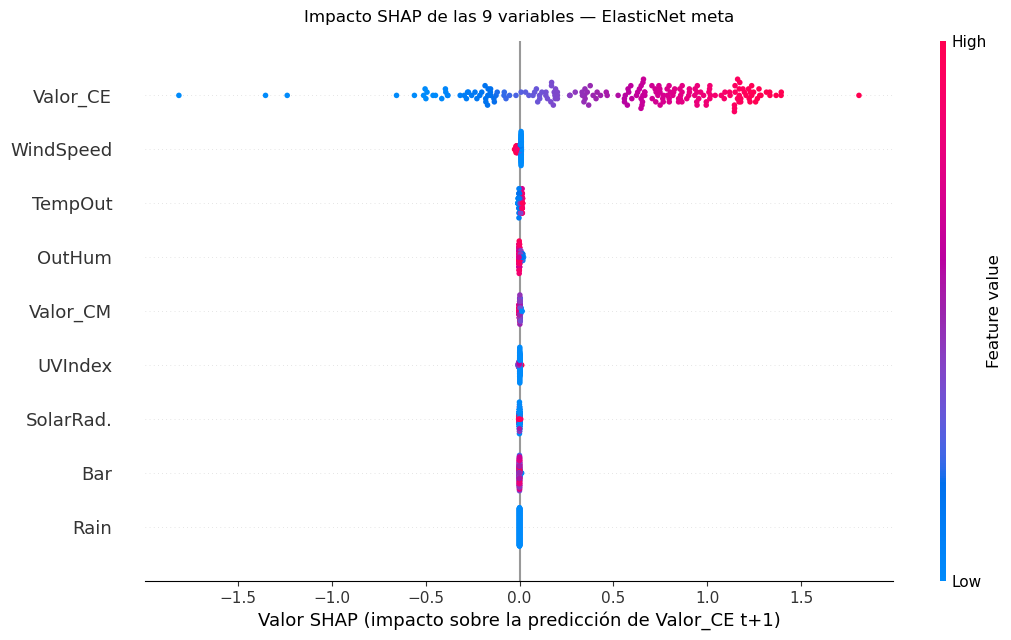

In [61]:
# ============================
# SHAP model-agnóstico sobre las 9 variables y el ganador completo
# ============================
from io import BytesIO

try:
    import shap
except ModuleNotFoundError as error:
    raise ModuleNotFoundError(
        "Falta el paquete 'shap'. Ejecute %pip install shap, reinicie el kernel "
        "y vuelva a ejecutar esta sección."
    ) from error

SEMILLA_SHAP = 42
MAX_FONDO_SHAP = 50
MAX_OBSERVACIONES_SHAP = 200
columnas_shap = list(X_test.columns)
rng_shap = np.random.default_rng(SEMILLA_SHAP)

indices_fondo_shap = np.sort(rng_shap.choice(
    len(X_train), size=min(MAX_FONDO_SHAP, len(X_train)), replace=False
))
indices_muestra_shap = np.sort(rng_shap.choice(
    len(X_test), size=min(MAX_OBSERVACIONES_SHAP, len(X_test)), replace=False
))
X_fondo_shap = X_train.iloc[indices_fondo_shap][columnas_shap].copy()
X_muestra_shap = X_test.iloc[indices_muestra_shap][columnas_shap].copy()

def predecir_sistema_completo_shap(datos):
    X_local = pd.DataFrame(np.asarray(datos), columns=columnas_shap)
    return np.asarray(sistema_final_prueba_9.predict(X_local), dtype=float)

masker_shap = shap.maskers.Independent(
    X_fondo_shap, max_samples=min(MAX_FONDO_SHAP, len(X_fondo_shap))
)
explicador_shap = shap.PermutationExplainer(
    predecir_sistema_completo_shap,
    masker_shap,
    feature_names=columnas_shap,
)
argumentos_shap = {
    "max_evals": 2 * len(columnas_shap) + 1,
    "batch_size": 32,
}
try:
    explicacion_shap_final = explicador_shap(
        X_muestra_shap, silent=True, **argumentos_shap
    )
except TypeError:
    explicacion_shap_final = explicador_shap(X_muestra_shap, **argumentos_shap)

valores_shap = np.asarray(explicacion_shap_final.values, dtype=float)
if valores_shap.ndim == 3 and valores_shap.shape[-1] == 1:
    valores_shap = valores_shap[..., 0]
if valores_shap.shape != X_muestra_shap.shape:
    raise ValueError(
        f"Dimensión SHAP inesperada: {valores_shap.shape}; "
        f"se esperaba {X_muestra_shap.shape}."
    )

importancia_shap_abs = np.mean(np.abs(valores_shap), axis=0)
total_shap = float(importancia_shap_abs.sum())
importancia_shap_pct = (
    100 * importancia_shap_abs / total_shap
    if total_shap > 0 else np.zeros_like(importancia_shap_abs)
)

correlaciones_shap = []
tendencias_shap = []
for posicion_variable, variable in enumerate(columnas_shap):
    correlacion = pd.Series(X_muestra_shap[variable].to_numpy()).corr(
        pd.Series(valores_shap[:, posicion_variable]), method="spearman"
    )
    correlacion = float(correlacion) if np.isfinite(correlacion) else 0.0
    correlaciones_shap.append(correlacion)
    if abs(correlacion) < 0.10:
        tendencias_shap.append("Relación no monótona o débil")
    elif correlacion > 0:
        tendencias_shap.append("Valores altos tienden a aumentar la predicción")
    else:
        tendencias_shap.append("Valores altos tienden a disminuir la predicción")

df_importancia_shap_final = pd.DataFrame({
    "Variable": columnas_shap,
    "Importancia_SHAP_media_abs": importancia_shap_abs,
    "Importancia_SHAP_relativa_pct": importancia_shap_pct,
    "Correlacion_valor_SHAP": correlaciones_shap,
    "Tendencia_SHAP": tendencias_shap,
}).sort_values(
    "Importancia_SHAP_media_abs", ascending=False
).reset_index(drop=True)
df_importancia_shap_final.insert(
    0, "Ranking_SHAP", np.arange(1, len(df_importancia_shap_final) + 1)
)
df_importancia_shap_final["Nivel_influencia"] = np.select(
    [
        df_importancia_shap_final["Ranking_SHAP"] <= 3,
        df_importancia_shap_final["Ranking_SHAP"] <= 6,
    ],
    ["Mayor", "Intermedia"],
    default="Menor",
)
df_importancia_shap_final = df_importancia_shap_final.merge(
    df_importancia_final[[
        "Variable", "Importancia_permutacion_RMSE", "Aporta_con_evidencia"
    ]],
    on="Variable", how="left",
)

df_valores_shap_final = pd.DataFrame({
    "FechaHora": fechas_test.iloc[indices_muestra_shap].to_numpy(),
})
for posicion_variable, variable in enumerate(columnas_shap):
    df_valores_shap_final[f"Valor__{variable}"] = X_muestra_shap[variable].to_numpy()
    df_valores_shap_final[f"SHAP__{variable}"] = valores_shap[:, posicion_variable]

display(df_importancia_shap_final.round(6))
principales_shap = ", ".join(df_importancia_shap_final.head(3)["Variable"])
print(f"Variables con mayor influencia SHAP: {principales_shap}")
print("SHAP explica asociación predictiva del ganador completo; no demuestra causalidad.")

shap.plots.beeswarm(
    explicacion_shap_final,
    max_display=len(columnas_shap),
    show=False,
    plot_size=(11, 6.5),
)
figura_shap = plt.gcf()
eje_shap = plt.gca()
eje_shap.set_title(
    f"Impacto SHAP de las 9 variables — {nombre_modelo_final}", pad=14
)
eje_shap.set_xlabel("Valor SHAP (impacto sobre la predicción de Valor_CE t+1)")
figura_shap.tight_layout()
buffer_shap = BytesIO()
figura_shap.savefig(buffer_shap, format="png", dpi=300, bbox_inches="tight")
grafico_shap_png = buffer_shap.getvalue()
plt.show()
plt.close(figura_shap)


### 8.3 Decisión, riesgos y selección final

El cierre compara validación y prueba para detectar sobreajuste o cambio temporal. También verifica si el modelo final mejora la persistencia. Una mejora negativa indica que la complejidad adicional no se justifica para ese criterio.

Riesgos que deben conservarse en el informe: periodo disponible limitado a 2025, intervalos sin medición, solo 20 eventos de lluvia en el conjunto integrado, ausencia total de `WindDir`, posible cambio estacional y dependencia de que las variables predictoras estén disponibles en tiempo real.

In [62]:
# ============================
# Decisión final y control de generalización
# ============================
rmse_cv_seleccion = seleccion_preprueba["RMSE_CV"]
brecha_prueba_cv = metricas_modelo_final["RMSE"] - rmse_cv_seleccion
brecha_prueba_cv_pct = 100 * brecha_prueba_cv / rmse_cv_seleccion

if mejora_mae_pct > 0 and mejora_rmse_pct > 0:
    decision_tecnica = "Cumple: mejora MAE y RMSE frente a persistencia"
elif mejora_mae_pct > 0 or mejora_rmse_pct > 0:
    decision_tecnica = "Cumplimiento parcial: mejora solo una métrica principal"
else:
    decision_tecnica = "No supera persistencia: se recomienda iterar"

resumen_decision_final = pd.DataFrame([{
    "Horizonte_min": HORIZONTE,
    "Tipo_seleccionado": seleccion_preprueba["Tipo"],
    "Modelo_final": nombre_modelo_final,
    "RMSE_CV": rmse_cv_seleccion,
    "MAE_prueba": metricas_modelo_final["MAE"],
    "RMSE_prueba": metricas_modelo_final["RMSE"],
    "R2_prueba": metricas_modelo_final["R2"],
    "Brecha_RMSE_prueba_CV": brecha_prueba_cv,
    "Brecha_RMSE_prueba_CV_pct": brecha_prueba_cv_pct,
    "Mejora_MAE_vs_persistencia_pct": mejora_mae_pct,
    "Mejora_RMSE_vs_persistencia_pct": mejora_rmse_pct,
    "Decisión_técnica": decision_tecnica,
}])
display(resumen_decision_final.round(5))

print(f"Decisión: {decision_tecnica}")
if abs(brecha_prueba_cv_pct) > 20:
    print("Advertencia: existe una brecha superior al 20 % entre CV y prueba.")
else:
    print("La brecha entre validación y prueba no supera el umbral diagnóstico del 20 %.")

,Horizonte_min,Tipo_seleccionado,Modelo_final,RMSE_CV,MAE_prueba,RMSE_prueba,R2_prueba,Brecha_RMSE_prueba_CV,Brecha_RMSE_prueba_CV_pct,Mejora_MAE_vs_persistencia_pct,Mejora_RMSE_vs_persistencia_pct,Decisión_técnica
0,1,Metamodelo,ElasticNet meta,0.18311,0.06926,0.11172,0.96702,-0.07139,-38.98835,-0.48785,0.9736,Cumplimiento parcial: mejora solo una métrica ...


Decisión: Cumplimiento parcial: mejora solo una métrica principal
Advertencia: existe una brecha superior al 20 % entre CV y prueba.


### 8.4 Interpretabilidad válida del modelo ganador

El modelo seleccionado es **ElasticNet meta**. Este metamodelo sí posee coeficientes, pero sus entradas son las predicciones de GAM, Ridge, CatBoost, MLP y Random Forest; por tanto, esos pesos **no son coeficientes directos de las nueve variables físicas**. Como el sistema completo contiene modelos no lineales, no existe una ecuación única del tipo $\hat y=\beta_0+\sum_j\beta_jx_j$ que asigne un $\beta_j$ directo a `Valor_CE`, `Valor_CM`, `TempOut`, etc.


#### Puente con la regresión estadística clásica

En una regresión lineal múltiple, la relación se expresa como:

$$
\widehat{Valor\_CE}_{t+1}=\beta_0+\beta_1X_1+\beta_2X_2+\cdots+\beta_9X_9
$$

Cada $\beta_j$ es una pendiente global y constante: manteniendo las demás variables fijas, aumentar $X_j$ una unidad cambia la predicción en $\beta_j$ unidades, cualquiera sea el registro evaluado. Esta interpretación es válida porque el modelo es lineal en las variables originales.

El sistema ganador tiene otra estructura:

$$
\widehat{Valor\_CE}_{t+1}=\alpha_0
+\alpha_1 f_{GAM}(X)
+\alpha_2 f_{Ridge}(X)
+\alpha_3 f_{CatBoost}(X)
+\alpha_4 f_{MLP}(X)
+\alpha_5 f_{RF}(X)
$$

Aquí $X$ representa las nueve variables originales. Los $\alpha_m$ son coeficientes de ElasticNet meta, pero ponderan **predicciones completas de modelos base**, no variables físicas individuales. Como CatBoost, MLP y Random Forest contienen relaciones no lineales e interacciones, en general no es posible desarrollar esta expresión y convertirla en nueve términos $\beta_jX_j$ con pendientes constantes.

Por tanto, la ausencia de un coeficiente global para una variable no significa que esa variable no tenga efecto. Significa que su efecto puede depender del valor de la propia variable, de las demás entradas y de las interacciones aprendidas. En términos estadísticos, la pendiente local puede variar entre observaciones.

La magnitud `Efecto_medio_al_aumentar_1_DE` es la medida más cercana conceptualmente a una pendiente estandarizada, pero debe denominarse **efecto medio** y no coeficiente: resume múltiples cambios locales de un modelo no lineal. La `Importancia_permutacion_RMSE` responde una pregunta diferente y complementaria: cuánto pierde el sistema ganador cuando deja de disponer de la información de una variable.

> **Texto sugerido para la sustentación:** Los modelos lineales asignan una pendiente constante a cada variable. El sistema ganador no es lineal respecto de las nueve variables originales, por lo que no existe un único coeficiente global por predictor. Para conservar una interpretación estadística comparable, se calculó la importancia por permutación como medida de dependencia predictiva y el efecto medio ante un incremento de una desviación estándar como medida de magnitud y dirección. Ambas medidas se obtuvieron atravesando el sistema ganador completo, sin reemplazarlo por un modelo distinto.

Si se exigiera una ecuación con nueve coeficientes constantes, sería necesario seleccionar deliberadamente un modelo lineal —por ejemplo MLR o Ridge— como modelo final y aceptar su desempeño predictivo. Los coeficientes de un modelo lineal auxiliar pueden documentarse como análisis complementario, pero no deben atribuirse a ElasticNet meta.

#### ¿Cómo se cuantifica entonces el peso de cada variable?

Se utilizan dos medidas complementarias calculadas sobre una muestra reproducible de hasta 1 000 registros del conjunto de prueba y atravesando el sistema ganador completo:

1. **Importancia por permutación en RMSE.** Primero se calcula el RMSE de referencia sin alterar los datos. Después, para cada variable $j$, se desordenan aleatoriamente sus valores entre los registros, manteniendo iguales las otras ocho variables, y se vuelve a predecir con todo el ensamble. Esto rompe la información aportada por esa variable sin reentrenar el modelo. El proceso se repite cinco veces:

   $$I_j=\operatorname{promedio}_{r=1,\ldots,5}\left(RMSE_{j,r}^{permutado}-RMSE^{referencia}\right)$$

   Un $I_j$ grande significa que al destruir la información de la variable el error aumenta mucho; por tanto, el ganador depende más de ella. Este valor aparece en `Importancia_permutacion_RMSE` y **no es un coeficiente multiplicador**.

2. **Efecto medio al aumentar una desviación estándar.** Para aportar dirección, se aumenta la variable $j$ en una desviación estándar, se mantienen las demás sin cambio y se compara la nueva predicción con la original:

   $$E_j=\operatorname{promedio}\left[f(X\;con\;x_j+DE_j)-f(X)\right]$$

   `Efecto_medio_al_aumentar_1_DE` expresa el cambio medio estimado en `Valor_CE_t+1`; su signo alimenta `Direccion_efecto`. Es una perturbación del sistema y no equivale a un coeficiente constante: el efecto puede variar según el registro porque el ensamble es no lineal.

#### Lectura de las demás columnas

- `Desv_importancia`: variabilidad de la importancia entre las cinco permutaciones.
- `Importancia_relativa_pct`: participación normalizada usando solo importancias positivas, $100\max(I_j,0)/\sum_k\max(I_k,0)$. Sirve para comparar variables, pero no implica que sus efectos sean aditivos.
- `Aporta_con_evidencia = Sí`: criterio conservador $I_j-2\,Desv_j>0$. `No concluyente` no prueba que la variable sea inútil.
- Una importancia igual a cero o negativa significa que en esa muestra no se detectó una pérdida estable al permutarla; **no significa un efecto físico negativo**.

Estas medidas describen asociación predictiva, no causalidad. Si dos variables están muy correlacionadas, una puede sustituir parcialmente a la otra y su importancia individual puede parecer pequeña. Además, aumentar una variable dejando todas las demás constantes puede crear combinaciones poco frecuentes; por ello el efecto medio debe interpretarse como diagnóstico del modelo y no como una intervención física real.

La tabla MLR de referencia se retira del resultado final y del deploy porque MLR no ganó. Los `NaN` que aparecían allí no eran datos faltantes de ElasticNet meta: correspondían principalmente a la fila `INTERCEPTO`, para la cual no aplicaban columnas como efecto por desviación estándar, dirección o importancia; Pandas completaba esas celdas con `NaN`.


In [63]:
# ============================
# Control de coherencia de la interpretabilidad publicada
# ============================
columnas_interpretabilidad_ganador = [
    "Variable",
    "Efecto_medio_al_aumentar_1_DE",
    "Direccion_efecto",
    "Importancia_permutacion_RMSE",
    "Desv_importancia",
    "Importancia_relativa_pct",
    "Aporta_con_evidencia",
]

faltantes_interpretabilidad = [
    columna for columna in columnas_interpretabilidad_ganador
    if columna not in df_importancia_final.columns
]
if faltantes_interpretabilidad:
    raise ValueError(
        f"Faltan columnas de interpretabilidad del ganador: {faltantes_interpretabilidad}"
    )

df_interpretabilidad_ganador = df_importancia_final[
    columnas_interpretabilidad_ganador
].copy()
if df_interpretabilidad_ganador.isna().any().any():
    columnas_con_nulos = df_interpretabilidad_ganador.columns[
        df_interpretabilidad_ganador.isna().any()
    ].tolist()
    raise ValueError(
        "La interpretabilidad del ganador contiene nulos en: "
        f"{columnas_con_nulos}"
    )

print(f"Modelo ganador: {nombre_modelo_final}")
print("Interpretabilidad publicada: importancia de las 9 variables a través del sistema completo.")
print("No se publican coeficientes directos porque el ganador no los genera por variable original.")
display(df_interpretabilidad_ganador.round(6))


Modelo ganador: ElasticNet meta
Interpretabilidad publicada: importancia de las 9 variables a través del sistema completo.
No se publican coeficientes directos porque el ganador no los genera por variable original.


,Variable,Efecto_medio_al_aumentar_1_DE,Direccion_efecto,Importancia_permutacion_RMSE,Desv_importancia,Importancia_relativa_pct,Aporta_con_evidencia
0,Valor_CE,0.577685,Aumenta,0.720041,0.012580,99.650834,Sí
1,WindSpeed,-0.012993,Disminuye,0.001545,0.000380,0.213831,Sí
2,TempOut,0.005226,Aumenta,0.000569,0.000150,0.078693,Sí
3,OutHum,-0.000237,Disminuye,0.000136,0.000085,0.018883,No concluyente
4,Valor_CM,-0.002645,Disminuye,0.000135,0.000157,0.018718,No concluyente
5,UVIndex,-0.003500,Disminuye,0.000092,0.000070,0.012789,No concluyente
6,SolarRad.,0.001773,Aumenta,0.000045,0.000094,0.006252,No concluyente
7,Rain,0.000000,Sin cambio,0.000000,0.000000,0.000000,No concluyente
8,Bar,0.000511,Aumenta,-0.000007,0.000044,0.000000,No concluyente


### 8.5 Exportación reproducible

La ruta de resultados se configura recién en esta fase. Se guardan métricas, predicciones, importancia por permutación y resultados SHAP del sistema ganador, configuración y objetos entrenados. No se exportan coeficientes MLR ni pesos internos del metamodelo como si fueran efectos de las variables originales. Los archivos de entrada no se modifican.


In [64]:
# ============================
# Exportar resultados y modelos del horizonte activo
# ============================
import json
import joblib

DIRECTORIO_RESULTADOS = Path("Resultados_modelamiento_9_variables") / f"horizonte_{HORIZONTE}min"
DIRECTORIO_RESULTADOS.mkdir(parents=True, exist_ok=True)

df_predicciones_exportar = df_evaluacion_test.copy()
df_predicciones_exportar["Predicción_persistencia"] = prediccion_test_persistencia
for columna_meta, nombre in mapeo_columnas_meta.items():
    df_predicciones_exportar[f"Predicción_base__{nombre}"] = X_meta_test[columna_meta].to_numpy()
for nombre, prediccion in predicciones_test_meta.items():
    df_predicciones_exportar[f"Predicción_meta__{nombre}"] = prediccion

archivos_exportados = {
    "metricas_prueba.csv": metricas_prueba_final,
    "predicciones_prueba.csv": df_predicciones_exportar,
    "predicciones_oof_stacking.csv": df_oof_meta,
    "comparacion_modelos_base.csv": comparacion_modelos_base,
    "comparacion_post_optimizacion.csv": comparacion_post_optimizacion,
    "comparacion_metamodelos.csv": comparacion_metamodelos,
    "importancia_permutacion.csv": df_importancia_final,
    "importancia_shap.csv": df_importancia_shap_final,
    "valores_shap.csv": df_valores_shap_final,
    "resumen_decision_final.csv": resumen_decision_final,
}
for nombre_archivo, dataframe in archivos_exportados.items():
    dataframe.to_csv(DIRECTORIO_RESULTADOS / nombre_archivo, index=False)

(DIRECTORIO_RESULTADOS / "grafico_shap_beeswarm.png").write_bytes(grafico_shap_png)

configuracion_exportar = {
    "horizonte_min": HORIZONTE,
    "seleccion_preprueba": seleccion_preprueba,
    "modelos_stacking": modelos_stacking_nombres,
    "mapeo_columnas_meta": mapeo_columnas_meta,
    "modelos_optimizados": {
        nombre: busqueda.best_params_
        for nombre, busqueda in busquedas_optimizacion.items()
    },
    "metamodelos": {
        nombre: busqueda.best_params_
        for nombre, busqueda in busquedas_meta.items()
    },
    "metricas_modelo_final": metricas_modelo_final,
    "mejora_mae_pct": mejora_mae_pct,
    "mejora_rmse_pct": mejora_rmse_pct,
}
with open(DIRECTORIO_RESULTADOS / "configuracion_final.json", "w", encoding="utf-8") as archivo:
    json.dump(configuracion_exportar, archivo, ensure_ascii=False, indent=2, default=str)

joblib.dump({
    "seleccion_preprueba": seleccion_preprueba,
    "metamodelo_final": mejor_metamodelo,
    "modelos_base": modelos_base_entrenados,
    "columnas_predictoras": X_train.columns.tolist(),
    "columnas_meta": columnas_meta,
    "mapeo_columnas_meta": mapeo_columnas_meta,
}, DIRECTORIO_RESULTADOS / "sistema_prediccion.joblib")

resumen_archivos_resultado = []
for ruta in sorted(DIRECTORIO_RESULTADOS.iterdir()):
    if ruta.is_file():
        resumen_archivos_resultado.append({
            "Archivo": ruta.name,
            "Tamaño_MB": round(ruta.stat().st_size / (1024 ** 2), 3),
        })
display(pd.DataFrame(resumen_archivos_resultado))
print(f"Resultados guardados en: {DIRECTORIO_RESULTADOS.resolve()}")

,Archivo,Tamaño_MB
0,coeficientes_mlr_referencia.csv,0.002
1,coeficientes_modelo_ganador.csv,0.001
2,comparacion_metamodelos.csv,0.000
3,comparacion_modelos_base.csv,0.001
4,comparacion_post_optimizacion.csv,0.001
5,configuracion_final.json,0.001
6,grafico_shap_beeswarm.png,0.194
7,importancia_permutacion.csv,0.001
8,importancia_shap.csv,0.001
9,metricas_prueba.csv,0.001


Resultados guardados en: /opt/notebooks/ce/Resultados_modelamiento_9_variables/horizonte_1min


## 🚀 Fase 6 — Deployment

### 9.1 Empaquetado del sistema productivo

El sistema se reajusta después de cerrar la evaluación. El modelo utiliza únicamente la **última medición válida** para predecir, por lo que la entrada operacional mínima es una fila con `FechaHora` y las nueve variables. El CSV puede contener hasta 61 registros recientes: los anteriores no cambian la predicción, pero permiten mostrar el contexto observado en el gráfico de `t+1`.

El paquete incluye modelo, configuración, esquema, ejemplo de 61 mediciones, dependencias, importancia por permutación, tabla SHAP y gráfico SHAP del ganador y manifiesto SHA-256. No incluye coeficientes MLR ni pesos entre modelos base, porque ninguno representa efectos directos de las nueve variables en el sistema ganador.


In [65]:
# ============================
# Reajuste y exportación del sistema productivo de 9 variables
# ============================
from hashlib import sha256
from importlib.metadata import PackageNotFoundError, version
import json
import joblib

DIRECTORIO_ARTEFACTOS_9 = Path("Artefactos_CE_9Vars") / f"horizonte_{HORIZONTE}min"
DIRECTORIO_ARTEFACTOS_9.mkdir(parents=True, exist_ok=True)

nombres_base_produccion = list(modelos_stacking_nombres)
if seleccion_preprueba["Tipo"] == "Modelo base" and seleccion_preprueba["Nombre"] not in nombres_base_produccion:
    nombres_base_produccion.append(seleccion_preprueba["Nombre"])

modelos_base_produccion = {}
for nombre in nombres_base_produccion:
    modelo = clone(modelos_finales_por_nombre[nombre])
    if nombre == "SVR inicial":
        X_ajuste = X.iloc[-MAX_ENTRENAMIENTO_SVR:]
        y_ajuste = y.iloc[-MAX_ENTRENAMIENTO_SVR:]
    else:
        X_ajuste, y_ajuste = X, y
    modelo.fit(X_ajuste, y_ajuste)
    modelos_base_produccion[nombre] = modelo
    print(f"Reajustado: {nombre} — {len(X_ajuste):,} registros")

metamodelo_produccion = None
if seleccion_preprueba["Tipo"] == "Metamodelo":
    metamodelo_produccion = clone(metamodelos_optimizados[seleccion_preprueba["Nombre"]])
    metamodelo_produccion.fit(X_meta, y_meta)

artefacto_9 = {
    "version_esquema": "1.0.0",
    "horizonte_min": HORIZONTE,
    "seleccion": seleccion_preprueba,
    "modelos_base": modelos_base_produccion,
    "metamodelo": metamodelo_produccion,
    "columnas_predictoras": list(columnas_predictoras_modelo),
    "columnas_meta": list(columnas_meta),
    "mapeo_columnas_meta": dict(mapeo_columnas_meta),
    "objetivo": columna_objetivo,
}
ruta_modelo_9 = DIRECTORIO_ARTEFACTOS_9 / "sistema_ce_9vars_1min.joblib"
joblib.dump(artefacto_9, ruta_modelo_9, compress=3)

entrada_ejemplo_9 = (
    df_modelamiento[["FechaHora"] + list(columnas_predictoras_modelo)]
    .tail(61).copy()
)
ruta_ejemplo_9 = DIRECTORIO_ARTEFACTOS_9 / "entrada_ejemplo_actual.csv"
entrada_ejemplo_9.to_csv(ruta_ejemplo_9, index=False)

ruta_importancia_9 = DIRECTORIO_ARTEFACTOS_9 / "importancia_variables_sistema_final.csv"
ruta_importancia_shap_9 = DIRECTORIO_ARTEFACTOS_9 / "importancia_shap_sistema_final.csv"
ruta_grafico_shap_9 = DIRECTORIO_ARTEFACTOS_9 / "grafico_shap_beeswarm.png"
ruta_metricas_9 = DIRECTORIO_ARTEFACTOS_9 / "metricas_prueba.csv"
df_importancia_final.to_csv(ruta_importancia_9, index=False)
df_importancia_shap_final.to_csv(ruta_importancia_shap_9, index=False)
ruta_grafico_shap_9.write_bytes(grafico_shap_png)
metricas_prueba_final.to_csv(ruta_metricas_9, index=False)

configuracion_9 = {
    "version_esquema": "1.0.0",
    "problema": "forecasting_regresion",
    "horizonte_min": HORIZONTE,
    "archivo_modelo": ruta_modelo_9.name,
    "archivo_entrada_ejemplo": ruta_ejemplo_9.name,
    "archivo_importancia_variables": ruta_importancia_9.name,
    "archivo_importancia_shap": ruta_importancia_shap_9.name,
    "archivo_grafico_shap": ruta_grafico_shap_9.name,
    "archivo_metricas_prueba": ruta_metricas_9.name,
    "seleccion": seleccion_preprueba,
    "columnas_predictoras": list(columnas_predictoras_modelo),
    "minimo_filas": 1,
    "frecuencia": "se usa la última medición; hasta 61 filas para contexto gráfico",
    "metricas_modelo_final": {k: float(v) for k, v in metricas_modelo_final.items()},
}
ruta_configuracion_9 = DIRECTORIO_ARTEFACTOS_9 / "configuracion_modelo.json"
with open(ruta_configuracion_9, "w", encoding="utf-8") as archivo:
    json.dump(configuracion_9, archivo, ensure_ascii=False, indent=2, default=str)

esquema_9 = {
    "version_esquema": "1.0.0",
    "tipo": "medicion_actual",
    "minimo_filas": 1,
    "columnas": {
        "FechaHora": {"tipo": "datetime", "nulo": False},
        **{columna: {"tipo": "float", "nulo": False} for columna in columnas_predictoras_modelo},
    },
}
ruta_esquema_9 = DIRECTORIO_ARTEFACTOS_9 / "esquema_entrada.json"
with open(ruta_esquema_9, "w", encoding="utf-8") as archivo:
    json.dump(esquema_9, archivo, ensure_ascii=False, indent=2)

paquetes = ["joblib", "numpy", "pandas", "scikit-learn", "matplotlib", "streamlit"]
raices_modelos = {
    type(modelo).__module__.split(".")[0]
    for modelo in modelos_base_produccion.values()
}
if metamodelo_produccion is not None:
    raices_modelos.add(type(metamodelo_produccion).__module__.split(".")[0])
mapeo_paquetes = {"xgboost": "xgboost", "lightgbm": "lightgbm", "catboost": "catboost"}
paquetes.extend(mapeo_paquetes[r] for r in sorted(raices_modelos) if r in mapeo_paquetes)
lineas_requirements = []
for paquete in dict.fromkeys(paquetes):
    try:
        lineas_requirements.append(f"{paquete}=={version(paquete)}")
    except PackageNotFoundError:
        print(f"Advertencia: no se pudo versionar {paquete}")
ruta_requirements_9 = DIRECTORIO_ARTEFACTOS_9 / "requirements_modelo.txt"
ruta_requirements_9.write_text("\n".join(lineas_requirements) + "\n", encoding="utf-8")

def sha256_archivo_9(ruta):
    return sha256(ruta.read_bytes()).hexdigest()

rutas_deployment_9 = [
    ruta_modelo_9, ruta_configuracion_9, ruta_esquema_9, ruta_ejemplo_9,
    ruta_requirements_9, ruta_importancia_9, ruta_importancia_shap_9,
    ruta_grafico_shap_9, ruta_metricas_9,
]
manifest_9 = {
    "version_manifest": "1.0.0",
    "horizonte_min": HORIZONTE,
    "archivos": [{
        "nombre": ruta.name,
        "tamano_bytes": ruta.stat().st_size,
        "sha256": sha256_archivo_9(ruta),
    } for ruta in rutas_deployment_9],
}
ruta_manifest_9 = DIRECTORIO_ARTEFACTOS_9 / "manifest_deployment.json"
with open(ruta_manifest_9, "w", encoding="utf-8") as archivo:
    json.dump(manifest_9, archivo, ensure_ascii=False, indent=2)

display(pd.DataFrame(manifest_9["archivos"]))
print(f"Sistema exportado: {seleccion_preprueba['Tipo']} — {seleccion_preprueba['Nombre']}")
print(f"Artefactos: {DIRECTORIO_ARTEFACTOS_9.resolve()}")


Reajustado: GAM inicial — 183,054 registros
Reajustado: Ridge inicial — 183,054 registros
Reajustado: CatBoost inicial — 183,054 registros
Reajustado: MLP inicial — 183,054 registros
Reajustado: Random Forest inicial — 183,054 registros


,nombre,tamano_bytes,sha256
0,sistema_ce_9vars_1min.joblib,107091881,f59751fba2cc62a4ceb09f2629e26c75be682999460dc0...
1,configuracion_modelo.json,972,8d3f3898ef787aa7f79ede65840179e85db8c10ed0d363...
2,esquema_entrada.json,775,2be2d72438f5bfe1e10511fa1c3a154824c932ed0cb8a1...
3,entrada_ejemplo_actual.csv,4276,568df9ed4c4f4a2685e11e1281c30a857799b2f5def7f6...
4,requirements_modelo.txt,115,cba877e699c398d0988e8f81528cc5f115d746912ca64e...
5,importancia_variables_sistema_final.csv,1088,4a1adb36e96f6f028f21da368af2396eb9138178cf5438...
6,importancia_shap_sistema_final.csv,1535,4d6ccaf03317b9c256059dc59e176106396a67164aa63e...
7,grafico_shap_beeswarm.png,203452,72d9cb8b32ca3cbaa4158d68cf0ad77dda5987d8aaa6df...
8,metricas_prueba.csv,785,484b3c6778a86214eb6604614683165e0069383bd5cde4...


Sistema exportado: Metamodelo — ElasticNet meta
Artefactos: /opt/notebooks/ce/Artefactos_CE_9Vars/horizonte_1min


### 9.2 Prueba independiente de inferencia

Esta prueba carga y verifica los artefactos, valida las mediciones recibidas y predice el siguiente minuto usando únicamente la última fila, sin utilizar objetos del entrenamiento ni ejecutar `fit()`. También carga la tabla y el gráfico SHAP, y genera `prediccion_t_mas_1.png`: el historial reciente aparece en azul y la predicción de `t+1` como un punto rojo.


,FechaHora,Valor_CE,Valor_CM,TempOut,OutHum,WindSpeed,Bar,Rain,SolarRad.,UVIndex
0,2025-11-30 12:52:00,-0.22,24291.9,26.6,58.0,12.9,947.2,0.0,797.0,8.3


,FechaHora_origen,FechaHora_objetivo,Valor_CE_actual,Valor_CE_predicho,Modelo
0,2025-11-30 12:52:00,2025-11-30 12:53:00,-0.22,-0.230982,ElasticNet meta


Tabla SHAP: variables que más influyen en el campo eléctrico predicho:


,Ranking_SHAP,Variable,Importancia_SHAP_media_abs,Importancia_SHAP_relativa_pct,Correlacion_valor_SHAP,Tendencia_SHAP,Nivel_influencia,Importancia_permutacion_RMSE,Aporta_con_evidencia
0,1,Valor_CE,0.662396,95.817690,0.999935,Valores altos tienden a aumentar la predicción,Mayor,0.720041,Sí
1,2,WindSpeed,0.009774,1.413834,-0.935919,Valores altos tienden a disminuir la predicción,Mayor,0.001545,Sí
2,3,TempOut,0.007099,1.026842,0.946609,Valores altos tienden a aumentar la predicción,Mayor,0.000569,Sí
3,4,OutHum,0.005184,0.749875,-0.750482,Valores altos tienden a disminuir la predicción,Intermedia,0.000136,No concluyente
4,5,Valor_CM,0.002537,0.367054,-0.890305,Valores altos tienden a disminuir la predicción,Intermedia,0.000135,No concluyente
5,6,UVIndex,0.002215,0.320405,-0.429655,Valores altos tienden a disminuir la predicción,Intermedia,0.000092,No concluyente
6,7,SolarRad.,0.001066,0.154139,-0.386146,Valores altos tienden a disminuir la predicción,Menor,0.000045,No concluyente
7,8,Bar,0.001038,0.150162,-0.187525,Valores altos tienden a disminuir la predicción,Menor,-0.000007,No concluyente
8,9,Rain,0.000000,0.000000,0.000000,Relación no monótona o débil,Menor,0.000000,No concluyente


PosixPath('Artefactos_CE_9Vars/horizonte_1min/grafico_shap_beeswarm.png')

Verificación complementaria por permutación:


,Variable,Efecto_medio_al_aumentar_1_DE,Direccion_efecto,Importancia_permutacion_RMSE,Desv_importancia,Importancia_relativa_pct,Aporta_con_evidencia
0,Valor_CE,0.577685,Aumenta,0.720041,0.012580,99.650834,Sí
1,WindSpeed,-0.012993,Disminuye,0.001545,0.000380,0.213831,Sí
2,TempOut,0.005226,Aumenta,0.000569,0.000150,0.078693,Sí
3,OutHum,-0.000237,Disminuye,0.000136,0.000085,0.018883,No concluyente
4,Valor_CM,-0.002645,Disminuye,0.000135,0.000157,0.018718,No concluyente
5,UVIndex,-0.003500,Disminuye,0.000092,0.000070,0.012789,No concluyente
6,SolarRad.,0.001773,Aumenta,0.000045,0.000094,0.006252,No concluyente
7,Rain,0.000000,Sin cambio,0.000000,0.000000,0.000000,No concluyente
8,Bar,0.000511,Aumenta,-0.000007,0.000044,0.000000,No concluyente


Lectura metodológica:
- Importancia_permutacion_RMSE: aumento medio del RMSE al desordenar una variable, atravesando todo el ganador.
- Efecto_medio_al_aumentar_1_DE: cambio medio de la predicción al aumentar esa variable una desviación estándar.
- Ninguna de estas columnas es un coeficiente lineal; describen asociación predictiva, no causalidad.
Inferencia completada desde artefactos; no se ejecutó fit().


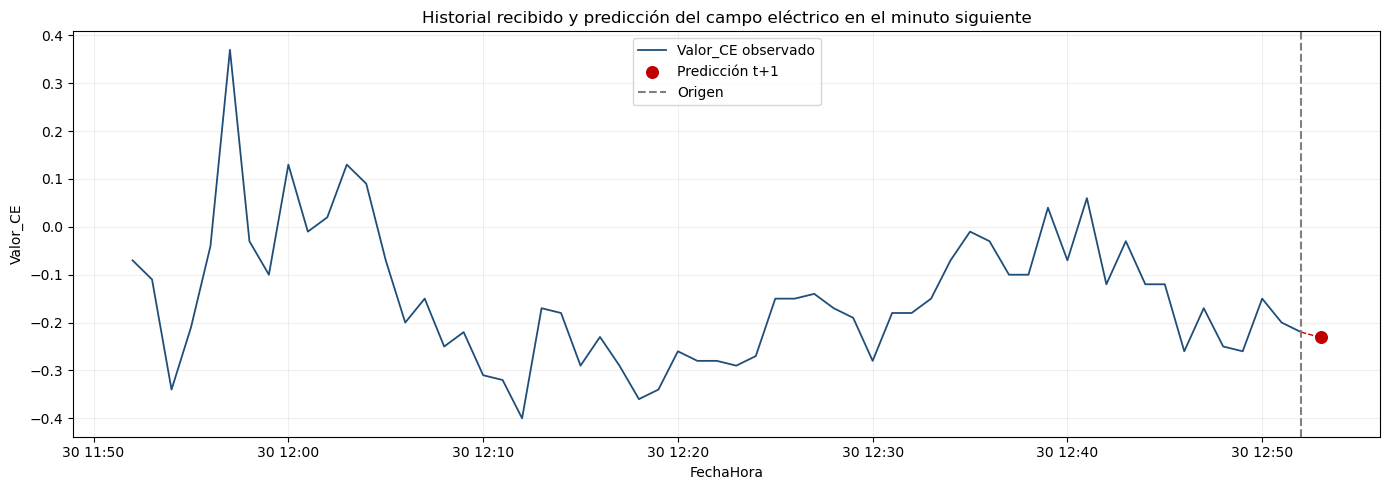

In [66]:
# ============================
# Carga independiente, validación, inferencia y gráfico t+1
# ============================
from pathlib import Path
from hashlib import sha256
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DIRECTORIO_DEPLOY_9 = Path("Artefactos_CE_9Vars") / "horizonte_1min"
DIRECTORIO_SALIDAS_9 = Path("Salidas_Deploy_CE_9Vars")
DIRECTORIO_SALIDAS_9.mkdir(parents=True, exist_ok=True)

with open(DIRECTORIO_DEPLOY_9 / "manifest_deployment.json", encoding="utf-8") as archivo:
    manifest_deploy_9 = json.load(archivo)
for item in manifest_deploy_9["archivos"]:
    ruta = DIRECTORIO_DEPLOY_9 / item["nombre"]
    if not ruta.is_file():
        raise FileNotFoundError(f"Falta el artefacto: {ruta}")
    if ruta.stat().st_size != item["tamano_bytes"]:
        raise ValueError(f"Tamaño inesperado: {ruta.name}")
    if sha256(ruta.read_bytes()).hexdigest() != item["sha256"]:
        raise ValueError(f"Falló SHA-256: {ruta.name}")

with open(DIRECTORIO_DEPLOY_9 / "configuracion_modelo.json", encoding="utf-8") as archivo:
    config_deploy_9 = json.load(archivo)
with open(DIRECTORIO_DEPLOY_9 / "esquema_entrada.json", encoding="utf-8") as archivo:
    esquema_deploy_9 = json.load(archivo)
sistema_deploy_9 = joblib.load(DIRECTORIO_DEPLOY_9 / config_deploy_9["archivo_modelo"])
importancia_deploy_9 = pd.read_csv(DIRECTORIO_DEPLOY_9 / config_deploy_9["archivo_importancia_variables"])
importancia_shap_deploy_9 = pd.read_csv(
    DIRECTORIO_DEPLOY_9 / config_deploy_9["archivo_importancia_shap"]
)
ruta_grafico_shap_deploy_9 = (
    DIRECTORIO_DEPLOY_9 / config_deploy_9["archivo_grafico_shap"]
)
if sistema_deploy_9["version_esquema"] != config_deploy_9["version_esquema"] or esquema_deploy_9["version_esquema"] != config_deploy_9["version_esquema"]:
    raise ValueError("Las versiones del modelo, configuración y esquema no coinciden.")

def validar_historial_9(datos, esquema, max_filas=61):
    columnas = list(esquema["columnas"])
    faltantes = [c for c in columnas if c not in datos.columns]
    if faltantes:
        raise ValueError(f"Faltan columnas: {faltantes}")
    historial = datos[columnas].copy()
    historial["FechaHora"] = pd.to_datetime(historial["FechaHora"], errors="raise")
    for columna in columnas[1:]:
        historial[columna] = pd.to_numeric(historial[columna], errors="raise")
    historial = (
        historial.sort_values("FechaHora")
        .drop_duplicates("FechaHora", keep="last")
        .tail(max_filas)
        .reset_index(drop=True)
    )
    if historial.empty:
        raise ValueError("No hay mediciones válidas para predecir.")
    if historial.isna().any().any() or not np.isfinite(historial[columnas[1:]].to_numpy()).all():
        raise ValueError("Las mediciones contienen nulos o valores no finitos.")
    return historial

def validar_medicion_actual_9(datos, esquema):
    return validar_historial_9(datos, esquema).tail(1).reset_index(drop=True)

def predecir_9(datos, sistema, config, esquema):
    fila = validar_medicion_actual_9(datos, esquema)
    X_nuevo = fila[config["columnas_predictoras"]].copy()
    seleccion = sistema["seleccion"]
    if seleccion["Tipo"] == "Metamodelo":
        valores = {
            columna: sistema["modelos_base"][nombre].predict(X_nuevo)
            for columna, nombre in sistema["mapeo_columnas_meta"].items()
        }
        X_meta_nuevo = pd.DataFrame(valores)[sistema["columnas_meta"]]
        prediccion = float(sistema["metamodelo"].predict(X_meta_nuevo)[0])
    else:
        prediccion = float(sistema["modelos_base"][seleccion["Nombre"]].predict(X_nuevo)[0])
    origen = fila["FechaHora"].iloc[0]
    return fila, pd.DataFrame([{
        "FechaHora_origen": origen,
        "FechaHora_objetivo": origen + pd.Timedelta(minutes=config["horizonte_min"]),
        "Valor_CE_actual": float(fila["Valor_CE"].iloc[0]),
        "Valor_CE_predicho": prediccion,
        "Modelo": seleccion["Nombre"],
    }])

entrada_deploy_9 = pd.read_csv(DIRECTORIO_DEPLOY_9 / config_deploy_9["archivo_entrada_ejemplo"])
historial_deploy_9 = validar_historial_9(entrada_deploy_9, esquema_deploy_9)
fila_deploy_9, resultado_deploy_9 = predecir_9(
    historial_deploy_9, sistema_deploy_9, config_deploy_9, esquema_deploy_9
)
display(fila_deploy_9)
display(resultado_deploy_9)
print("Tabla SHAP: variables que más influyen en el campo eléctrico predicho:")
display(importancia_shap_deploy_9.round(6))
display(ruta_grafico_shap_deploy_9)
print("Verificación complementaria por permutación:")
display(importancia_deploy_9.round(6))
print("Lectura metodológica:")
print("- Importancia_permutacion_RMSE: aumento medio del RMSE al desordenar una variable, atravesando todo el ganador.")
print("- Efecto_medio_al_aumentar_1_DE: cambio medio de la predicción al aumentar esa variable una desviación estándar.")
print("- Ninguna de estas columnas es un coeficiente lineal; describen asociación predictiva, no causalidad.")
print("Inferencia completada desde artefactos; no se ejecutó fit().")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(
    historial_deploy_9["FechaHora"], historial_deploy_9["Valor_CE"],
    color="#1F4E79", linewidth=1.3, marker="o" if len(historial_deploy_9) == 1 else None,
    label="Valor_CE observado",
)
ax.scatter(
    resultado_deploy_9["FechaHora_objetivo"], resultado_deploy_9["Valor_CE_predicho"],
    color="#C00000", s=70, zorder=3, label="Predicción t+1",
)
ax.plot(
    [resultado_deploy_9["FechaHora_origen"].iloc[0], resultado_deploy_9["FechaHora_objetivo"].iloc[0]],
    [resultado_deploy_9["Valor_CE_actual"].iloc[0], resultado_deploy_9["Valor_CE_predicho"].iloc[0]],
    color="#C00000", linestyle="--", linewidth=1,
)
ax.axvline(
    resultado_deploy_9["FechaHora_origen"].iloc[0],
    color="gray", linestyle="--", label="Origen",
)
ax.set_title("Historial recibido y predicción del campo eléctrico en el minuto siguiente")
ax.set_xlabel("FechaHora")
ax.set_ylabel("Valor_CE")
ax.legend()
ax.grid(alpha=0.20)
plt.tight_layout()
plt.savefig(DIRECTORIO_SALIDAS_9 / "prediccion_t_mas_1.png", dpi=300, bbox_inches="tight")
plt.show()

resultado_deploy_9.to_csv(DIRECTORIO_SALIDAS_9 / "prediccion_t_mas_1.csv", index=False)


### 9.3 Aplicación Streamlit

La siguiente celda genera una aplicación independiente. Permite cargar un CSV con una o más mediciones —utiliza la última para predecir y hasta 61 para el gráfico—, consultar y descargar la importancia de las nueve variables calculada sobre el sistema ganador, visualizar el punto pronosticado de `t+1`, descargar resultados y calcular el error cuando llegue el valor real. No muestra coeficientes de MLR ni pesos internos entre modelos base.


In [67]:
%%writefile streamlit_app_ce_9vars.py
from pathlib import Path
from hashlib import sha256
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import streamlit as st

BASE_DIR = Path(__file__).resolve().parent
ARTEFACTOS_DIR = BASE_DIR / "Artefactos_CE_9Vars" / "horizonte_1min"
st.set_page_config(page_title="Predicción CE — 9 variables", page_icon="⚡", layout="wide")

@st.cache_resource
def cargar_sistema():
    with open(ARTEFACTOS_DIR / "manifest_deployment.json", encoding="utf-8") as f:
        manifest = json.load(f)
    for item in manifest["archivos"]:
        ruta = ARTEFACTOS_DIR / item["nombre"]
        if not ruta.is_file() or ruta.stat().st_size != item["tamano_bytes"]:
            raise ValueError(f"Artefacto faltante o con tamaño incorrecto: {ruta.name}")
        if sha256(ruta.read_bytes()).hexdigest() != item["sha256"]:
            raise ValueError(f"Falló SHA-256: {ruta.name}")
    with open(ARTEFACTOS_DIR / "configuracion_modelo.json", encoding="utf-8") as f:
        config = json.load(f)
    with open(ARTEFACTOS_DIR / "esquema_entrada.json", encoding="utf-8") as f:
        esquema = json.load(f)
    sistema = joblib.load(ARTEFACTOS_DIR / config["archivo_modelo"])
    importancia = pd.read_csv(ARTEFACTOS_DIR / config["archivo_importancia_variables"])
    importancia_shap = pd.read_csv(ARTEFACTOS_DIR / config["archivo_importancia_shap"])
    grafico_shap = ARTEFACTOS_DIR / config["archivo_grafico_shap"]
    if importancia.isna().any().any():
        columnas_nulas = importancia.columns[importancia.isna().any()].tolist()
        raise ValueError(f"La importancia del ganador contiene nulos en: {columnas_nulas}")
    if sistema["version_esquema"] != config["version_esquema"] or esquema["version_esquema"] != config["version_esquema"]:
        raise ValueError("Las versiones del modelo, configuración y esquema no coinciden.")
    return sistema, config, esquema, importancia, importancia_shap, grafico_shap

def validar_historial(datos, esquema, max_filas=61):
    columnas = list(esquema["columnas"])
    faltantes = [c for c in columnas if c not in datos.columns]
    if faltantes:
        raise ValueError(f"Faltan columnas: {faltantes}")
    historial = datos[columnas].copy()
    historial["FechaHora"] = pd.to_datetime(historial["FechaHora"], errors="raise")
    for c in columnas[1:]:
        historial[c] = pd.to_numeric(historial[c], errors="raise")
    historial = (
        historial.sort_values("FechaHora")
        .drop_duplicates("FechaHora", keep="last")
        .tail(max_filas)
        .reset_index(drop=True)
    )
    if historial.empty:
        raise ValueError("No hay mediciones válidas para predecir.")
    if historial.isna().any().any() or not np.isfinite(historial[columnas[1:]].to_numpy()).all():
        raise ValueError("Las mediciones contienen nulos o valores no finitos.")
    return historial

def validar(datos, esquema):
    return validar_historial(datos, esquema).tail(1).reset_index(drop=True)

def predecir(datos, sistema, config, esquema):
    fila = validar(datos, esquema)
    X = fila[config["columnas_predictoras"]]
    seleccion = sistema["seleccion"]
    if seleccion["Tipo"] == "Metamodelo":
        valores = {c: sistema["modelos_base"][n].predict(X) for c, n in sistema["mapeo_columnas_meta"].items()}
        X_meta = pd.DataFrame(valores)[sistema["columnas_meta"]]
        valor = float(sistema["metamodelo"].predict(X_meta)[0])
    else:
        valor = float(sistema["modelos_base"][seleccion["Nombre"]].predict(X)[0])
    origen = fila["FechaHora"].iloc[0]
    return fila, pd.DataFrame([{
        "FechaHora_origen": origen,
        "FechaHora_objetivo": origen + pd.Timedelta(minutes=config["horizonte_min"]),
        "Valor_CE_actual": float(fila["Valor_CE"].iloc[0]),
        "Valor_CE_predicho": valor,
        "Modelo": seleccion["Nombre"],
    }])

def graficar_t_mas_1(historial, resultado):
    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.plot(
        historial["FechaHora"], historial["Valor_CE"],
        color="#1F4E79", linewidth=1.4,
        marker="o" if len(historial) == 1 else None,
        label="Valor_CE observado",
    )
    ax.scatter(
        resultado["FechaHora_objetivo"], resultado["Valor_CE_predicho"],
        color="#C00000", s=75, zorder=3, label="Predicción t+1",
    )
    ax.plot(
        [resultado["FechaHora_origen"].iloc[0], resultado["FechaHora_objetivo"].iloc[0]],
        [resultado["Valor_CE_actual"].iloc[0], resultado["Valor_CE_predicho"].iloc[0]],
        color="#C00000", linestyle="--", linewidth=1,
    )
    ax.axvline(
        resultado["FechaHora_origen"].iloc[0],
        color="gray", linestyle="--", label="Origen",
    )
    ax.set_title("Historial recibido y predicción del campo eléctrico en el minuto siguiente")
    ax.set_xlabel("FechaHora")
    ax.set_ylabel("Valor_CE")
    ax.legend()
    ax.grid(alpha=0.20)
    fig.tight_layout()
    return fig

st.title("⚡ Predicción del campo eléctrico — 9 variables")
st.caption("Última medición · horizonte de 1 minuto · inferencia sin reentrenamiento")
try:
    sistema, config, esquema, importancia, importancia_shap, grafico_shap = cargar_sistema()
    st.sidebar.success("Artefactos verificados")
    st.sidebar.write(f"**Modelo ganador:** {sistema['seleccion']['Nombre']}")
    metricas = config["metricas_modelo_final"]
    st.sidebar.metric("MAE · prueba", f"{metricas['MAE']:.5f}")
    st.sidebar.metric("RMSE · prueba", f"{metricas['RMSE']:.5f}")
    st.sidebar.metric("R² · prueba", f"{metricas['R2']:.5f}")

    with st.expander("Interpretabilidad del modelo ganador", expanded=True):
        st.markdown("#### 1. Gráfico SHAP — impacto de las nueve variables")
        st.info(
            "SHAP se calculó sobre las nueve entradas originales atravesando todos los modelos "
            "base y ElasticNet meta. Cada punto representa una observación de prueba."
        )
        st.image(
            str(grafico_shap),
            caption=(
                "Eje X: impacto SHAP sobre Valor_CE t+1. Rojo: valor alto de la variable; "
                "azul: valor bajo. Las variables aparecen ordenadas por influencia global."
            ),
            use_container_width=True,
        )

        st.markdown("#### 2. Tabla de variables que más influyen")
        st.dataframe(importancia_shap, use_container_width=True, hide_index=True)
        st.download_button(
            "Descargar tabla SHAP",
            importancia_shap.to_csv(index=False).encode("utf-8"),
            "importancia_shap_sistema_final.csv",
            "text/csv",
        )
        principales = ", ".join(importancia_shap.head(3)["Variable"].astype(str))
        st.success(f"Variables con mayor influencia global según SHAP: {principales}.")

        with st.expander("¿Cómo se interpretan SHAP, efecto medio y permutación?", expanded=False):
            st.markdown("##### Descomposición SHAP")
            st.latex(r"f(x)=E[f(X)]+\sum_{j=1}^{9}\phi_j(x)")
            st.markdown(
                """
                - Cada $\phi_j(x)$ es el aporte de una variable en una observación concreta.
                - Un SHAP positivo aumenta la predicción y uno negativo la disminuye.
                - `Importancia_SHAP_media_abs` es el promedio de $|SHAP|$ y ordena la influencia global.
                - `Tendencia_SHAP` resume si los valores altos suelen empujar la predicción hacia arriba
                  o abajo; una relación puede ser no monótona.

                SHAP no produce una pendiente constante ni demuestra causalidad. Variables correlacionadas
                pueden repartirse la importancia.

                ##### Puente con la regresión estadística clásica

                En una regresión lineal múltiple cada variable posee una pendiente global constante:
                """
            )
            st.latex(
                r"\widehat{Valor\_CE}_{t+1}=\beta_0+\beta_1X_1+\cdots+\beta_9X_9"
            )
            st.markdown(
                """
                ElasticNet meta, en cambio, combina predicciones completas de modelos base:
                """
            )
            st.latex(
                r"\widehat{Valor\_CE}_{t+1}=\alpha_0+\alpha_1f_{GAM}(X)+\alpha_2f_{Ridge}(X)"
                r"+\alpha_3f_{CatBoost}(X)+\alpha_4f_{MLP}(X)+\alpha_5f_{RF}(X)"
            )
            st.markdown(
                """
                Los $\alpha_m$ ponderan modelos, no variables físicas. Por eso se usan SHAP para
                explicar aportes locales, el efecto medio para magnitud y dirección promedio, y la
                permutación para medir cuánto empeora el RMSE al destruir la información de una variable.

                > **Explicación para la sustentación:** El ganador no es lineal respecto de las nueve
                > variables originales, por lo que no existe un único coeficiente global por predictor.
                > SHAP descompone cada predicción en aportes por variable y su promedio absoluto resume
                > la influencia global; la permutación verifica cuánto depende el sistema de esa información.
                """
            )

        st.markdown("#### 3. Verificación complementaria por permutación")
        st.dataframe(importancia, use_container_width=True, hide_index=True)
        st.download_button(
            "Descargar importancia por permutación",
            importancia.to_csv(index=False).encode("utf-8"),
            "importancia_variables_sistema_final.csv",
            "text/csv",
        )
        st.caption(
            "SHAP media absoluta ordena magnitud de influencia; el signo SHAP explica dirección local. "
            "La permutación mide aumento del RMSE. Son asociaciones predictivas, no efectos causales."
        )
        st.markdown(
            f"**Resultado final:** {sistema['seleccion']['Nombre']} obtuvo "
            f"MAE **{metricas['MAE']:.5f}**, RMSE **{metricas['RMSE']:.5f}** y "
            f"R² **{metricas['R2']:.5f}** en la prueba reservada."
        )

    archivo = st.file_uploader("CSV con FechaHora y las 9 variables (una o más mediciones)", type=["csv"])
    entrada = pd.read_csv(archivo) if archivo is not None else pd.read_csv(ARTEFACTOS_DIR / config["archivo_entrada_ejemplo"])
    if archivo is None:
        st.info("Se utiliza el historial de ejemplo exportado.")
    historial_visible = validar_historial(entrada, esquema)
    fila_visible = historial_visible.tail(1).reset_index(drop=True)
    st.markdown("#### Medición utilizada para predecir")
    st.dataframe(fila_visible, use_container_width=True, hide_index=True)

    if st.button("Predecir el siguiente minuto", type="primary"):
        fila, resultado = predecir(historial_visible, sistema, config, esquema)
        st.session_state["resultado_9"] = resultado

    if "resultado_9" in st.session_state:
        resultado = st.session_state["resultado_9"]
        actual = float(resultado["Valor_CE_actual"].iloc[0])
        predicho = float(resultado["Valor_CE_predicho"].iloc[0])
        c1, c2 = st.columns(2)
        c1.metric("Valor actual", f"{actual:.6f}")
        c2.metric("Predicción t+1", f"{predicho:.6f}", f"{predicho-actual:+.6f}", delta_color="off")

        figura_t1 = graficar_t_mas_1(historial_visible, resultado)
        st.pyplot(figura_t1, use_container_width=True)
        plt.close(figura_t1)

        st.dataframe(resultado, use_container_width=True, hide_index=True)
        st.download_button("Descargar predicción", resultado.to_csv(index=False).encode("utf-8"), "prediccion_t_mas_1.csv", "text/csv")

        with st.form("evaluar_real_9"):
            real_texto = st.text_input("Valor_CE real cuando esté disponible")
            evaluar = st.form_submit_button("Calcular error")
        if evaluar:
            real = float(real_texto.replace(",", "."))
            error = real - predicho
            e1, e2 = st.columns(2)
            e1.metric("Error real − predicción", f"{error:+.6f}")
            e2.metric("Error absoluto", f"{abs(error):.6f}")
except Exception as error:
    st.error(f"No fue posible ejecutar la aplicación: {error}")


Overwriting streamlit_app_ce_9vars.py


#### Ejecución manual en el servidor

Ejecute la siguiente celda únicamente cuando quiera probar la aplicación. La celda permanecerá activa mientras Streamlit utilice el puerto 8501. Abra la dirección del servidor en el puerto `8501` y, al terminar, interrumpa la celda antes de levantar otra aplicación en el mismo puerto.


In [68]:
!streamlit run streamlit_app_ce_9vars.py --server.address 0.0.0.0 --server.port 8501




2026-08-17 18:39:03.793 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.18.0.2:8501
  External URL: http://191.98.175.170:8501

2026-08-17 18:39:15.923 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-08-17 18:39:16.049 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-08-17 18:39:16.053 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-08-17 18:39:16.061 Pleas

### 9.4 Alcance operativo

- Entrada: una medición actual con nueve variables y `FechaHora`.
- Salida: predicción de `Valor_CE` para el minuto siguiente.
- Estado temporal requerido: ninguno.
- Reentrenamiento durante inferencia: ninguno.
- Verificación: tamaño y SHA-256 de todos los artefactos.
- Monitoreo: el valor real puede ingresarse posteriormente para calcular el error de cada predicción.


## ✅ Cierre del experimento

El cuaderno cubre preparación, modelado, prueba reservada, interpretabilidad, exportación científica, empaquetado productivo, inferencia independiente y aplicación Streamlit para nueve variables.
